In [1]:
import os, re, joblib, pickle
import pandas as pd
from pandas.api.types import is_numeric_dtype
from statsmodels.stats.multitest import multipletests
import numpy as np
import scipy.stats as ss
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull
from matplotlib.gridspec import GridSpec
from ppca import PPCA
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency, kruskal, shapiro, fisher_exact, mannwhitneyu
from scipy.stats import t as student_t, levene
import statsmodels.formula.api as smf
import statsmodels.api as sm
import patsy
import itertools as it
from openpyxl import load_workbook
from openpyxl.styles import Font
from math import sqrt, isfinite
from scipy.stats import t as t_dist, spearmanr, norm
from ppca import PPCA
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test
from lifelines.plotting import add_at_risk_counts
from matplotlib.ticker import PercentFormatter, MultipleLocator
import itertools as it
import statsmodels.formula.api as smf
from pathlib import Path
from lifelines import KaplanMeierFitter
from numpy import trapz
from ppca import PPCA
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D


C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [2]:
## Defines
# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

In [3]:
# Configs
base = r'C:\Dev_AIWM\jupyter\KNN'
cbk = f'{base}\\1212_M02'
raw_path = f'{base}\\1212_M02\\dataset'
crt_path = f'{base}\\1212_M02\\creatures'
result_M01 = f'{base}\\1212_M02\\creatures\\Results\\M01'
m01_c4 = f'{result_M01}\\C4'

In [10]:
dict_path = r"E:\KNN"
data_path = r"E:\KNN\Results\M15_dataset08\1_Whole\1_ALL\C4"

# 1) dict 파일 로드 (필요 컬럼만)
dict_df = (pd.read_excel(os.path.join(dict_path, "colName_to_EN.xlsx")
                         , usecols=["col_name", "Feature Name"]
                        ).dropna(subset=["col_name"])    # col_name 이 NaN 인 행 제거
)

# 2) 분석 파일 로드
df = pd.read_excel(os.path.join(data_path, "C4_sort(ana+desc).xlsx"))

# 3) 매핑 딕셔너리 생성: {col_name: Feature Name}
name_map = dict(zip(dict_df["col_name"], dict_df["Feature Name"]))

# 4) df의 '항목명' 컬럼을 col_name 기준으로 치환
df["항목명"] = df["col_name"].map(name_map).fillna(df["항목명"])

# 5) 필요한 경우 저장
df[["cat_name", "항목명", "col_name"]]

,cat_name,항목명,col_name
0,NaN,NaN,NaN
1,NaN,NaN,Decease / Total (%)
2,NaN,NaN,IBP (Pos) / Total (%)
3,NaN,NaN,NEC (Pos) / Total (%)
4,NaN,NaN,And (Pos) / Total (%)
...,...,...,...
164,Reason of Death,Cause of death: Neurological,death_NL
165,Reason of Death,Cause of death: Infection,death_Inf
166,Reason of Death,Cause of death: Gastrointestinal,death_GI
167,Reason of Death,Cause of death: Congenital anomalies,death_CA


In [3]:
df

,cat_name,eCRF명,항목명,col_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,NaN,NaN,NaN,NaN,"Near‑term, low risk, very high survival\n""Stea...","Extreme pre‑term, early cardiorespiratory cras...","Severe GI morbidity managed by intensive care,...","Moderate prematurity, well‑managed course, min..."
1,NaN,NaN,NaN,Decease / Total (%),25 / 8009 (0.31%),2285 / 2392 (95.53%),171 / 2908 (5.88%),110 / 7043 (1.56%)
2,NaN,NaN,NaN,IBP (Pos) / Total (%),23 / 8009 (0.29%),136 / 2392 (5.69%),179 / 2908 (6.16%),120 / 7043 (1.70%)
3,NaN,NaN,NaN,NEC (Pos) / Total (%),127 / 8009 (1.59%),344 / 2392 (14.38%),395 / 2908 (13.58%),416 / 7043 (5.91%)
4,NaN,NaN,NaN,And (Pos) / Total (%),4 / 8009 (0.05%),52 / 2392 (2.17%),53 / 2908 (1.82%),37 / 7043 (0.53%)
...,...,...,...,...,...,...,...,...
164,Reason of Death,NaN,Cause of death: Neurological,death_NL,0.0001 ± 0.0112 (2.8384e-35),0.0966 ± 0.2954 (0.0000e+00),0.0017 ± 0.0414 (5.9705e-08),0.0003 ± 0.0169 (2.4787e-28)
165,Reason of Death,NaN,Cause of death: Infection,death_Inf,0.0007 ± 0.0274 (7.4706e-58),0.1484 ± 0.3556 (0.0000e+00),0.0113 ± 0.1059 (0.0002),0.0034 ± 0.0583 (4.8458e-36)
166,Reason of Death,NaN,Cause of death: Gastrointestinal,death_GI,0.0010 ± 0.0316 (3.1543e-39),0.0949 ± 0.2931 (9.2336e-263),0.0096 ± 0.0977 (n.s.),0.0053 ± 0.0723 (3.0941e-16)
167,Reason of Death,NaN,Cause of death: Congenital anomalies,death_CA,0.0002 ± 0.0158 (1.3162e-13),0.0309 ± 0.1732 (8.4029e-91),0.0021 ± 0.0454 (n.s.),0.0017 ± 0.0412 (8.1449e-06)


In [6]:
df.to_excel(os.path.join(data_path, "C4_sort(ana+desc)_EN.xlsx"), index=False)

In [ ]:
############################################################################################## PPCA

In [19]:
# ipt_dir = f'{crt_path}/Results/M14_dM06/2_SurvOnly/1_ALL/C4'
ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/4_OR/C4'
# ipt_dir = f'{crt_path}/Results/P1/C4_with Deceased_NEC Only'

df_ana = pd.read_csv(os.path.join(ipt_dir, "df_scd_clustered.csv"))
# df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
# df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})
# 'death36' 컬럼 제외
if 'death36' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death36'])
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])

# Cluster Labels 분리
cluster_labels = df_ana['Cluster_Labels']
df_scd = df_ana.drop(columns=['Cluster_Labels'])    # , 'idx_code' --> Index

df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,oxyt36_3,arre36_0,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,1.109795,0.395586,1.647909,-1.671445,-0.775643,-0.672744,0.455923,0.0,1.489945,...,0,1,0,0,0,1,0,0,1,0
4,1,0.057447,-0.667747,1.288889,0.566225,1.643759,0.652076,2.056655,0.0,0.878795,...,0,1,0,0,1,0,0,1,0,0
44,1,-1.521074,-0.667747,0.391338,-0.328843,-0.775643,-0.672744,0.589317,0.0,0.471362,...,0,1,0,0,1,0,0,1,0,0
46,1,2.688316,1.990586,-1.008842,0.342458,-0.775643,-0.672744,-1.144809,0.0,-0.343504,...,0,1,0,0,1,0,0,1,0,0
72,0,-1.521074,-0.667747,-1.464798,0.342458,-0.775643,-0.672744,-2.612147,0.0,-2.176952,...,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20262,0,1.109795,0.927253,0.750358,-0.328843,-0.775643,-0.672744,0.722712,0.0,0.471362,...,1,0,1,0,1,0,0,0,1,0
20297,1,-1.521074,-0.136080,-0.613919,-0.552610,0.837292,1.976897,0.598506,1.0,0.471362,...,0,1,0,0,1,0,0,1,0,0
20312,0,0.583621,0.927253,1.360693,-0.328843,0.837292,-0.672744,1.523078,0.0,1.489945,...,0,0,0,1,1,0,0,1,0,0


In [95]:
dfor = df_ana

for column in dfor.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {dfor[column].dtype}")
    print(f"유니크한 값:")
    print(dfor[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 6.          4.          1.          9.          3.          2.
  5.          7.          0.          4.75271096  8.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 7.          5.         10.          8.          4.          2.
  3.          6.          1.          6.92736054  9.          0.        ]
----------------------------------------
칼럼 이름: bwei
데이터 타입: int64
유니크한 값:
[1340 1240  990  600  473 1290  610  680  922  790  765  438  980 1460
  770  940 1128 1200  710  690  810 1490 1060 1150 1420  530 1270  890
  515  540 1370  780  875  460  880  560  660 1430  320  430  720  500
 1320  900 1010  850  670 1000  650 1130  550  960 1070  932  570  830
  440 1040  920  970 1330 1100  800  870  950  930 1030  849 1110  615
 1260  750  630  820 1140  935  860  700  840 1050  620 1440  819  886
  946  657  736 10

  Principal Component  Explained Variance Ratio  Cumulative Explained Variance
0                 PC1                  0.097073                       0.097073
1                 PC2                  0.149733                       0.246806
2                 PC3                  0.188958                       0.435764
3                 PC4                  0.223398                       0.659162


C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\ppca\_ppca.py:23: RuntimeWarning: invalid value encountered in divide
  return (X - self.means) / self.stds


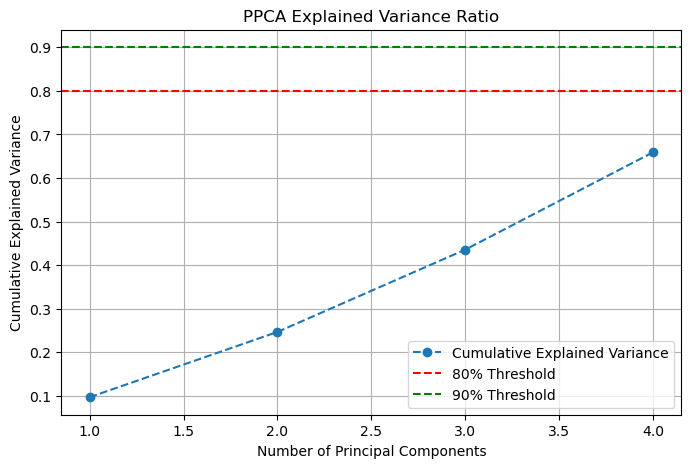

In [59]:
# # PCA 수행 (설명 가능한 분산 비율 계산)
ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=4)  # 주성분 개수를 3개로 설정 (원하는 수로 조정 가능)

# 변환된 데이터(PC Scores)
df_pca = pd.DataFrame(ppca_model.transform(), columns=['PC1', 'PC2', 'PC3', 'PC4']
                      , index=df_ana.index)
df_pca['Cluster_Labels'] = cluster_labels

# 설명된 분산비율 확인
explained_variance_ratio = ppca_model.var_exp
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 설명된 분산 출력
explained_variance_result = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Explained Variance": cumulative_explained_variance
})

print(explained_variance_result)

# 결과 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio)+1), cumulative_explained_variance, marker='o', linestyle='--', label='Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PPCA Explained Variance Ratio')
plt.axhline(y=0.8, color='r', linestyle='--', label="80% Threshold")
plt.axhline(y=0.9, color='g', linestyle='--', label="90% Threshold")
plt.legend()
plt.grid()
plt.show()

In [60]:
# Apply PCA
# Feature 기여도 (Loading 확인)
pca_loadings = pd.DataFrame(ppca_model.C, index=df_scd.columns
                            , columns=['PC1', 'PC2', 'PC3', 'PC4']
                           )

# 기여도가 큰 상위 feature 선택
top_features_PC1 = pca_loadings['PC1'].abs().sort_values(ascending=False)
top_features_PC2 = pca_loadings['PC2'].abs().sort_values(ascending=False)
top_features_PC3 = pca_loadings['PC3'].abs().sort_values(ascending=False)
top_features_PC4 = pca_loadings['PC4'].abs().sort_values(ascending=False)

# 각 PC 설명 분산 출력
print(f"PC1 explains {explained_variance_ratio[0]*100:.2f}% of total variance")
print(f"PC2 explains {explained_variance_ratio[1]*100:.2f}% of total variance")
print(f"PC3 explains {explained_variance_ratio[2]*100:.2f}% of total variance")
print(f"PC4 explains {explained_variance_ratio[3]*100:.2f}% of total variance")

# 상위 features 출력
print("\nTop features contributing to PC1:")
print(top_features_PC1.head(30))

print("\nTop features contributing to PC2:")
print(top_features_PC2.head(30))

print("\nTop features contributing to PC3:")
print(top_features_PC3.head(30))

print("\nTop features contributing to PC4:")
print(top_features_PC4.head(30))

# 기여도가 높은 feature 출력
top_features_PC1, top_features_PC2, top_features_PC3, top_features_PC4

PC1 explains 9.71% of total variance
PC2 explains 14.97% of total variance
PC3 explains 18.90% of total variance
PC4 explains 22.34% of total variance

Top features contributing to PC1:
iarvppd          0.220060
arre28_6         0.212519
ga               0.212288
bdp_Moderate+    0.201286
arre36_0         0.191171
bwei             0.189338
stday            0.188606
oxyt36_1         0.182892
pmirnsg_1+       0.176578
pmirnsg_0        0.176147
arre28_0         0.175653
oxyt28_1         0.168298
bhei             0.162882
oxyt28_3         0.151367
inhg_2+          0.147640
inhg_1           0.146374
bdp              0.146351
strdu_0          0.145870
strdu_1          0.145870
inhg_0           0.144230
bhead            0.142026
sft_0            0.125532
sft_1            0.125532
apgs1            0.123995
EFYN_day         0.121505
lbp_0            0.120451
lbp_1            0.120451
niarvrpd         0.117693
ph_1             0.116231
oxyt36_2         0.115867
Name: PC1, dtype: float64

Top fea

(iarvppd          0.220060
 arre28_6         0.212519
 ga               0.212288
 bdp_Moderate+    0.201286
 arre36_0         0.191171
                    ...   
 dm_0             0.000723
 dm_1             0.000723
 pvl_3            0.000517
 oxyt28_4         0.000018
 seps_3           0.000008
 Name: PC1, Length: 111, dtype: float64,
 bpia_1          2.834860e-01
 bpia_2          2.682558e-01
 ster_Unknown    2.436578e-01
 bbbeuk          2.314575e-01
 bbphuk          2.290518e-01
                     ...     
 seps_2          2.595980e-03
 EFYN_day        1.530835e-03
 arre28_7        7.349673e-05
 seps_3          5.626921e-08
 oxyt28_4        1.011711e-08
 Name: PC2, Length: 111, dtype: float64,
 bdp         2.314880e-01
 oxyt28_2    1.997417e-01
 pvl_3       1.951065e-01
 nese_1      1.909869e-01
 nese_0      1.909869e-01
                 ...     
 bhei        6.787636e-04
 gran        2.403399e-04
 parn        1.463219e-04
 oxyt28_4    3.541509e-09
 seps_3      1.327469e-09
 Name

In [61]:
df_top_features = pd.DataFrame({
    "PC1_Top_Features": top_features_PC1.index,
    "PC Loading_PC1": top_features_PC1.values,
    "PC2_Top_Features": top_features_PC2.index,
    "PC Loading_PC2": top_features_PC2.values,
    "PC3_Top_Features": top_features_PC3.index,
    "PC Loading_PC3": top_features_PC3.values,
    "PC4_Top_Features": top_features_PC4.index,
    "PC Loading_PC4": top_features_PC4.values
})

df_top_features.to_excel(os.path.join(ipt_dir, "PC-Loadings_EN.xlsx"), encoding='utf-8-sig')

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [62]:
i1_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'    # 고정
df_fn = pd.read_excel(os.path.join(i1_dir, "C4_ana+description.xlsx"))    # 고정

# 'col_name'과 '항목명'을 매핑하기 위한 Dictionary 생성 --> 항목명(기존이름)
feature_name_map = {col: f"{desc}({col})" for col, desc in zip(df_fn['col_name']
                                                               , df_fn['Feature_EN']
                                                              )
                   }

# top_features_PC1, PC2, PC3 feature 이름 변경적용
top_features_PC1M = top_features_PC1
top_features_PC2M = top_features_PC2
top_features_PC3M = top_features_PC3
top_features_PC4M = top_features_PC4

top_features_PC1M.rename(index=feature_name_map, inplace=True)
top_features_PC2M.rename(index=feature_name_map, inplace=True)
top_features_PC3M.rename(index=feature_name_map, inplace=True)
top_features_PC4M.rename(index=feature_name_map, inplace=True)

# 결과 확인
top_features_PC1M, top_features_PC2M, top_features_PC3M, top_features_PC4M

(Invasive-ventilation duration(iarvppd)                         0.220060
 Invasive ventilation at day 28(arre28_6)                       0.212519
 Gestational age(ga)                                            0.212288
 BPD at 36 weeks corrected (NICHD 2001) (Pos)(bdp_Moderate+)    0.201286
 Ventilation at 36 weeks (Neg)(arre36_0)                        0.191171
                                                                  ...   
 Maternal diabetes (Neg)(dm_0)                                  0.000723
 Maternal diabetes (Pos)(dm_1)                                  0.000723
 Periventricular leukomalacia (Pos)(pvl_3)                      0.000517
 Oxygen therapy at day 28 (Unknown)(oxyt28_4)                   0.000018
 Sepsis (Blood culture not performed)(seps_3)                   0.000008
 Name: PC1, Length: 111, dtype: float64,
 Birth place (In-hospital)(bpia_1)                          2.834860e-01
 Birth place (Out-of-hospital)(bpia_2)                      2.682558e-01
 Antenatal

In [63]:
df_top_features = pd.DataFrame({
    "PC1_Top_Features": top_features_PC1M.index,
    "PC Loading_PC1": top_features_PC1M.values,
    "PC2_Top_Features": top_features_PC2M.index,
    "PC Loading_PC2": top_features_PC2M.values,
    "PC3_Top_Features": top_features_PC3M.index,
    "PC Loading_PC3": top_features_PC3M.values,
    "PC4_Top_Features": top_features_PC4M.index,
    "PC Loading_PC4": top_features_PC4M.values
})

df_top_features.to_excel(os.path.join(ipt_dir, "PC-Loadings_EN.xlsx"), encoding='utf-8-sig')

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [ ]:
n_top = 30

# 각 PC별로 상위 n_top개의 feature & loading 값만 슬라이스
tf1 = top_features_PC1.head(n_top)
tf2 = top_features_PC2.head(n_top)
tf3 = top_features_PC3.head(n_top)
tf4 = top_features_PC4.head(n_top)

# Fixing the title issue in the Feature Importance plots
fig, axes = plt.subplots(4, 1, figsize=(12, 20))

# PC1 Feature Importance
sns.barplot(x=tf1.values, y=tf1.index,
            ax=axes[0],
            palette="Blues_r")
axes[0].set_title(f"Important features in PC1 (Top {n_top} Loadings)")
axes[0].set_xlabel("Absolute PC Loading")
axes[0].set_ylabel("Feature")

# PC2 Feature Importance
sns.barplot(x=tf2.values, y=tf2.index,
            ax=axes[1],
            palette="Reds_r")
axes[1].set_title(f"Important features in PC2 (Top {n_top} Loadings)")
axes[1].set_xlabel("Absolute PC Loading")
axes[1].set_ylabel("Feature")

# PC3 Feature Importance
sns.barplot(x=tf3.values, y=tf3.index,
            ax=axes[2],
            palette="Greens_r")
axes[2].set_title(f"Important features in PC3 (Top {n_top} Loadings)")
axes[2].set_xlabel("Absolute PC Loading")
axes[2].set_ylabel("Feature")

# PC4 Feature Importance
sns.barplot(x=tf4.values, y=tf4.index,
            ax=axes[3],
            palette="Purples_r")
axes[3].set_title(f"Important features in PC4 (Top {n_top} Loadings)")
axes[3].set_xlabel("Absolute PC Loading")
axes[3].set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [21]:
# ipt_dir = f'{crt_path}/Results/M14_dM06/2_SurvOnly/1_ALL/C4'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'
ipt_dir = f'{crt_path}/Results/P1/C4_with Deceased_NEC Only'

df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
# df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
# df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})
# 'death36' 컬럼 제외
if 'death36' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death36'])
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])

# Cluster Labels 분리
cluster_labels = df_ana['Cluster_Labels']
df_scd = df_ana.drop(columns=['Cluster_Labels'])    # , 'idx_code' --> Index

df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,6.0,7.0,1340,26,1,0,36.000000,0.0,28.0,...,0,0,1,0,0,0,1,0,0,0
4,1,4.0,5.0,1240,36,4,1,42.000000,0.0,26.5,...,0,0,1,0,0,0,1,0,0,0
44,1,1.0,5.0,990,32,1,0,36.500000,0.0,25.5,...,0,0,1,0,0,0,1,0,0,0
46,1,9.0,10.0,600,35,1,0,30.000000,0.0,23.5,...,0,0,1,0,0,0,1,0,0,0
72,0,1.0,5.0,473,35,1,0,24.500000,0.0,19.0,...,1,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20262,0,6.0,8.0,1090,32,1,0,37.000000,0.0,25.5,...,0,0,0,0,0,1,1,0,0,0
20297,1,1.0,6.0,710,31,3,2,36.534441,1.0,25.5,...,1,0,1,0,0,0,1,0,0,0
20312,0,5.0,8.0,1260,32,3,0,40.000000,0.0,28.0,...,0,0,1,0,0,0,1,0,0,0


In [22]:
df_scd[['ga']]

,ga
idx_code,
3,29.2857
4,27.2857
44,27.5714
46,33.7143
72,22.5714
...,...
20262,28.4286
20297,25.8571
20312,30.4286


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8028\375439479.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


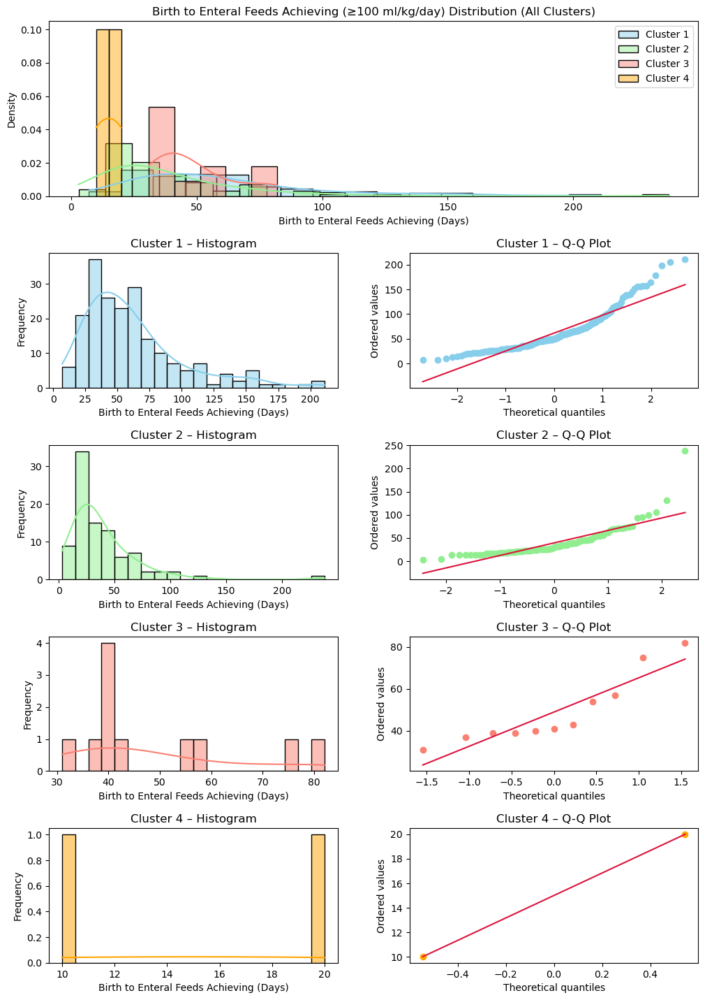

In [116]:
ga = df_scd['EFYN_day']
col = 'Enteral Feeds'

clusters = cluster_labels
cl_ids   = sorted(clusters.unique())
colours  = ['skyblue', 'lightgreen', 'salmon', 'orange'][:len(cl_ids)]

n  = len(cl_ids)
fig = plt.figure(figsize=(12, 3.5*(n+1)))
gs  = gridspec.GridSpec(
        nrows=n+1, ncols=2,
        height_ratios=[1.3] + [1]*n,        # 맨 윗줄(전체 분포)만 살짝 키움
        hspace=0.4, wspace=0.25
      )

# ── (A) 전체 분포 ··· gs[0, :] (첫 행 전체 병합) ──
ax_all = fig.add_subplot(gs[0, :])
for cl, colour in zip(cl_ids, colours):
    sns.histplot(
        ga[clusters == cl], stat='density', kde=True,
        color=colour, label=f'Cluster {cl}',
        alpha=0.45, edgecolor='black', ax=ax_all
    )
ax_all.set_title(f'Birth to {col} Achieving (≥100 ml/kg/day) Distribution (All Clusters)')
ax_all.set_xlabel(f'Birth to {col} Achieving (Days)')
ax_all.set_ylabel('Density')
ax_all.legend()

# ── (B) 군집별 히스토그램 + Q-Q ─────────────────────
for i, (cl, colour) in enumerate(zip(cl_ids, colours), start=1):
    subset = ga[clusters == cl].dropna()

    # Histogram  →  왼쪽 열
    ax_hist = fig.add_subplot(gs[i, 0])
    sns.histplot(subset, bins=20, kde=True,
                 color=colour, edgecolor='black', ax=ax_hist)
    ax_hist.set_title(f'Cluster {cl} – Histogram')
    ax_hist.set_xlabel(f'Birth to {col} Achieving (Days)')
    ax_hist.set_ylabel('Frequency')

    # Q-Q plot   →  오른쪽 열
    ax_qq = fig.add_subplot(gs[i, 1])
    stats.probplot(subset, dist="norm", plot=ax_qq)
    ax_qq.get_lines()[0].set_markerfacecolor(colour)
    ax_qq.get_lines()[0].set_markeredgecolor(colour)
    ax_qq.get_lines()[1].set_color('crimson')
    ax_qq.set_title(f'Cluster {cl} – Q-Q Plot')
    ax_qq.set_xlabel('Theoretical quantiles')
    ax_qq.set_ylabel('Ordered values')

plt.tight_layout()
plt.show()

# ── PDF 한 장으로 저장 ───────────────────────────────
fig.savefig(os.path.join(ipt_dir, f'{col}-days_Histo+KDE-QQ_plt.pdf'), bbox_inches='tight')
plt.close(fig)

In [127]:
## Attatch cols

ipt_dirs = [
    f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4',
    f'{crt_path}/Results/M15_dataset08/1_Whole/2_NEC only/C4',
    f'{crt_path}/Results/M15_dataset08/1_Whole/3_IBP only/C4',
    f'{crt_path}/Results/M15_dataset08/1_Whole/4_OR/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/1_ALL/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/2_NEC only/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/3_IBP only/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/4_OR/C4'
]

# original df load
orn_df = pd.read_csv(os.path.join(crt_path, 'knn_prep-fin_M09.csv'))[['Unnamed: 0', 'ivh_1', 'ivh_2', 'ivh_3', 'ivh_4']]
print(orn_df)
orn_df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
orn_df.set_index('idx_code', inplace=True)
print(orn_df)

for d in ipt_dirs:
    df_ana = pd.read_csv(os.path.join(d, 'KNN_df_combined.csv')
                        ).set_index('idx_code')
    df_ana = df_ana.join(orn_df, how='left')
    print(df_ana)
    df_ana.to_csv(os.path.join(d, 'KNN_dfANA_combined.csv'),
                  encoding='utf-8-sig')

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8028\3832159734.py:13: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  orn_df = pd.read_csv(os.path.join(crt_path, 'knn_prep-fin_M09.csv'))[['Unnamed: 0', 'ivh_1', 'ivh_2', 'ivh_3', 'ivh_4']]
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8028\3832159734.py:20: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana = pd.read_csv(os.path.join(d, 'KNN_df_combined.csv')


       Unnamed: 0  ivh_1  ivh_2  ivh_3  ivh_4
0               0      1      0      0      0
1               1      1      0      0      0
2               2      1      0      0      0
3               3      0      1      0      0
4               4      1      0      0      0
...           ...    ...    ...    ...    ...
20347       20408      1      0      0      0
20348       20409      0      0      0      1
20349       20410      1      0      0      0
20350       20411      0      0      0      0
20351       20412      0      0      0      0

[20352 rows x 5 columns]
          ivh_1  ivh_2  ivh_3  ivh_4
idx_code                            
0             1      0      0      0
1             1      0      0      0
2             1      0      0      0
3             0      1      0      0
4             1      0      0      0
...         ...    ...    ...    ...
20408         1      0      0      0
20409         0      0      0      1
20410         1      0      0      0
20411         0

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8028\3832159734.py:20: DtypeWarning: Columns (22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana = pd.read_csv(os.path.join(d, 'KNN_df_combined.csv')


          sex_sys_val     birthdt        bird        admd  apgs1  apgs5  bwei  \
idx_code                                                                        
0                   1  2013-12-18  2013-12-18  2013-12-18    4.0    5.0  1350   
1                   1  2013-11-15  2013-11-15  2013-11-15    4.0    5.0   790   
2                   1  2013-11-15  2013-11-15  2013-11-15    5.0    6.0  1400   
3                   1  2013-11-15  2013-11-15  2013-11-15    6.0    7.0  1340   
4                   1  2013-11-11  2013-11-11  2013-11-11    4.0    5.0  1240   
...               ...         ...         ...         ...    ...    ...   ...   
20408               1  2022-11-28  2022-11-28  2022-11-28    5.0    8.0  1350   
20409               1  2022-12-27  2022-12-27  2022-12-27    4.0    7.0   860   
20410               0  2022-12-01  2022-12-01  2022-12-01    5.0    7.0  1910   
20411               1  2022-11-30  2022-11-30  2022-11-30    3.0    7.0  1660   
20412               1  2022-

In [126]:
df_ana

,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels,ivh_1,ivh_2,ivh_3,ivh_4
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,3,0,1,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,4,1,0,0,0
44,1,2013-07-22,2013-07-22,2013-07-22,1.0,5.0,990,32,1,0,...,0,1,0,0,0,4,0,0,0,0
109,0,2013-07-21,2013-07-21,2013-08-03,3.0,4.0,922,38,3,2,...,0,0,1,0,0,2,1,0,0,0
134,0,2013-11-25,2013-11-25,2013-11-25,5.0,8.0,980,34,3,0,...,0,1,0,0,0,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20238,0,2022-07-26,2022-07-26,2022-07-28,7.0,9.0,740,30,1,0,...,0,0,0,1,0,4,0,0,0,0
20247,1,2022-07-20,2022-07-20,2022-07-20,7.0,9.0,1410,30,1,0,...,0,1,0,0,0,4,1,0,0,0
20262,0,2022-01-07,2022-01-07,2022-01-07,6.0,8.0,1090,32,1,0,...,1,1,0,0,0,4,1,0,0,0


In [157]:
# Lists & Defs
ipt_dirs = [
    f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4',
    f'{crt_path}/Results/M15_dataset08/1_Whole/2_NEC only/C4',
    f'{crt_path}/Results/M15_dataset08/1_Whole/3_IBP only/C4',
    f'{crt_path}/Results/M15_dataset08/1_Whole/4_OR/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/1_ALL/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/2_NEC only/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/3_IBP only/C4',
    f'{crt_path}/Results/M15_dataset08/2_Survonly/4_OR/C4'
]
categories = [
    ('Gestational age', ['ga'], 'cont'),
    ('Birth weight', ['bwei'], 'cont'),
    ('Length of stay', ['stday'], 'cont'),
    ('RDS (Surfactant administration)', ['sft_1'], 'binary'),
    ('Duration of mechanical ventilation', ['iarvppd'], 'cont'),
    ('BPD (28 Days)', ['oxyt28_2','oxyt28_3'], 'binary'),   # OR 조건
    ('PMA (36 Weeks)', ['bdp'], 'binary'),
    ('Moderate PMA (36 Weeks)', ['bdp_Moderate+'], 'binary'),
    ('IVH (1-4)', ['ivh_1','ivh_2','ivh_3','ivh_4'], 'binary'),
    ('IVH grade 1', ['ivh_1'], 'binary'),
    ('IVH grade 2', ['ivh_2'], 'binary'),
    ('IVH grade 3', ['ivh_3'], 'binary'),
    ('IVH grade 4', ['ivh_4'], 'binary'),
    ('PVL', ['pvl_2'], 'binary'),
    ('NEC (≥ Stage2)', ['ntet_1'], 'binary'),
    ('NEC (Surgery)', ['ntety_2'], 'binary'),
]

def build_summary(df, cluster_col='Cluster_Labels'):
    clusters = sorted(df[cluster_col].dropna().unique())
    rows = []

    for cat, cols, col_type in categories:
        # ────────────── 여기 한 줄만 수정 ──────────────
        row = [cat, ' OR '.join(cols)]          # 여러 컬럼 → 'a | b' 형태
        # ───────────────────────────────────────────────
        for c in clusters:
            g = df[df[cluster_col] == c]

            if col_type == 'cont':
                mu, sd = g[cols[0]].mean(), g[cols[0]].std()
                val = f'{mu:.2f} ± {sd:.2f}'
            else:                               # binary (여러 컬럼이면 OR)
                or_series = pd.DataFrame({col: (g[col] == 1) for col in cols}).any(axis=1)
                pos = or_series.sum()
                pct = pos / len(g) * 100 if len(g) else 0
                val = f'{pos} ({pct:.2f}%)'
            row.append(val)
        rows.append(row)

    col_names = ['Category', 'Feature'] + [f'Cluster {c}' for c in clusters]
    return pd.DataFrame(rows, columns=col_names)

In [158]:
for ipt_dir in ipt_dirs:
    try:
        # 1) 데이터 로드 · 전처리 ────────────────────────────────────────────
        csv_path = os.path.join(ipt_dir, "KNN_dfANA_combined.csv")
        df_ana   = (pd.read_csv(csv_path)
                       .set_index('idx_code'))

        drop_cols = ['death36', 'death_label']
        datetime_cols = [
            'ntetdt','ntetdty','date362','date36','menidt','pdaddth','pdaddt',
            'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt'
        ]
        df_ana = df_ana.drop(columns=[c for c in drop_cols + datetime_cols if c in df_ana.columns])
        summary_df = build_summary(df_ana, cluster_col='Cluster_Labels')
        summary_df.index = summary_df.index + 1

        out_xlsx = os.path.join(ipt_dir, "Summary_mainFeatures.xlsx")
        with pd.ExcelWriter(out_xlsx, engine='xlsxwriter') as writer:
            summary_df.to_excel(writer, index=True, sheet_name='Summary')

            wb = writer.book
            ws = writer.sheets['Summary']
            bold_fmt = wb.add_format({'bold': True})
            ws.set_row(0, None, bold_fmt)      # 헤더
#             ws.set_row(1, None, bold_fmt)      # 첫 데이터 행 (Category: Gestational age)

        print(f"[OK] Saved summary to {out_xlsx}")

    except FileNotFoundError:
        print(f"[SKIP] File not found: {csv_path}")
    except Exception as e:
        print(f"[ERROR] {ipt_dir} — {e}")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8028\263305944.py:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana   = (pd.read_csv(csv_path)


[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/1_Whole/1_ALL/C4\Summary_mainFeatures.xlsx
[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/1_Whole/2_NEC only/C4\Summary_mainFeatures.xlsx
[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/1_Whole/3_IBP only/C4\Summary_mainFeatures.xlsx
[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/1_Whole/4_OR/C4\Summary_mainFeatures.xlsx


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8028\263305944.py:5: DtypeWarning: Columns (22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana   = (pd.read_csv(csv_path)


[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/2_Survonly/1_ALL/C4\Summary_mainFeatures.xlsx
[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/2_Survonly/2_NEC only/C4\Summary_mainFeatures.xlsx
[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/2_Survonly/3_IBP only/C4\Summary_mainFeatures.xlsx
[OK] Saved summary to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/2_Survonly/4_OR/C4\Summary_mainFeatures.xlsx


In [159]:
summary_df

,Category,Feature,Cluster 1,Cluster 2,Cluster 3,Cluster 4
1,Gestational age,ga,25.53 ± 1.65,25.55 ± 1.58,30.46 ± 1.88,28.08 ± 1.84
2,Birth weight,bwei,746.41 ± 178.98,758.97 ± 190.83,1228.55 ± 221.55,1028.05 ± 233.43
3,Length of stay,stday,142.12 ± 49.52,140.77 ± 54.32,68.04 ± 24.78,93.62 ± 32.79
4,RDS (Surfactant administration),sft_1,59 (100.00%),454 (99.56%),83 (58.45%),367 (87.80%)
5,Duration of mechanical ventilation,iarvppd,61.00 ± 42.92,58.63 ± 34.83,4.80 ± 6.85,15.35 ± 15.17
6,BPD (28 Days),oxyt28_2 OR oxyt28_3,52 (88.14%),431 (94.52%),11 (7.75%),326 (77.99%)
7,PMA (36 Weeks),bdp,58 (98.31%),435 (95.39%),25 (17.61%),393 (94.02%)
8,Moderate PMA (36 Weeks),bdp_Moderate+,46 (77.97%),381 (83.55%),2 (1.41%),225 (53.83%)
9,IVH (1-4),ivh_1 OR ivh_2 OR ivh_3 OR ivh_4,53 (89.83%),329 (72.15%),32 (22.54%),213 (50.96%)
10,IVH grade 1,ivh_1,14 (23.73%),143 (31.36%),26 (18.31%),119 (28.47%)


In [4]:
# ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/2_NEC only/C4'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/30%-6PCs/C27'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/30%-6PCs/C8_Sil-Opt'
# ipt_dir = f'{crt_path}/Results/P1/C4_with Deceased_NEC Only'
# dwd = r'C:\Users\AIWM_W01\Downloads'
ipt_dir = r'C:\Users\AIWM_W01\Downloads'


df = pd.read_csv(os.path.join(ipt_dir, 'dHX_all_scaled_each.csv'))
df.set_index('ID', inplace=True)
df

,sex,age,PNX_total,HX_total,No_RFX_total_12,50_No_RFX_total_12,100_No_RFX_total_12,No_RFX_total_24,50_No_RFX_total_24,100_No_RFX_total_24,HX_depth,Post_Fx,dHX_total
ID,,,,,,,,,,,,,
9845789,0,0.862999,1,1,0.469714,-0.753567,-0.579962,0.316147,-0.752258,-0.582335,3.636992,0,0
9845888,1,-0.022898,0,0,-0.696336,-0.753567,-0.579962,-0.699424,-0.752258,-0.582335,-0.516218,0,0
9847310,1,-1.185639,1,0,1.247080,2.501225,2.791246,0.654670,2.473267,2.827866,-0.516218,0,0
9848131,1,-1.462482,1,1,0.469714,-0.753567,-0.579962,0.316147,-0.752258,-0.582335,0.522084,1,0
9850899,1,1.416685,0,0,0.858397,-0.753567,-0.579962,0.654670,-0.752258,-0.582335,-0.516218,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8641827,0,0.973737,0,0,0.469714,1.199308,1.948444,0.316147,1.183057,1.975316,-0.516218,1,0
9050752,1,-0.244373,0,0,-1.085019,-0.753567,-0.579962,-1.037948,-0.752258,-0.582335,-0.516218,1,0
10539539,0,0.087839,0,1,0.081031,1.199308,-0.579962,-0.022377,1.183057,-0.582335,0.868185,1,0


In [5]:
# analyse_dataframe(df[["ga", "bwei", "sga_1", "sga_2"]])
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex,0,0.0,2
age,0,0.0,84
PNX_total,0,0.0,2
HX_total,0,0.0,2
No_RFX_total_12,0,0.0,13
50_No_RFX_total_12,0,0.0,9
100_No_RFX_total_12,0,0.0,7
No_RFX_total_24,0,0.0,16
50_No_RFX_total_24,0,0.0,9
100_No_RFX_total_24,0,0.0,7


In [6]:
# drop_cols = ['sga']

# datetime_cols = [
#     'ntetdt','ntetdty','date362','date36','menidt','pdaddth','pdaddt',
#     'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt'
# ]
# drop_cols += datetime_cols

# # rsndth_cols = ['death_CR','death_NL','death_Inf','death_GI','death_CA','death_Otr']
# # drop_cols += rsndth_cols

# print('len(drop_cols): ', len(drop_cols), '\n')
# print("drop_cols:", drop_cols, '\n')

# # target_keys = [
# #     'ntet_','ntety_','ntetoy_',
# #     'SEPS_bef_NTET','SEPS_aft_NTET',
# #     'NTET_day','PDA_7d_NTET',
# #     'invfpod',
# #     'iperr_','iperroy_',
# #     'SEPS_bef_IPERR','SEPS_aft_IPERR',
# #     'IPERR_day','PDA_7d_IPERR','PDA_7d_IPERRorNTET',
# #     'SEPS_bef_IPERRorNTET','SEPS_aft_IPERRorNTET',
# #     '7d_PDA',
# #     'bdp','bdp_Moderate+','strdu_',
# #     'inhg_','pvl_','nese_',
# #     'seps_3',
# #     'pmirnsg_','pmirnsgnd',
# #     'stday'
# # ]
# target_keys = ['ntet_', 'ntety_', 'ntetoy_'
#                , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
#                , 'NTET_day', 'PDA_7d_NTET'
#                , 'invfpod'
#                , 'iperr_', 'iperroy_'
#                , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
#                , 'IPERR_day', 'PDA_7d_IPERR', 'PDA_7d_IPERRorNTET'
#                , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
#                , '7d_PDA'
#                , 'bdp', 'bdp_Moderate+', 'strdu_'
#                , 'inhg_', 'pvl_', 'nese_'
#                , 'seps_3'
#                , 'pmirnsg_', 'pmirnsgnd'
#                , 'stday'

#                , 'oxyt36_', 'arre36_'    # 05/31 Added
#                , 'bwei'    # 06/28 added
#                , 'btem', 'bhei', 'bhead'    # 07/10 added
#               ]

# tgt_cols = [c for c in df.columns if c in target_keys or any(c.startswith(p) for p in target_keys)]
# print('len(tgt_cols): ', len(tgt_cols))
# print("tgt_cols:", tgt_cols, '\n')

# # drop(cols)
# cols_to_drop = list(drop_cols)    # ['death_label']+ list(tgt_cols) +
# data = df.drop(columns=cols_to_drop, errors='ignore')

data = df
print('Final shape:', data.shape)
data

Final shape: (590, 13)


,sex,age,PNX_total,HX_total,No_RFX_total_12,50_No_RFX_total_12,100_No_RFX_total_12,No_RFX_total_24,50_No_RFX_total_24,100_No_RFX_total_24,HX_depth,Post_Fx,dHX_total
ID,,,,,,,,,,,,,
9845789,0,0.862999,1,1,0.469714,-0.753567,-0.579962,0.316147,-0.752258,-0.582335,3.636992,0,0
9845888,1,-0.022898,0,0,-0.696336,-0.753567,-0.579962,-0.699424,-0.752258,-0.582335,-0.516218,0,0
9847310,1,-1.185639,1,0,1.247080,2.501225,2.791246,0.654670,2.473267,2.827866,-0.516218,0,0
9848131,1,-1.462482,1,1,0.469714,-0.753567,-0.579962,0.316147,-0.752258,-0.582335,0.522084,1,0
9850899,1,1.416685,0,0,0.858397,-0.753567,-0.579962,0.654670,-0.752258,-0.582335,-0.516218,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8641827,0,0.973737,0,0,0.469714,1.199308,1.948444,0.316147,1.183057,1.975316,-0.516218,1,0
9050752,1,-0.244373,0,0,-1.085019,-0.753567,-0.579962,-1.037948,-0.752258,-0.582335,-0.516218,1,0
10539539,0,0.087839,0,1,0.081031,1.199308,-0.579962,-0.022377,1.183057,-0.582335,0.868185,1,0


In [36]:
data[["birthdt"]]

KeyError: "None of [Index(['birthdt'], dtype='object')] are in the [columns]"

In [37]:
# 'Cluster_Labels'에 따른 인원 필터링
data = data[data["Cluster_Labels"].isin(range(23, 28))].copy()

data

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels,sga
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,6.0,7.0,1340,26,1,0,36.0,0.0,28.0,...,1,0,0,0,1,0,0,0,24,0
7,1,3.0,4.0,810,33,2,1,32.0,0.0,24.5,...,1,0,0,0,1,0,0,0,25,0
8,0,4.0,5.0,1300,30,1,0,38.5,0.0,28.5,...,1,0,0,0,1,0,0,0,24,0
15,1,4.0,5.0,960,34,1,0,35.5,0.0,24.0,...,1,0,0,0,1,0,0,0,24,0
38,0,4.0,6.0,1260,34,1,0,40.0,0.0,27.5,...,1,0,0,0,1,0,0,0,27,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20390,1,1.0,1.0,710,39,1,0,30.0,0.0,21.5,...,1,0,0,0,1,0,0,0,24,1
20391,0,3.0,6.0,580,31,2,1,29.0,0.0,23.0,...,1,0,0,0,1,0,0,0,25,1
20393,1,3.0,5.0,820,35,5,1,31.0,0.0,24.0,...,1,0,0,0,1,0,0,0,25,0


In [38]:
print(df["Cluster_Labels"].value_counts().sort_index())
print()
print(data["Cluster_Labels"].value_counts().sort_index())

Cluster_Labels
1      353
2      805
3     1141
4     1072
5      683
6      837
7      975
8      699
9     1200
10     359
11     849
12     885
13     828
14     626
15     835
16     772
17     381
18     726
19    1025
20     987
21     641
22     895
23     202
24    1156
25     760
26     426
27     234
Name: count, dtype: int64

Cluster_Labels
23     202
24    1156
25     760
26     426
27     234
Name: count, dtype: int64


In [11]:
df_keep = data.copy()
if 'Cluster_Labels' not in df_keep.columns:
    raise KeyError("Cluster_Labels column not found in df_keep.")

continuous_cols = []
for c in df_keep.columns:
    if c == 'Cluster_Labels':
        continue
    s = df_keep[c]
    is_numeric = pd.api.types.is_numeric_dtype(s)
    if not is_numeric:
        continue
    uniq = pd.unique(s.dropna())
    is_binary = (len(uniq) <= 2) and set(uniq).issubset({0, 1})
    is_trms   = bool(pd.Series([c]).str.contains(r'^(trmsitr|trmstr)', case=False, regex=True).iloc[0])
    if (is_numeric and not is_binary) or is_trms:
        continuous_cols.append(c)

clusters = np.sort(df_keep['Cluster_Labels'].dropna().unique())
SW_ALPHA = 0.01
MINP_CUTOFF = SW_ALPHA
SW_MAX_N = 5000
DETAIL_ALPHA_FMT = 0.05

detail_rows = []
for col in continuous_cols:
    for cl in clusters:
        s = df_keep.loc[df_keep['Cluster_Labels'] == cl, col].dropna()
        n = int(s.size)
        stat, p = (np.nan, np.nan)

        if n >= 3 and pd.Series(s).nunique() >= 3:
            x = s if n <= SW_MAX_N else s.sample(SW_MAX_N, random_state=0)
            stat, p = shapiro(x)

        detail_rows.append({
            'Variable': col,
            'Cluster': cl,
            'n': n,
            'Shapiro_W': stat,
            'p_value': p,
            f'Normal_(alpha={SW_ALPHA})': (p >= SW_ALPHA) if not np.isnan(p) else np.nan
        })
details = pd.DataFrame(detail_rows)

# 변수별 요약: 검정 가능한 클러스터들에서 모두 정규(=True)인지 여부 및 최소 p
def _summ(group):
    mask = group['p_value'].notna()
    n_tested = int(mask.sum())
    if n_tested == 0:
        return pd.Series({
            'n_clusters_tested': 0,
            'All_clusters_normal': np.nan,
            'Min_p_across_clusters': np.nan
        })
    return pd.Series({
        'n_clusters_tested': n_tested,
        'All_clusters_normal': bool(group.loc[mask, f'Normal_(alpha={SW_ALPHA})'].all()),
        'Min_p_across_clusters': float(group.loc[mask, 'p_value'].min())
    })

summary = (details.groupby('Variable', as_index=False)
                 .apply(_summ)
                 .reset_index(drop=True)
                 .sort_values(['All_clusters_normal', 'Min_p_across_clusters'],
                              ascending=[True, True]))


def fmt_p_all(p):
    if pd.isna(p): 
        return "N/A"
    return "≤ 0.01" if p < 0.01 else f"{p:.3f}"

# 1) details: 클러스터별 p
details['p_value_fmt'] = details['p_value'].map(fmt_p_all)

# 2) summary: 변수별 최소 p
summary['Min_p_fmt'] = summary['Min_p_across_clusters'].map(fmt_p_all)

# === 저장/표시용 컬럼 구성(숫자 p 제거하여 지수표기 완전 차단) ===
details_out = details[['Variable','Cluster','n','Shapiro_W','p_value_fmt',
                       f'Normal_(alpha={SW_ALPHA})']].rename(
    columns={'p_value_fmt': 'p_value'}
)

summary_out = summary[['Variable','n_clusters_tested','All_clusters_normal',
                       'Min_p_fmt']].rename(columns={'Min_p_fmt':'Min_p_across_clusters'})
# summary_out = summary[['Variable','n_clusters_tested','All_clusters_normal',
#                        'Min_p_across_clusters','Min_p_fmt']]

summary_out

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38532\4019183659.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_trms   = bool(pd.Series([c]).str.contains(r'^(trmsitr|trmstr)', case=False, regex=True).iloc[0])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38532\4019183659.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = (details.groupby('Variable', as_index=False)


,Variable,n_clusters_tested,All_clusters_normal,Min_p_across_clusters
3,aoxyuppd,4,False,≤ 0.01
17,niarvhfnc,4,False,≤ 0.01
18,niarvrpd,4,False,≤ 0.01
19,parn,4,False,≤ 0.01
20,sftun,4,False,≤ 0.01
13,gran,4,False,≤ 0.01
14,iarvppd,4,False,≤ 0.01
2,NTET_day,4,False,≤ 0.01
21,stday,4,False,≤ 0.01
0,EFYN_day,4,False,≤ 0.01


In [19]:
# SAVE Norm-results with format cols
details_out.to_excel(os.path.join(ipt_dir, 'C23-27_normality_shapiro_details_by_cluster.xlsx'), index=False)
summary_out.to_excel(os.path.join(ipt_dir, 'C23-27_normality_shapiro_summary.xlsx'), index=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1420\1242795636.py:2: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  details_out.to_excel(os.path.join(ipt_dir, 'C23-27_normality_shapiro_details_by_cluster.xlsx'), index=False)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1420\1242795636.py:3: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  summary_out.to_excel(os.path.join(ipt_dir, 'C23-27_normality_shapiro_summary.xlsx'), index=False)


In [12]:
# Testing (p-vals)
df_keep = data.copy()
print(df_keep)
df_keep = df_keep.loc[:, ~df_keep.columns.duplicated(keep="first")]
if 'Cluster_Labels' not in df_keep.columns:
    raise KeyError("Cluster_Labels column not found.")

keep_M1 = [c for c in df_keep.columns if c != 'Cluster_Labels']

# 1) 클러스터/크기
clusters = np.sort(df_keep["Cluster_Labels"].dropna().unique())
cluster_sizes = df_keep["Cluster_Labels"].value_counts().reindex(clusters)

# 2) 연속/범주 분류
continuous_cols, categorical_cols = [], []
for col in keep_M1:
    ser     = df_keep[col]
    is_trms = re.match(r'^(trmsitr|trmstr)', col, re.I)

    if pd.api.types.is_numeric_dtype(ser):
        uniq = ser.dropna().unique()
        if is_trms:
            continuous_cols.append(col)
        elif len(uniq) <= 2 and set(uniq).issubset({0, 1}):
            categorical_cols.append(col)          # binary
        else:
            continuous_cols.append(col)           # other numeric
    else:
        categorical_cols.append(col)              # object

# 3) p-value 표기
def fmt_p_value(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "N/A"
    if p < 0.001:
        return "≤ 0.001"
    return f"{min(p, 0.999):.3f}"

# 4) 테이블 포맷
FMT_NPCT, FMT_MED_IQR = "{n:d} ({pct:.1f}%)", "{med:.2f} ({p25:.2f}-{p75:.2f})"
table_rows = []

# 5) χ² (범주/이진)
for col in categorical_cols:
    sub = df_keep[['Cluster_Labels', col]].dropna()
    if sub[col].nunique() == 0:
        continue
    sub = sub[~sub.index.duplicated(keep='first')]

    cont = pd.crosstab(sub[col], sub['Cluster_Labels'])
    cont = cont.reindex(columns=clusters, fill_value=0)
    cont = cont.loc[:, cont.sum(axis=0) > 0]   # 빈 열 제거

    # p-value (전체 레벨로 계산)
    if cont.shape[0] < 2 or cont.shape[1] < 2:
        p_chi = np.nan
    else:
        p_chi = chi2_contingency(cont, correction=False)[1]

    # === 출력 레벨 결정 ===
    is_num = pd.api.types.is_numeric_dtype(sub[col])
    uniq   = pd.unique(sub[col].dropna())
    is_bin_01 = is_num and set(uniq).issubset({0, 1}) and len(uniq) >= 1

    if is_bin_01:
        # binary → level 1만 표시 (없으면 건너뜀)
        cont_disp = cont.reindex(index=[1], fill_value=0)
        if cont_disp.sum().sum() == 0:
            continue
        levels_to_keep = [1]
    else:
        # 일반 범주 → 실제 존재하는 레벨만
        cont_disp = cont.loc[cont.sum(axis=1) > 0, :]
        if cont_disp.shape[0] == 0:
            continue
        levels_to_keep = list(cont_disp.index)

    # 분모: pair-wise(해당 변수 관측치 있는 환자 수)
    cluster_n = sub['Cluster_Labels'].value_counts().reindex(clusters, fill_value=0)

    for level in levels_to_keep:
        counts = cont_disp.loc[level]
        row = {'Var_columns': col}
        for cl in clusters:
            denom = int(cluster_n.get(cl, 0))
            pct   = 0 if denom == 0 else 100 * int(counts.get(cl, 0)) / denom
            row[f'Cluster {cl}'] = FMT_NPCT.format(n=int(counts.get(cl, 0)), pct=pct)
        row['p_value'] = fmt_p_value(p_chi)
        table_rows.append(row)

# 6) Kruskal–Wallis (연속형)
for col in continuous_cols:
    samples  = [df_keep.loc[df_keep['Cluster_Labels']==cl, col].dropna()
                for cl in clusters]
    combined = pd.concat(samples) if len(samples) else pd.Series(dtype=float)

    p_kw = None if combined.nunique() <= 1 else kruskal(*samples).pvalue

    row = {'Var_columns': col}
    for cl, s in zip(clusters, samples):
        med = float(s.median()) if len(s) else np.nan
        q25, q75 = s.quantile([0.25, 0.75]) if len(s) else (np.nan, np.nan)
        row[f'Cluster {cl}'] = FMT_MED_IQR.format(med=med, p25=q25, p75=q75)
    row['p_value'] = fmt_p_value(p_kw)
    table_rows.append(row)

# 7) 결과
summary_df = pd.DataFrame(table_rows)
summary_df = summary_df[["Var_columns", *[f"Cluster {c}" for c in clusters], 'p_value']]

summary_df

          sex_sys_val  apgs1  apgs5  bwei  mage  gran  parn       bhei  \
idx_code                                                                 
3                   1    6.0    7.0  1340    26     1     0  36.000000   
4                   1    4.0    5.0  1240    36     4     1  42.000000   
44                  1    1.0    5.0   990    32     1     0  36.500000   
46                  1    9.0   10.0   600    35     1     0  30.000000   
72                  0    1.0    5.0   473    35     1     0  24.500000   
...               ...    ...    ...   ...   ...   ...   ...        ...   
20262               0    6.0    8.0  1090    32     1     0  37.000000   
20297               1    1.0    6.0   710    31     3     2  36.534441   
20312               0    5.0    8.0  1260    32     3     0  40.000000   
20387               0    2.0    6.0   740    36     1     0  31.000000   
20389               1    2.0    6.0   740    39     1     0  33.000000   

          bheiuk  bhead  ...  ntetoy_

,Var_columns,Cluster 1,Cluster 2,Cluster 3,Cluster 4,p_value
0,sex_sys_val,222 (54.8%),190 (59.0%),83 (50.9%),224 (57.1%),0.344
1,bheiuk,62 (15.3%),52 (16.1%),9 (5.5%),15 (3.8%),≤ 0.001
2,bheaduk,68 (16.8%),58 (18.0%),8 (4.9%),15 (3.8%),≤ 0.001
3,btemuk,36 (8.9%),12 (3.7%),12 (7.4%),23 (5.9%),0.039
4,bbphuk,149 (36.8%),99 (30.7%),45 (27.6%),82 (20.9%),≤ 0.001
...,...,...,...,...,...,...
140,stday,134.00 (110.00-167.00),23.00 (13.00-41.75),57.00 (39.00-70.00),84.00 (68.00-107.00),≤ 0.001
141,NTET_day,16.00 (8.00-31.00),11.00 (7.00-20.00),12.00 (5.00-18.50),14.00 (6.00-28.00),≤ 0.001
142,IPERR_day,15.00 (8.00-22.00),11.00 (8.00-19.00),5.00 (4.50-8.50),14.00 (6.75-21.00),0.163
143,EFYN_day,50.00 (32.50-73.00),15.00 (10.50-37.50),18.00 (9.00-29.50),28.00 (17.00-46.00),≤ 0.001


In [13]:
## Group별 검정결과 추가

df_keep = df_keep.copy()
s = pd.to_numeric(df_keep['Cluster_Labels'], errors='coerce')

# 모든 유효값이 정수이면 Int64로 캐스팅
if s.dropna().apply(lambda v: float(v).is_integer()).all():
    df_keep['Cluster_Labels'] = s.astype('Int64')
else:
    # 정수로 깔끔히 떨어지지 않으면 원래 숫자형 유지
    df_keep['Cluster_Labels'] = s

cl_raw = pd.unique(df_keep['Cluster_Labels'].dropna())

# clusters를 정수 리스트로 만들 수 있으면 정수화
clusters: list
if pd.api.types.is_integer_dtype(df_keep['Cluster_Labels']):
    clusters = sorted(int(c) for c in cl_raw)
else:
    try:
        as_float = pd.Series(cl_raw, dtype=float).astype(float).to_numpy()
        if np.all(np.mod(as_float, 1.0) == 0.0):
            clusters = sorted(int(x) for x in as_float)
            # 가능하면 원본도 Int64로
            df_keep['Cluster_Labels'] = df_keep['Cluster_Labels'].astype('Int64')
        else:
            # 끝까지 정수화가 불가하면 부득이하게 float 사용
            clusters = sorted(float(x) for x in as_float)
    except Exception:
        # 숫자가 아닌 라벨이 섞였을 때의 안전 정렬
        clusters = sorted(cl_raw, key=lambda x: (str(type(x)), str(x)))

def _cluster_pairs(clusters):
    return list(it.combinations(list(clusters), 2))

# p-값 보정(Bonferroni)
def _bonf(p, m):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return np.nan
    return min(float(p) * m, 1.0)

# --- 1) 쌍 목록/컬럼명 (정수 표기 고정)
pairs = _cluster_pairs(clusters)  # 8개면 28쌍
pair_cols = [f"p({int(i)}, {int(j)})" for (i, j) in pairs]

# --- 2) 범주형/연속형 칼럼은 기존 로직대로 확보돼 있다고 가정
# categorical_cols, continuous_cols, df_keep, fmt_p_value, FMT_NPCT, FMT_MED_IQR

table_rows = []

# 5) χ² (범주/이진) —— 전역 χ² + 쌍별 p (Bonferroni)
for col in categorical_cols:
    sub = df_keep[['Cluster_Labels', col]].dropna()
    if sub[col].nunique() == 0:
        continue
    sub = sub[~sub.index.duplicated(keep='first')]

    # 전체 분할표 (rows=level, cols=cluster)
    cont = pd.crosstab(sub[col], sub['Cluster_Labels'])
    # 크로스탭 컬럼을 우리가 만든 clusters 순서(정수)로 재정렬
    cont = cont.reindex(columns=clusters, fill_value=0)
    cont = cont.loc[:, cont.sum(axis=0) > 0]   # 빈 열 제거
    if cont.shape[0] < 1:
        continue

    # 전역 χ²
    if cont.shape[0] < 2 or cont.shape[1] < 2:
        chi2, p_chi, dof = np.nan, np.nan, np.nan
    else:
        chi2, p_chi, dof, expected = chi2_contingency(cont, correction=False)
    global_stat = f"χ²={chi2:.4f}, df={int(dof) if not np.isnan(dof) else 'NA'}"
    global_p    = fmt_p_value(p_chi)

    # 쌍별 p (각 (i,j) 쌍에 대해 level×2 표로 검정)
    m_pairs = len(pairs)
    pair_pvals = {}
    for (i, j) in pairs:
        if i not in cont.columns or j not in cont.columns:
            pair_pvals[f"p({int(i)}, {int(j)})"] = "N/A"
            continue
        sub2 = cont[[i, j]].copy()
        sub2 = sub2.loc[sub2.sum(axis=1) > 0, :]  # 빈 레벨 제거
        if sub2.shape[0] == 0:
            pair_pvals[f"p({int(i)}, {int(j)})"] = "N/A"
            continue
        # 2x2 → 기대도수 작으면 Fisher, 아니면 χ² / R×2 → χ²
        if sub2.shape == (2, 2):
            chi2_tmp, p_tmp, _, exp_tmp = chi2_contingency(sub2, correction=False)
            if (exp_tmp < 5).any():
                _, p_raw = fisher_exact(sub2.values)  # two-sided
            else:
                p_raw = p_tmp
        else:
            _, p_raw, _, _ = chi2_contingency(sub2, correction=False)
        p_adj = _bonf(p_raw, m_pairs)
        pair_pvals[f"p({int(i)}, {int(j)})"] = fmt_p_value(p_adj)

    # === 출력 레벨 결정 (원래 로직 유지) ===
    is_num = pd.api.types.is_numeric_dtype(sub[col])
    uniq   = pd.unique(sub[col].dropna())
    is_bin_01 = is_num and set(uniq).issubset({0, 1}) and len(uniq) >= 1

    if is_bin_01:
        cont_disp = cont.reindex(index=[1], fill_value=0)  # level=1만
        if cont_disp.sum().sum() == 0:
            continue
        levels_to_keep = [1]
    else:
        cont_disp = cont.loc[cont.sum(axis=1) > 0, :]
        if cont_disp.shape[0] == 0:
            continue
        levels_to_keep = list(cont_disp.index)

    # 분모(해당 변수 관측치가 있는 환자 수)
    cluster_n = sub['Cluster_Labels'].value_counts().reindex(clusters, fill_value=0)

    # 행 생성 (레벨별; 전역 통계/쌍별 p는 동일하게 표기)
    for level in levels_to_keep:
        counts = cont_disp.loc[level]
        row = {'Var_columns': col, 'Global_stat': global_stat, 'p_value': global_p}
        for cl in clusters:
            denom = int(cluster_n.get(cl, 0))
            pct   = 0 if denom == 0 else 100 * int(counts.get(cl, 0)) / denom
            row[f'Cluster {int(cl)}'] = FMT_NPCT.format(n=int(counts.get(cl, 0)), pct=pct)
        # 쌍별 p 컬럼 추가
        for pc in pair_cols:
            row[pc] = pair_pvals.get(pc, "N/A")
        table_rows.append(row)

# 6) Kruskal–Wallis (연속형) —— 전역 H + 쌍별 Mann–Whitney p (Bonferroni)
for col in continuous_cols:
    samples_by_cl = {cl: df_keep.loc[df_keep['Cluster_Labels']==cl, col].dropna() for cl in clusters}
    samples  = [samples_by_cl[cl] for cl in clusters]
    combined = pd.concat(samples) if len(samples) else pd.Series(dtype=float)

    if combined.nunique() <= 1:
        p_kw, H_kw, dof_kw = np.nan, np.nan, np.nan
    else:
        H_kw, p_kw = kruskal(*samples, nan_policy='omit')
        dof_kw = len(clusters) - 1

    global_stat = f"H={H_kw:.4f}, df={int(dof_kw) if not np.isnan(dof_kw) else 'NA'}"
    global_p    = fmt_p_value(p_kw)

    # 쌍별 Mann–Whitney U (two-sided) + Bonferroni
    m_pairs = len(pairs)
    pair_pvals = {}
    for (i, j) in pairs:
        x, y = samples_by_cl[i], samples_by_cl[j]
        if len(x) == 0 or len(y) == 0 or (pd.Series(x).nunique()==0 and pd.Series(y).nunique()==0):
            pair_pvals[f"p({int(i)}, {int(j)})"] = "N/A"
            continue
        U, p_raw = mannwhitneyu(x, y, alternative='two-sided')
        p_adj = _bonf(p_raw, m_pairs)
        pair_pvals[f"p({int(i)}, {int(j)})"] = fmt_p_value(p_adj)

    # 표 행 (연속형은 중앙값(IQR) 표기 유지)
    row = {'Var_columns': col, 'Global_stat': global_stat, 'p_value': global_p}
    for cl, s in samples_by_cl.items():
        med  = float(s.median()) if len(s) else np.nan
        q25  = float(s.quantile(0.25)) if len(s) else np.nan
        q75  = float(s.quantile(0.75)) if len(s) else np.nan
        row[f'Cluster {int(cl)}'] = FMT_MED_IQR.format(med=med, p25=q25, p75=q75)
    for pc in pair_cols:
        row[pc] = pair_pvals.get(pc, "N/A")
    table_rows.append(row)

# 7) 결과
summary_df = pd.DataFrame(table_rows)
cluster_cols = [f"Cluster {int(c)}" for c in clusters]
summary_df = summary_df[
    ["Var_columns", *cluster_cols, "Global_stat", "p_value", *pair_cols]
]

summary_df

,Var_columns,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Global_stat,p_value,"p(1, 2)","p(1, 3)","p(1, 4)","p(2, 3)","p(2, 4)","p(3, 4)"
0,sex_sys_val,222 (54.8%),190 (59.0%),83 (50.9%),224 (57.1%),"χ²=3.3244, df=3",0.344,0.999,0.999,0.999,0.540,0.999,0.999
1,bheiuk,62 (15.3%),52 (16.1%),9 (5.5%),15 (3.8%),"χ²=42.7337, df=3",≤ 0.001,0.999,0.009,≤ 0.001,0.005,≤ 0.001,0.999
2,bheaduk,68 (16.8%),58 (18.0%),8 (4.9%),15 (3.8%),"χ²=53.6782, df=3",≤ 0.001,0.999,0.001,≤ 0.001,≤ 0.001,≤ 0.001,0.999
3,btemuk,36 (8.9%),12 (3.7%),12 (7.4%),23 (5.9%),"χ²=8.3648, df=3",0.039,0.032,0.999,0.620,0.487,0.999,0.999
4,bbphuk,149 (36.8%),99 (30.7%),45 (27.6%),82 (20.9%),"χ²=24.8354, df=3",≤ 0.001,0.526,0.221,≤ 0.001,0.999,0.016,0.525
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,stday,134.00 (110.00-167.00),23.00 (13.00-41.75),57.00 (39.00-70.00),84.00 (68.00-107.00),"H=844.1837, df=3",≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001
141,NTET_day,16.00 (8.00-31.00),11.00 (7.00-20.00),12.00 (5.00-18.50),14.00 (6.00-28.00),"H=22.2204, df=3",≤ 0.001,≤ 0.001,≤ 0.001,0.233,0.999,0.563,0.144
142,IPERR_day,15.00 (8.00-22.00),11.00 (8.00-19.00),5.00 (4.50-8.50),14.00 (6.75-21.00),"H=5.1292, df=3",0.163,0.999,0.282,0.999,0.570,0.999,0.429
143,EFYN_day,50.00 (32.50-73.00),15.00 (10.50-37.50),18.00 (9.00-29.50),28.00 (17.00-46.00),"H=211.0925, df=3",≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,0.999,0.169,≤ 0.001


In [14]:
# --- 도우미: 문자열 p값 -> 숫자 ---
def _pnum_from_str(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    if isinstance(s, str):
        t = s.strip()
        if t.startswith("≤"):          # "≤ 0.001" 등
            return 0.001
        try:
            return float(t)
        except Exception:
            return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

# --- 도우미: 'p=' 또는 'p≤0.001' 접두어 달기 ---
def _p_with_prefix(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return "p=N/A"
    if isinstance(s, str):
        t = s.strip().replace(" ", "")
        if t.startswith("≤"):          # "≤0.001" 형태로 통일
            return "p≤0.001"
        if t.upper().startswith("P="): # 혹시 'p=0.123'가 이미 들어오면 그대로
            return t
        try:
            v = float(t)
            return f"p={v:.3f}"
        except Exception:
            return f"p={t}"
    try:
        v = float(s)
        return f"p={v:.3f}"
    except Exception:
        return f"p={s}"

# --- 도우미: 쌍별 p 라인 "(i, j) p=xxx" or "p≤0.001" ---
def _pair_line(colname, s):
    label = colname[1:]  # 맨 앞의 'p' 제거 → "(i, j)"
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return None
    if isinstance(s, str) and s.strip().startswith("≤"):
        return f"{label} p≤0.001"
    # 숫자 또는 숫자형 문자열
    pv = _pnum_from_str(s)
    if np.isnan(pv):
        return None
    return f"{label} p={pv:.3f}"

# --- 어떤 컬럼들이 pairwise p인지 찾기 ---
pair_cols = [c for c in summary_df.columns if re.match(r"^p\(\s*\d+\s*,\s*\d+\s*\)$", c)]

# --- 행별 p 셀 만들기 ---
def _build_p_cell(row):
    # 1) 첫 줄: 전역 p
    head = _p_with_prefix(row.get("p_value", None))

    # 2) 둘째 줄: Global_stat 그대로
    stat = row.get("Global_stat", "")
    lines = [head, stat] if isinstance(stat, str) and len(stat) > 0 else [head]

    # 3) 셋째 줄부터: 쌍별 p 중 유의(≤0.01)만
    for pc in pair_cols:
        val = row.get(pc, None)
        pv = _pnum_from_str(val)
        if not np.isnan(pv) and pv <= 0.01:
            pline = _pair_line(pc, val)
            if pline:
                lines.append(pline)

    return "\n".join(lines)

# --- stat 칼럼 생성/갱신 ---
summary_df["stat"] = summary_df.apply(_build_p_cell, axis=1)
summary_df

,Var_columns,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Global_stat,p_value,"p(1, 2)","p(1, 3)","p(1, 4)","p(2, 3)","p(2, 4)","p(3, 4)",stat
0,sex_sys_val,222 (54.8%),190 (59.0%),83 (50.9%),224 (57.1%),"χ²=3.3244, df=3",0.344,0.999,0.999,0.999,0.540,0.999,0.999,"p=0.344\nχ²=3.3244, df=3"
1,bheiuk,62 (15.3%),52 (16.1%),9 (5.5%),15 (3.8%),"χ²=42.7337, df=3",≤ 0.001,0.999,0.009,≤ 0.001,0.005,≤ 0.001,0.999,"p≤0.001\nχ²=42.7337, df=3\n(1, 3) p=0.009\n(1,..."
2,bheaduk,68 (16.8%),58 (18.0%),8 (4.9%),15 (3.8%),"χ²=53.6782, df=3",≤ 0.001,0.999,0.001,≤ 0.001,≤ 0.001,≤ 0.001,0.999,"p≤0.001\nχ²=53.6782, df=3\n(1, 3) p=0.001\n(1,..."
3,btemuk,36 (8.9%),12 (3.7%),12 (7.4%),23 (5.9%),"χ²=8.3648, df=3",0.039,0.032,0.999,0.620,0.487,0.999,0.999,"p=0.039\nχ²=8.3648, df=3"
4,bbphuk,149 (36.8%),99 (30.7%),45 (27.6%),82 (20.9%),"χ²=24.8354, df=3",≤ 0.001,0.526,0.221,≤ 0.001,0.999,0.016,0.525,"p≤0.001\nχ²=24.8354, df=3\n(1, 4) p≤0.001"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,stday,134.00 (110.00-167.00),23.00 (13.00-41.75),57.00 (39.00-70.00),84.00 (68.00-107.00),"H=844.1837, df=3",≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,"p≤0.001\nH=844.1837, df=3\n(1, 2) p≤0.001\n(1,..."
141,NTET_day,16.00 (8.00-31.00),11.00 (7.00-20.00),12.00 (5.00-18.50),14.00 (6.00-28.00),"H=22.2204, df=3",≤ 0.001,≤ 0.001,≤ 0.001,0.233,0.999,0.563,0.144,"p≤0.001\nH=22.2204, df=3\n(1, 2) p≤0.001\n(1, ..."
142,IPERR_day,15.00 (8.00-22.00),11.00 (8.00-19.00),5.00 (4.50-8.50),14.00 (6.75-21.00),"H=5.1292, df=3",0.163,0.999,0.282,0.999,0.570,0.999,0.429,"p=0.163\nH=5.1292, df=3"
143,EFYN_day,50.00 (32.50-73.00),15.00 (10.50-37.50),18.00 (9.00-29.50),28.00 (17.00-46.00),"H=211.0925, df=3",≤ 0.001,≤ 0.001,≤ 0.001,≤ 0.001,0.999,0.169,≤ 0.001,"p≤0.001\nH=211.0925, df=3\n(1, 2) p≤0.001\n(1,..."


In [15]:
ipt1_dir = f'{crt_path}/Results/M13'
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features_EN).xlsx"))
df_dic = df_dic[['col_name', 'feature_name']].copy()

# 1) 문자열 정리 & 중복 col_name 방지(첫 값 채택)
df_dic['col_name']      = df_dic['col_name'].astype('string').str.strip()
df_dic['feature_name']  = df_dic['feature_name'].astype('string').str.strip()
df_dic = df_dic.dropna(subset=['col_name']).groupby('col_name', as_index=False).agg({'feature_name':'first'})

# 2) summary_df에도 키 정리
summary_df['Var_columns'] = summary_df['Var_columns'].astype('string').str.strip()

# 3) LEFT MERGE (col_name ↔ Var_columns)
summary_df = summary_df.merge(
    df_dic.rename(columns={'col_name':'Var_columns'}),
    on='Var_columns', how='left'
)

# 4) feature_name이 없으면 Var_columns로 대체(옵션)
summary_df['feature_name'] = summary_df['feature_name'].fillna(summary_df['Var_columns'])

# 5) 칼럼 순서: Var_columns 다음에 feature_name
cluster_cols = [f"Cluster {c}" for c in clusters]  # 위에서 정의된 clusters 사용
summary_df = summary_df[['Var_columns', 'feature_name', *cluster_cols, 'stat'
                         , 'Global_stat', 'p_value'
#                          , 'p(1, 2)', 'p(1, 3)', 'p(1, 4)', 'p(2, 3)', 'p(2, 4)', 'p(3, 4)'
                        ]]


summary_df

,Var_columns,feature_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4,stat,Global_stat,p_value
0,sex_sys_val,Sex (Male),222 (54.8%),190 (59.0%),83 (50.9%),224 (57.1%),"p=0.344\nχ²=3.3244, df=3","χ²=3.3244, df=3",0.344
1,bheiuk,Birth length (Unknown),62 (15.3%),52 (16.1%),9 (5.5%),15 (3.8%),"p≤0.001\nχ²=42.7337, df=3\n(1, 3) p=0.009\n(1,...","χ²=42.7337, df=3",≤ 0.001
2,bheaduk,Head circumference (Unknown),68 (16.8%),58 (18.0%),8 (4.9%),15 (3.8%),"p≤0.001\nχ²=53.6782, df=3\n(1, 3) p=0.001\n(1,...","χ²=53.6782, df=3",≤ 0.001
3,btemuk,Admission body temperature (Unknown),36 (8.9%),12 (3.7%),12 (7.4%),23 (5.9%),"p=0.039\nχ²=8.3648, df=3","χ²=8.3648, df=3",0.039
4,bbphuk,Blood-gas pH within 1 h of birth (Unknown),149 (36.8%),99 (30.7%),45 (27.6%),82 (20.9%),"p≤0.001\nχ²=24.8354, df=3\n(1, 4) p≤0.001","χ²=24.8354, df=3",≤ 0.001
...,...,...,...,...,...,...,...,...,...
140,stday,Length of stay,134.00 (110.00-167.00),23.00 (13.00-41.75),57.00 (39.00-70.00),84.00 (68.00-107.00),"p≤0.001\nH=844.1837, df=3\n(1, 2) p≤0.001\n(1,...","H=844.1837, df=3",≤ 0.001
141,NTET_day,Days of Necrotising enterocolitis (Stage ≥ 2),16.00 (8.00-31.00),11.00 (7.00-20.00),12.00 (5.00-18.50),14.00 (6.00-28.00),"p≤0.001\nH=22.2204, df=3\n(1, 2) p≤0.001\n(1, ...","H=22.2204, df=3",≤ 0.001
142,IPERR_day,Days of Idiopathic bowel perforation,15.00 (8.00-22.00),11.00 (8.00-19.00),5.00 (4.50-8.50),14.00 (6.75-21.00),"p=0.163\nH=5.1292, df=3","H=5.1292, df=3",0.163
143,EFYN_day,Days of Enteral feeds ≥100 ml/kg/day before di...,50.00 (32.50-73.00),15.00 (10.50-37.50),18.00 (9.00-29.50),28.00 (17.00-46.00),"p≤0.001\nH=211.0925, df=3\n(1, 2) p≤0.001\n(1,...","H=211.0925, df=3",≤ 0.001


In [44]:
summary_df.to_excel(os.path.join(ipt_dir, "C23-27_chiSq+KW_results+byGroup_M01.xlsx"), index=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25016\597391708.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  summary_df.to_excel(os.path.join(ipt_dir, "C23-27_chiSq+KW_results+byGroup_M01.xlsx"), index=False)


In [45]:
def make_stats_text(Fval, Pval, pair_lines,
                    minimal=True,
                    method_tag=None, reason_note=None,
                    slope_warning=False, levene_note=False, resid_note=False):
    """
    minimal=True  → 'F=..., P=...' + (유의한 pairwise)만 출력
    minimal=False → 메서드/이유/경고/노트까지 모두 출력
    """
    # F, P
    Ftxt = "N/A" if pd.isna(Fval) else f"{float(Fval):.4f}"
    if Pval is None or pd.isna(Pval):
        Ptxt = "N/A"
    else:
        Ptxt = "p<0.0001" if float(Pval) < 1e-4 else f"p={float(Pval):.4f}"
    first_line = f"F={Ftxt}, " + (("P="+Ptxt[2:]) if Ptxt.startswith("p=") else ("P="+Ptxt))

    if minimal:
        lines = [first_line]
        if pair_lines:
            lines.extend(pair_lines)
        return "\n".join(lines)

    # 확장 모드
    lines = [first_line]
    if method_tag:
        lines.append(f"[Method] {method_tag}")
    if reason_note:
        lines.append(f"[Reason] {reason_note}")
    if slope_warning:
        lines.append("[Warning] Non-parallel slopes (group×covariate p<0.0500)")
    if levene_note:
        lines.append("[Note] Levene test suggests heteroscedasticity (p<0.0500)")
    if resid_note:
        lines.append("[Note] Residuals deviate from Normality (Lilliefors p<0.0500)")
    if pair_lines:
        lines.extend(pair_lines)
    return "\n".join(lines)

def _fmt_float(x, nd=4):
    if x is None or pd.isna(x):
        return "N/A"
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return "N/A"

def _fmt_p(p):
    if p is None or pd.isna(p):
        return "N/A"
    try:
        p = float(p)
    except Exception:
        return "N/A"
    return "p<0.0001" if p < 1e-4 else f"p={p:.4f}"

def _extract_F_and_p(anvt, row_key, model=None):
    """
    anova_lm 결과표에서 F와 p를 견고하게 추출.
    - p 컬럼 후보를 순서대로 탐색
    - 그래도 못 찾거나 NaN이면 F, df로 직접 계산 (가능한 경우)
    """
    F = anvt.loc[row_key, "F"] if "F" in anvt.columns else np.nan

    p = np.nan
    for col in ["Pr(>F)", "PR(>F)", "P>F", "p_value", "p"]:
        if col in anvt.columns:
            val = anvt.loc[row_key, col]
            try:
                p = float(val)
            except Exception:
                p = np.nan
            break

    # Fallback: F와 자유도로 p 계산 (가능할 때만)
    if (p is None) or (pd.isna(p)):
        try:
            from scipy.stats import f as fdist
            df1 = anvt.loc[row_key, "df"] if "df" in anvt.columns else np.nan
            # 잔차 자유도: 표에 Residual 행이 있으면 거기서, 아니면 model.df_resid
            if ("Residual" in anvt.index) and ("df" in anvt.columns):
                df2 = anvt.loc["Residual", "df"]
            else:
                df2 = getattr(model, "df_resid", np.nan)
            if (not pd.isna(F)) and (not pd.isna(df1)) and (not pd.isna(df2)) and (df1 > 0) and (df2 > 0):
                p = float(fdist.sf(float(F), float(df1), float(df2)))
        except Exception:
            pass

    F = float(F) if not pd.isna(F) else np.nan
    p = float(p) if (p is not None and not pd.isna(p)) else np.nan
    return F, p

def _mean_sd_str(series_like):
    s = pd.to_numeric(pd.Series(series_like).dropna(), errors="coerce")
    if s.empty:
        return "N/A"
    return f"{s.mean():.4f}±{s.std(ddof=1):.4f}"

def _save_excel(df_out, out_path, sheet_name="ANCOVA"):
    # index 1부터 시작
    df_to_write = df_out.copy()
    df_to_write.index = np.arange(1, len(df_to_write) + 1)
    df_to_write.to_excel(out_path, sheet_name=sheet_name, index=True)

    # 첫 행 Bold
    wb = load_workbook(out_path)
    ws = wb[sheet_name]
    for cell in ws[1]:
        cell.font = Font(bold=True)
    wb.save(out_path)

def _ancova_one_roi(df, roi, cluster_col, covariates, alpha_pair,
                    do_bonferroni=True, welch_when_hetero=True,
                    minimal_stats=True):
    """
    하나의 ROI(연속형 변수)에 대해 MedCalc-style ANCOVA 수행
    - 기본: OLS + Type III SS
    - Levene p<0.05 & welch_when_hetero=True -> Welch ANCOVA (HC3 robust)
    - EMM(조정평균) pairwise도 동일한 공분산(cov_params) 사용
    반환:
      row: 표 본문 한 행(dict)
      diag: 진단정보 dict
    """
    covariates = list(covariates or [])
    # 클러스터 레벨 (자연순)
    cl_levels = sorted(pd.unique(df[cluster_col].dropna()))
    cl_map = {lev: f"C{int(lev)}" for lev in cl_levels}

    # 기술통계 (원자료 기준)
    desc = {cl_map[lev]: _mean_sd_str(df.loc[df[cluster_col] == lev, roi]) for lev in cl_levels}

    # --- Levene 등분산 (원자료 기준, center='median') ---
    groups_for_levene = [
        pd.to_numeric(df.loc[df[cluster_col] == lev, roi], errors="coerce").dropna().values
        for lev in cl_levels
    ]
    groups_for_levene = [g for g in groups_for_levene if g.size > 0]
    if len(groups_for_levene) >= 2:
        lev_F, lev_p = levene(*groups_for_levene, center='median')
    else:
        lev_F, lev_p = np.nan, np.nan

    # --- 기본 모형 포뮬러 ---
    rhs = " + ".join([f"C({cluster_col})"] + covariates) if covariates else f"C({cluster_col})"
    formula = f"{roi} ~ {rhs}"

    # --- 기본 OLS 적합 (일반 ANCOVA) ---
    model = smf.ols(formula, data=df).fit()
    anvt = sm.stats.anova_lm(model, typ=3)
    row_key = [r for r in anvt.index if r.startswith("C(")]
    row_key = row_key[0] if row_key else anvt.index[0]

    # --- Welch ANCOVA로 전환할지 결정 ---
    use_welch = (welch_when_hetero and (not np.isnan(lev_p)) and (lev_p < 0.05))

    if use_welch:
        robust_model = smf.ols(formula, data=df).fit(cov_type="HC3")
        robust_anvt = sm.stats.anova_lm(robust_model, typ=3, robust="hc3")
        Fval, Pval = _extract_F_and_p(robust_anvt, row_key, model=robust_model)
        model_for_emm = robust_model
        covb = model_for_emm.cov_params().values
        df_res = int(model_for_emm.df_resid)
        method_tag = "Welch ANCOVA (HC3)"
    else:
        Fval, Pval = _extract_F_and_p(anvt, row_key, model=model)
        model_for_emm = model
        covb = model_for_emm.cov_params().values
        df_res = int(model_for_emm.df_resid)
        method_tag = "Classical ANCOVA"

    # --- 회귀기울기 동질성 (Group×Covariate 상호작용) ---
    slope_ok, p_int_min = True, np.nan
    if covariates:
        inter_terms = " + ".join([f"C({cluster_col}):{cv}" for cv in covariates])
        formula_int = f"{roi} ~ C({cluster_col}) + {' + '.join(covariates)} + {inter_terms}"
        model_int = smf.ols(formula_int, data=df).fit()
        anvt_int = sm.stats.anova_lm(model_int, typ=3)
        p_list = []
        for cv in covariates:
            lab = f"C({cluster_col}):{cv}"
            if lab in anvt_int.index and "PR(>F)" in anvt_int.columns and pd.notna(anvt_int.loc[lab, "PR(>F)"]):
                p_list.append(float(anvt_int.loc[lab, "PR(>F)"]))
        if p_list:
            p_int_min = min(p_list)
            slope_ok = (p_int_min >= 0.05)

    # --- EMM(조정평균) 및 pairwise (Bonferroni 보정) ---
    # 공변량 평균으로 new_df 구성
    mean_covs = {cv: pd.to_numeric(df[cv], errors="coerce").dropna().mean() for cv in covariates}
    new_df = pd.DataFrame([{cluster_col: lev, **mean_covs} for lev in cl_levels])

    # design matrix는 OLS에서 얻은 design_info로 생성 (강건/일반 동일)
    design_info = model.model.data.design_info
    new_exog = patsy.build_design_matrices([design_info], new_df)[0]  # shape (k, p)
    params = model_for_emm.params.values

    # EMM (원하면 외부 활용)
    emm_est = (new_exog @ params).astype(float)
    emm_se = np.sqrt(np.maximum(np.einsum('ij,jk,ik->i', new_exog, covb, new_exog), 0))
    tcrit = student_t.isf(0.025, df_res) if df_res > 0 else np.nan
    emm_ci = [(m - tcrit * s, m + tcrit * s) if pd.notna(tcrit) else (np.nan, np.nan)
          for m, s in zip(emm_est, emm_se)]

    # Pairwise on EMM
    m_pairs = len(cl_levels) * (len(cl_levels) - 1) // 2
    sig_pairs = []
    for (i, li), (j, lj) in it.combinations(enumerate(cl_levels), 2):
        c = new_exog[i, :] - new_exog[j, :]
        est = float(c @ params)
        var = float(c @ covb @ c)
        if var <= 0 or np.isnan(var):
            continue
        se = np.sqrt(var)
        tval = est / se
        p = 2 * student_t.sf(abs(tval), df=df_res)
        p_adj = min(p * m_pairs, 1.0)  # Bonferroni
        if p_adj <= alpha_pair:
            pair_str = f"({cl_map[li][1:]}, {cl_map[lj][1:]}) " + ("p<0.0001" if p_adj < 1e-4 else f"p={p_adj:.4f}")
            sig_pairs.append(pair_str)

    # --- 잔차 정규성 (Lilliefors 보정 KS) ---
    try:
        D, p_lf = lilliefors(model_for_emm.resid, dist='norm')
    except Exception:
        D, p_lf = np.nan, np.nan

    # --- Statistics 텍스트 조립 (최소/확장 선택) ---
    stat_text = make_stats_text(
        Fval=Fval, Pval=Pval, pair_lines=sig_pairs,
        minimal=minimal_stats,
        method_tag=("Welch ANCOVA (HC3)" if use_welch else "Classical ANCOVA"),
        reason_note=("Levene test p<0.0500 → heteroscedasticity" if use_welch else None),
        slope_warning=(not slope_ok),
        levene_note=((not use_welch) and (not np.isnan(lev_p)) and lev_p < 0.05),
        resid_note=((not np.isnan(p_lf)) and p_lf < 0.05)
    )

    # 표 한 행 (본문)
    row = {"Features": roi, **{cl_map[lev]: desc[cl_map[lev]] for lev in cl_levels}, "Statistics": stat_text}

    # 진단 정보(옵션 반환)
    diag = {
        "levene_F": lev_F, "levene_p": lev_p,
        "welch_used": use_welch,
        "slope_homog_min_p": p_int_min,
        "resid_Lilliefors_p": p_lf,
        "emm": pd.DataFrame({
            "Cluster": [cl_map[lev] for lev in cl_levels],
            "EMM": emm_est, "SE": emm_se,
            "CI_low": [c[0] for c in emm_ci], "CI_high": [c[1] for c in emm_ci]
        })
    }
    return row, diag

def run_ancova_table(
    df,
    roi_vars,
    cluster_col="Cluster_Labels",
    covariates=None,
    alpha_pair=0.01,
    out_path=None,
    sheet_name="ANCOVA",
    return_diagnostics=False,
    welch_when_hetero=True,
    minimal_stats=True
):
    """
    MedCalc 로직에 맞춘 ANCOVA 일괄 실행 (Welch ANCOVA 자동 전환 포함):
      - 기본: Type III SS (Group 효과 F,P)
      - Levene p<0.05이면 Welch ANCOVA (HC3 robust) 적용
      - 공변량 평균에서의 EMM(LS-means) 기반 pairwise (Bonferroni 보정)
      - Levene(등분산), slope homogeneity, Lilliefors(잔차 정규성) 진단
      - 표: 'Features | C1 C2 C3 C4 | Statistics' (지수표기 금지, 소수점 4자리, p<0.0001 규칙)
      - 엑셀 저장 시 헤더 Bold, index 1부터 시작
    """
    rows, diags = [], {}

    for roi in roi_vars:
        row, diag = _ancova_one_roi(
            df, roi, cluster_col, covariates, alpha_pair,
            do_bonferroni=True, welch_when_hetero=welch_when_hetero,
            minimal_stats=minimal_stats
        )
        rows.append(row)
        diags[roi] = diag

    # C1~C4 칼럼 채우기 및 순서 정렬
    df_out = pd.DataFrame(rows)
#     for c in ["C1", "C2", "C3", "C4"]:
    for c in ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]:
        if c not in df_out.columns:
            df_out[c] = ""
#     df_out = df_out[["Features", "C1", "C2", "C3", "C4", "Statistics"]]
    df_out = df_out[["Features", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "Statistics"]]

    if out_path:
        _save_excel(df_out, out_path, sheet_name=sheet_name)

    return (df_out, diags) if return_diagnostics else df_out

In [46]:
_vars = [c for c in continuous_cols if c != "Cluster_Labels"]
covariates = ["ga", "bwei", "mage"]

tbl, diags = run_ancova_table(
    df=data,
    roi_vars=_vars,
    cluster_col="Cluster_Labels",
    covariates=covariates,
    alpha_pair=0.01,
    out_path= os.path.join(ipt_dir, "ANCOVA_by_cluster.xlsx"),
    sheet_name="ANCOVA",
    return_diagnostics=True,
    # minimal_stats 기본 True → F,P + 유의 pairwise만 출력
)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25016\857620014.py:103: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  df_to_write.to_excel(out_path, sheet_name=sheet_name, index=True)


In [47]:
tbl

,Features,C1,C2,C3,C4,C5,C6,C7,C8,Statistics
0,apgs1,,,,,,,,,"F=32.9726, P=p<0.0001\n(23, 24) p=0.0028\n(23,..."
1,apgs5,,,,,,,,,"F=35.9110, P=p<0.0001\n(23, 26) p<0.0001\n(24,..."
2,bwei,,,,,,,,,"F=611.6707, P=p<0.0001\n(23, 26) p<0.0001\n(23..."
3,mage,,,,,,,,,"F=48.1838, P=p<0.0001\n(23, 26) p<0.0001\n(23,..."
4,gran,,,,,,,,,"F=51.6029, P=p<0.0001\n(23, 25) p=0.0002\n(23,..."
5,parn,,,,,,,,,"F=117.4645, P=p<0.0001\n(23, 24) p<0.0001\n(23..."
6,bhei,,,,,,,,,"F=3.2712, P=0.0110"
7,bhead,,,,,,,,,"F=6.8849, P=p<0.0001\n(24, 26) p<0.0001\n(25, ..."
8,btem,,,,,,,,,"F=5.9858, P=p<0.0001\n(24, 26) p=0.0013\n(24, ..."
9,bbph,,,,,,,,,"F=57.4317, P=p<0.0001\n(23, 26) p<0.0001\n(24,..."


In [ ]:
## Correlations

In [20]:
data

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels,sga_1,sga_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,4.0,5.0,1350,29,1,0,39.0,0.0,28.0,...,0,0,0,1,0,0,0,11,0,0
1,1,4.0,5.0,790,35,1,0,34.3,0.0,23.0,...,0,0,0,1,0,0,0,17,0,0
2,1,5.0,6.0,1400,26,1,0,39.0,0.0,28.5,...,0,0,0,1,0,0,0,3,0,0
3,1,6.0,7.0,1340,26,1,0,36.0,0.0,28.0,...,0,0,0,1,0,0,0,24,0,0
4,1,4.0,5.0,1240,36,4,1,42.0,0.0,26.5,...,0,0,0,1,0,0,0,19,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,5.0,8.0,1350,23,1,0,37.5,0.0,27.5,...,0,0,0,1,0,0,0,11,0,0
20409,1,4.0,7.0,860,38,3,1,33.5,0.0,23.5,...,0,0,0,1,0,0,0,18,0,0
20410,0,5.0,7.0,1910,30,2,0,42.5,0.0,29.0,...,0,0,0,1,0,0,0,9,0,0


In [75]:
## Rank correlation (Spearman)



def spearman_rank_table(df: pd.DataFrame, x: str
                        , y_cols=None, decimals: int = 3
                        , p_floor: float = 0.001):
    if y_cols is None:
        y_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != x]

    out = []
    for y in y_cols:
        sub = df[[x, y]].apply(pd.to_numeric, errors='coerce').dropna()
        n = len(sub)

        # 자료 부족/상수열 방지
        if n <= 3 or sub[x].nunique() <= 1 or sub[y].nunique() <= 1:
            out.append({
                'Variables': y,
                "Spearman's coefficient of rank correlation (rho)": np.nan,
                'p-value': np.nan,
                '95% Confidence Interval for rho': np.nan
            })
            continue

        rho, p = spearmanr(sub[x], sub[y])

        # Fisher z 95% CI (rho ±1에 근접 시 클램프)
        r_ = float(max(min(rho, 0.999999999), -0.999999999))
        z  = 0.5 * np.log((1 + r_) / (1 - r_))
        se = 1.0 / np.sqrt(n - 3)
        zc = norm.ppf(0.975)  # 95% CI
        lo = np.tanh(z - zc * se)
        hi = np.tanh(z + zc * se)

        # formatting
        rho_out = f"{rho:.{decimals}f}" if np.isfinite(rho) else np.nan
        if np.isfinite(p):
            p_out = f"≤ {p_floor:.3f}" if p < p_floor else f"{p:.{decimals}f}"
        else:
            p_out = np.nan
        ci_out = (f"{lo:.{decimals}f} to {hi:.{decimals}f}"
                  if np.isfinite(lo) and np.isfinite(hi) else np.nan)

        out.append({
            'Variables': y,
            "Spearman's coefficient of rank correlation (rho)": rho_out,
            'p-value': p_out,
            '95% Confidence Interval for rho': ci_out
        })

    return pd.DataFrame(out)


In [76]:
# Rank_res = spearman_rank_table(dfA, x='Age')
# Rank_res

In [77]:
## Partial correlation



def partial_corr_table(df: pd.DataFrame, x: str, covariates, y_cols=None, decimals: int = 3):
    if covariates is None:
        covariates = []
    elif isinstance(covariates, str):
        covariates = [covariates]

    exclude = set([x] + covariates)

    if y_cols is None:
        y_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

    out = []
    for y in y_cols:
        sub = df[[x, y] + covariates].copy()

        sub[x] = pd.to_numeric(sub[x], errors='coerce')
        sub[y] = pd.to_numeric(sub[y], errors='coerce')
        for c in covariates:
            sub[c] = pd.to_numeric(sub[c], errors='coerce')

        sub = sub.dropna()
        n = len(sub)
        k = len(covariates)
        if n <= k + 2:
            out.append({'Variables': y, 'Correlation coefficient (r)': np.nan, 'p-value': np.nan})
            continue

        X = sub[x].to_numpy()
        Y = sub[y].to_numpy()
        Z = sub[covariates].to_numpy() if k else np.empty((n, 0))

        Z1 = np.column_stack([np.ones(n), Z]) if k else np.ones((n, 1))

        bx, *_ = np.linalg.lstsq(Z1, X, rcond=None)
        by, *_ = np.linalg.lstsq(Z1, Y, rcond=None)
        rx = X - Z1 @ bx
        ry = Y - Z1 @ by

        sx = rx.std(ddof=1); sy = ry.std(ddof=1)
        if sx == 0 or sy == 0 or not np.isfinite(sx) or not np.isfinite(sy):
            r = np.nan; p = np.nan
        else:
            r = float(np.corrcoef(rx, ry)[0, 1])
            dfree = n - k - 2
            r_ = max(min(r, 0.999999999), -0.999999999)
            t_stat = r_ * sqrt(dfree / (1 - r_**2))
            p = 2 * t_dist.sf(abs(t_stat), dfree)

        # Edit p-value format
        if isfinite(p):
            p_out = '≤ 0.001' if p < 0.001 else f"{p:.{decimals}f}"
        else:
            p_out = np.nan

        out.append({
            'Variables': y,
            'Correlation coefficient (r)': (round(r, decimals) if isfinite(r) else np.nan),
            'p-value': p_out
        })

    return pd.DataFrame(out)




In [78]:
# if Coveriate_col: Age
P_res1 = partial_corr_table(data, x='death_label', covariates=['ga', 'mage', 'bwei'])
print(P_res1)
P_res2 = partial_corr_table(data, x='ntety_2', covariates=['ga', 'mage', 'bwei'])
print(P_res2)
P_res3 = partial_corr_table(data, x='ga', covariates=['mage', 'bwei'])
print(P_res3)

          Variables  Correlation coefficient (r)  p-value
0       sex_sys_val                        0.036  ≤ 0.001
1             apgs1                       -0.120  ≤ 0.001
2             apgs5                       -0.171  ≤ 0.001
3              gran                        0.008    0.249
4              parn                        0.004    0.607
..              ...                          ...      ...
140       iperroy_1                       -0.032  ≤ 0.001
141       iperroy_4                        0.022    0.002
142       iperroy_3                        0.008    0.278
143       iperroy_2                        0.063  ≤ 0.001
144  Cluster_Labels                       -0.158  ≤ 0.001

[145 rows x 3 columns]
          Variables  Correlation coefficient (r)  p-value
0       sex_sys_val                        0.019    0.006
1             apgs1                       -0.000    0.948
2             apgs5                        0.004    0.586
3              gran                       -0.007

In [79]:
# Features renaming

def attach_feature_names(res_df: pd.DataFrame, df_dic: pd.DataFrame,
                         var_col: str = "Variables",
                         key_col: str = "col_name",
                         feat_col: str = "feature_name"):
    """
    res_df[var_col] ↔ df_dic[key_col] 매칭으로 feature_name만 추가.
    - 매칭 없으면 feature_name은 NaN.
    """
    res = res_df.copy()

    # 정규화
    res[var_col] = res[var_col].astype(str).str.strip()
    dic = df_dic[[key_col, feat_col]].dropna(subset=[key_col]).copy()
    dic[key_col] = dic[key_col].astype(str).str.strip()

    # 매핑
    mapper = dic.set_index(key_col)[feat_col]
    res["feature_name"] = res[var_col].map(mapper)

    # 혹시 기존에 Var가 있으면 제거
    res = res.drop(columns=["Var"], errors="ignore")
    return res

ipt1_dir = f'{crt_path}/Results/M13'
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features_EN).xlsx"))
df_dic = df_dic[['col_name', 'feature_name']].copy()

P_res1 = attach_feature_names(P_res1, df_dic)
P_res2 = attach_feature_names(P_res2, df_dic)
P_res3 = attach_feature_names(P_res3, df_dic)

P_res1[['Variables','feature_name']]

,Variables,feature_name
0,sex_sys_val,Sex (Male)
1,apgs1,1-minute Apgar score
2,apgs5,5-minute Apgar score
3,gran,Gravida
4,parn,Parity
...,...,...
140,iperroy_1,Idiopathic perforation surgery (Neg)
141,iperroy_4,Idiopathic perforation surgery (Drain then lap...
142,iperroy_3,Idiopathic perforation surgery (Laparotomy)
143,iperroy_2,Idiopathic perforation surgery (Drain)


In [80]:
# Save
with pd.ExcelWriter(os.path.join(ipt_dir, 'PartialCorr_results_M01.xlsx')) as writer:
    P_res1.to_excel(writer, sheet_name='DTH_ga+mage+bwei', index=False)
    P_res2.to_excel(writer, sheet_name='SurNEC_ga+mage+bwei', index=False)
    P_res3.to_excel(writer, sheet_name='GA_mage+bwei', index=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_6428\3335728317.py:2: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  with pd.ExcelWriter(os.path.join(ipt_dir, 'PartialCorr_results_M01.xlsx')) as writer:


In [ ]:
## Logistic Regression ANA :: below-

In [27]:
def make_SGA_from_pair(df, sga1="sga_1", sga2="sga_2", out="SGA"):
    d = df.copy()
    if sga1 not in d.columns or sga2 not in d.columns:
        raise ValueError(f"'{sga1}', '{sga2}' 칼럼이 필요합니다.")
    sga = pd.concat([d[sga1], d[sga2]], axis=1).max(axis=1, skipna=True)
    d[out] = pd.Series(sga).astype("Int64")
    return d

def select_dummies_with_ref_drop(df, prefixes):
    keep_cols = []
    ref_info = {}
    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue
        candidates_0 = [c for c in cols if c.endswith("_0")]
        ref_col = sorted(candidates_0)[0] if candidates_0 else sorted(cols)[0]
        use_cols = [c for c in cols if c != ref_col]
        keep_cols.extend(use_cols)
        ref_info[p] = {"dropped_ref": ref_col, "used": use_cols}
    return keep_cols, ref_info

def _p_fmt(p, decimals=3):
    if pd.isna(p): return np.nan
    return "<0.001" if p < 0.001 else f"p={p:.{decimals}f}"

def _tidy_or_table(fit, decimals=3, alpha_sig=0.01):
    params = fit.params
    conf   = fit.conf_int()
    pvals  = fit.pvalues
    rows = []
    for name in params.index:
        if name == "Intercept":
            continue
        est = params[name]
        lcl, ucl = conf.loc[name, 0], conf.loc[name, 1]
        OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
        p = pvals[name]
        rows.append({
            "term": name,
            "aOR": round(OR, decimals),
            "95% CI": f"{L:.{decimals}f}–{U:.{decimals}f}",
            "p-value": _p_fmt(p, decimals),
            f"sig<{alpha_sig}": "Yes" if p < alpha_sig else "No"
        })
    return pd.DataFrame(rows)

def _drop_covariates_from_tidy(tidy, base_covars, extra_cols):
    import re
    patterns = []
    for c in base_covars:
        patterns.append(rf"^C\({re.escape(c)}\)\[T\..+\]$")
        patterns.append(rf"^{re.escape(c)}$")
    for c in extra_cols:
        patterns.append(rf"^{re.escape(c)}$")
    pat = re.compile("|".join(patterns)) if patterns else None
    if pat is None:
        return tidy
    mask = ~tidy["term"].str.match(pat)
    return tidy.loc[mask].reset_index(drop=True)

def _prettify_cluster_terms(tidy_df, ref_cluster):
    out = tidy_df.copy()
    var, lvl = [], []
    for t in out["term"]:
        m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]", t)
        if m:
            k = m.group("k")
            var.append(f"Cluster {k} (↔Reference C{ref_cluster})")
            lvl.append("")
        else:
            var.append(t)
            lvl.append("")
    out.insert(0, "Variable", var)
    out.insert(1, "Level", lvl)
    return out

def run_logistic_one_outcome(
    data,
    outcome,                       # 'death_label' 또는 'ntety_2'
    ref_cluster,                   # 기준 클러스터
    clusters_keep=None,
    use_optional=False,            # ster_/prom_/chor_/bpia_ 보정 포함 여부
    sga_pair=("sga_1","sga_2"),
    base_covars=("ga","SGA","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    decimals=3,
    alpha_sig=0.01
):
    d = data.copy()
    d = make_SGA_from_pair(d, sga1=sga_pair[0], sga2=sga_pair[1], out="SGA")

    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    cov_terms = []
    for c in base_covars:
        if c in ("SGA","sex_sys_val","mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)
    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)
    formula = f"{outcome} ~ {rhs}"

    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    # dtype 정리
    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    for c in [x for x in ["SGA","sex_sys_val","mulg_multiple"] if x in model_df.columns]:
        model_df[c] = model_df[c].astype(int).astype("category")
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    fit = smf.logit(formula, data=model_df).fit(disp=False)

    tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)
    tidy_no_cov = _drop_covariates_from_tidy(tidy, base_covars, extra_cols)

    # 클러스터 term을 예쁜 라벨로 교체
    clusters_only = _prettify_cluster_terms(
        tidy_no_cov[tidy_no_cov["term"].str.startswith("C(Cluster_cat")].reset_index(drop=True),
        ref_cluster=ref_cluster
    )

    info = {
        "outcome": outcome,
        "N_total_after_cluster_filter": int(len(d)),
        "N_complete_case": int(len(model_df)),
        "ref_cluster": int(ref_cluster),
        "used_covariates": list(base_covars),
        "used_prefix_groups": prefixes,
        "dropped_refs_by_prefix": ref_info,
        "AIC": round(fit.aic, decimals)
    }
    return {"clusters_only": clusters_only,
            "all_terms": tidy_no_cov,     # (공변량 제거됨; term은 원문 유지)
            "info": info,
            "fit": fit}

def logistic_scan_all_predictors(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    sga_pair=("sga_1","sga_2"),
    base_covars=("ga","SGA","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(),
    decimals=3,
    alpha_sig=0.01,
):
    d = data.copy()
    d = make_SGA_from_pair(d, sga1=sga_pair[0], sga2=sga_pair[1], out="SGA")

    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # --- ① 상단: 클러스터 효과(공변량 보정만) ---
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    for c in [x for x in ["SGA","sex_sys_val","mulg_multiple"] if x in model_df.columns]:
        model_df[c] = model_df[c].astype(int).astype("category")
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    cov_terms = []
    for c in base_covars:
        if c in ("SGA","sex_sys_val","mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)
    fml_cluster = f"{outcome} ~ {rhs}"
    fit_cluster = smf.logit(fml_cluster, data=model_df).fit(disp=False)
    top = _tidy_or_table(fit_cluster, decimals=decimals, alpha_sig=alpha_sig)
    top = _drop_covariates_from_tidy(top, base_covars, extra_cols)
    top = top[top["term"].str.startswith("C(Cluster_cat")].copy()

    # ★ 클러스터 라벨 예쁘게 치환
    top = _prettify_cluster_terms(top, ref_cluster=ref_cluster)
    top["N"] = len(model_df)
    top = top[["Variable","Level","N","aOR","95% CI","p-value",f"sig<{alpha_sig}"]]

    # --- ② 전체 숫자형 칼럼 스캔(관심 변수만 출력) ---
    exclude = set([outcome, "Cluster_Labels", "Cluster_cat", *base_covars, *extra_cols, *exclude_cols_extra])
    candidates = [c for c in d.columns if c not in exclude and pd.api.types.is_numeric_dtype(d[c])]

    out_rows = []
    for var in candidates:
        dm = d[[outcome, var, *base_covars, *extra_cols]].dropna().copy()
        if len(dm) < 10:
            continue

        if "ga" in dm.columns:
            dm["ga"] = pd.to_numeric(dm["ga"], errors="coerce").astype(float)
        for c in [x for x in ["SGA","sex_sys_val","mulg_multiple"] if x in dm.columns]:
            dm[c] = dm[c].astype(int).astype("category")
        for c in extra_cols:
            dm[c] = pd.to_numeric(dm[c], errors="coerce").astype(int)
        dm[outcome] = pd.to_numeric(dm[outcome], errors="coerce").astype(int)

        cov_use = list(base_covars)
        if var == "bwei" and "ga" in cov_use:
            cov_use.remove("ga")

        series = pd.to_numeric(dm[var], errors="coerce")
        is_binary = series.dropna().isin([0,1]).all()

        rhs_v = f"C({var})" if is_binary else var
        for c in cov_use:
            if c in ("SGA","sex_sys_val","mulg_multiple"):
                rhs_v += f" + C({c})"
            else:
                rhs_v += f" + {c}"
        if extra_cols:
            rhs_v += " + " + " + ".join(extra_cols)

        fml = f"{outcome} ~ {rhs_v}"
        try:
            fit = smf.logit(fml, data=dm).fit(disp=False)
        except Exception:
            continue

        tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)
        tidy = _drop_covariates_from_tidy(tidy, cov_use, extra_cols)

        if is_binary:
            sub = tidy[tidy["term"].str.startswith(f"C({var})")].copy()
            sub.insert(0, "Variable", var)
            sub.insert(1, "Level", "1 vs 0")
        else:
            sub = tidy[tidy["term"].eq(var)].copy()
            sub.insert(0, "Variable", var)
            sub.insert(1, "Level", "")
        sub.insert(2, "N", len(dm))
        out_rows.append(sub[["Variable","Level","N","aOR","95% CI","p-value",f"sig<{alpha_sig}"]])

    scan_tbl = pd.concat([top, *out_rows], ignore_index=True) if out_rows else top

    meta = {
        "outcome": outcome,
        "ref_cluster": ref_cluster,
        "clusters_scanned": sorted(d["Cluster_Labels"].dropna().unique().tolist()),
        "N_total_after_cluster_filter": int(len(d))
    }
    return scan_tbl, meta

In [22]:
res_death = run_logistic_one_outcome(
    data=df, outcome="death_label",
    ref_cluster=1, clusters_keep=None,
    use_optional=True  # True면 ster_/prom_/chor_/bpia_도 보정에 포함
)
res_death["clusters_only"]     # Cluster vs ref만
res_death["all_terms"]         # (동일) 공변량은 제거됨
res_death["info"]

{'outcome': 'death_label',
 'N_total_after_cluster_filter': 20352,
 'N_complete_case': 20352,
 'ref_cluster': 1,
 'used_covariates': ['ga', 'SGA', 'sex_sys_val', 'mulg_multiple'],
 'used_prefix_groups': ['delm_', 'ster_', 'prom_', 'chor_', 'bpia_'],
 'dropped_refs_by_prefix': {'delm_': {'dropped_ref': 'delm_1',
   'used': ['delm_2']},
  'ster_': {'dropped_ref': 'ster_0', 'used': ['ster_1', 'ster_Unknown']},
  'prom_': {'dropped_ref': 'prom_0', 'used': ['prom_1', 'prom_Unknown']},
  'chor_': {'dropped_ref': 'chor_0', 'used': ['chor_1', 'chor_Unknown']},
  'bpia_': {'dropped_ref': 'bpia_1', 'used': ['bpia_2', 'bpia_3']}},
 'AIC': 5600.915}

In [23]:
res_death

{'clusters_only':                       Variable Level  \
 0    Cluster 2 (↔Reference C1)         
 1    Cluster 3 (↔Reference C1)         
 2    Cluster 4 (↔Reference C1)         
 3    Cluster 5 (↔Reference C1)         
 4    Cluster 6 (↔Reference C1)         
 5    Cluster 7 (↔Reference C1)         
 6    Cluster 8 (↔Reference C1)         
 7    Cluster 9 (↔Reference C1)         
 8   Cluster 10 (↔Reference C1)         
 9   Cluster 11 (↔Reference C1)         
 10  Cluster 12 (↔Reference C1)         
 11  Cluster 13 (↔Reference C1)         
 12  Cluster 14 (↔Reference C1)         
 13  Cluster 15 (↔Reference C1)         
 14  Cluster 16 (↔Reference C1)         
 15  Cluster 17 (↔Reference C1)         
 16  Cluster 18 (↔Reference C1)         
 17  Cluster 19 (↔Reference C1)         
 18  Cluster 20 (↔Reference C1)         
 19  Cluster 21 (↔Reference C1)         
 20  Cluster 22 (↔Reference C1)         
 21  Cluster 23 (↔Reference C1)         
 22  Cluster 24 (↔Reference C1)         

In [24]:
scan_death, meta = logistic_scan_all_predictors(
    data=df,
    outcome="death_label",
    ref_cluster=1,
    clusters_keep=None,   # 일부만 쓰면 [7,8,9,10,11]처럼
    use_optional=True     # ster_/prom_/chor_/bpia_ 보정 포함 여부
)
scan_death

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\3277125833.py:37: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\3277125833.py:37: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


,Variable,Level,N,aOR,95% CI,p-value,sig<0.01
0,Cluster 2 (↔Reference C1),,20352,0.001,0.000–0.002,<0.001,Yes
1,Cluster 3 (↔Reference C1),,20352,0.001,0.000–0.001,<0.001,Yes
2,Cluster 4 (↔Reference C1),,20352,0.000,0.000–0.001,<0.001,Yes
3,Cluster 5 (↔Reference C1),,20352,0.000,0.000–0.001,<0.001,Yes
4,Cluster 6 (↔Reference C1),,20352,0.000,0.000–0.001,<0.001,Yes
...,...,...,...,...,...,...,...
147,iperr_4,1 vs 0,20352,0.000,0.000–inf,p=0.999,No
148,iperroy_1,1 vs 0,20352,0.710,0.566–0.890,p=0.003,Yes
149,iperroy_4,1 vs 0,20352,1.787,0.967–3.302,p=0.064,No
150,iperroy_3,1 vs 0,20352,1.120,0.864–1.452,p=0.392,No


In [25]:
# ntety_2 (surgical NEC)
res_surNEC = run_logistic_one_outcome(
    data=df
    , outcome="ntety_2"
    , ref_cluster=1
    , clusters_keep=None
    , use_optional=False,  # True면 ster_/prom_/chor_/bpia_도 포함
)
res_surNEC["clusters_only"]
res_surNEC["all_terms"]
res_surNEC["info"]

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\3277125833.py:37: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)


{'outcome': 'ntety_2',
 'N_total_after_cluster_filter': 20352,
 'N_complete_case': 20352,
 'ref_cluster': 1,
 'used_covariates': ['ga', 'SGA', 'sex_sys_val', 'mulg_multiple'],
 'used_prefix_groups': ['delm_'],
 'dropped_refs_by_prefix': {'delm_': {'dropped_ref': 'delm_1',
   'used': ['delm_2']}},
 'AIC': 5002.17}

In [26]:
res_surNEC

{'clusters_only':                       Variable Level  \
 0    Cluster 2 (↔Reference C1)         
 1    Cluster 3 (↔Reference C1)         
 2    Cluster 4 (↔Reference C1)         
 3    Cluster 5 (↔Reference C1)         
 4    Cluster 6 (↔Reference C1)         
 5    Cluster 7 (↔Reference C1)         
 6    Cluster 8 (↔Reference C1)         
 7    Cluster 9 (↔Reference C1)         
 8   Cluster 10 (↔Reference C1)         
 9   Cluster 11 (↔Reference C1)         
 10  Cluster 12 (↔Reference C1)         
 11  Cluster 13 (↔Reference C1)         
 12  Cluster 14 (↔Reference C1)         
 13  Cluster 15 (↔Reference C1)         
 14  Cluster 16 (↔Reference C1)         
 15  Cluster 17 (↔Reference C1)         
 16  Cluster 18 (↔Reference C1)         
 17  Cluster 19 (↔Reference C1)         
 18  Cluster 20 (↔Reference C1)         
 19  Cluster 21 (↔Reference C1)         
 20  Cluster 22 (↔Reference C1)         
 21  Cluster 23 (↔Reference C1)         
 22  Cluster 24 (↔Reference C1)         

In [27]:
scan_surNEC, meta = logistic_scan_all_predictors(
    data=df,
    outcome="ntety_2",
    ref_cluster=1,
    clusters_keep=None,
    use_optional=True     # ster_/prom_/chor_/bpia_ 보정 포함 여부
)
scan_surNEC

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\3277125833.py:37: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\3277125833.py:37: RuntimeWarning: overflow enc

,Variable,Level,N,aOR,95% CI,p-value,sig<0.01
0,Cluster 2 (↔Reference C1),,20352,0.908,0.274–3.004,p=0.874,No
1,Cluster 3 (↔Reference C1),,20352,0.908,0.325–2.541,p=0.855,No
2,Cluster 4 (↔Reference C1),,20352,0.369,0.073–1.865,p=0.228,No
3,Cluster 5 (↔Reference C1),,20352,0.229,0.027–1.920,p=0.174,No
4,Cluster 6 (↔Reference C1),,20352,1.007,0.247–4.110,p=0.992,No
...,...,...,...,...,...,...,...
147,iperr_4,1 vs 0,20352,0.000,0.000–inf,p=0.997,No
148,iperroy_1,1 vs 0,20352,0.164,0.130–0.209,<0.001,Yes
149,iperroy_4,1 vs 0,20352,3.765,1.933–7.335,<0.001,Yes
150,iperroy_3,1 vs 0,20352,6.056,4.662–7.868,<0.001,Yes


In [31]:
## Final version

def make_SGA_from_pair(df, sga1="sga_1", sga2="sga_2", out="SGA"):
    d = df.copy()
    if sga1 not in d.columns or sga2 not in d.columns:
        raise ValueError(f"'{sga1}', '{sga2}' 칼럼이 필요합니다.")
    sga = pd.concat([d[sga1], d[sga2]], axis=1).max(axis=1, skipna=True)
    d[out] = pd.Series(sga).astype("Int64")
    return d

def select_dummies_with_ref_drop(df, prefixes):
    keep_cols = []
    ref_info = {}
    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue
        candidates_0 = [c for c in cols if c.endswith("_0")]
        ref_col = sorted(candidates_0)[0] if candidates_0 else sorted(cols)[0]
        use_cols = [c for c in cols if c != ref_col]
        keep_cols.extend(use_cols)
        ref_info[p] = {"dropped_ref": ref_col, "used": use_cols}
    return keep_cols, ref_info

def _p_fmt(p, decimals=3):
    if pd.isna(p): return np.nan
    return "<0.001" if p < 0.001 else f"p={p:.{decimals}f}"

def _tidy_or_table(fit, decimals=3, alpha_sig=0.01):
    params = fit.params
    conf   = fit.conf_int()
    pvals  = fit.pvalues
    rows = []
    for name in params.index:
        if name == "Intercept":
            continue
        est = params[name]
        lcl, ucl = conf.loc[name, 0], conf.loc[name, 1]
        OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
        p = pvals[name]
        rows.append({
            "term": name,
            "aOR": round(OR, decimals),
            "95% CI": f"{L:.{decimals}f}–{U:.{decimals}f}",
            "p-value": _p_fmt(p, decimals),
            f"sig<{alpha_sig}": "Yes" if p < alpha_sig else "No"
        })
    return pd.DataFrame(rows)

def _term_to_var_level(term: str, ref_cluster: int):
    """
    statsmodels term 이름을 (Variable, Level) 쌍으로 변환.
    - Cluster_cat → 'Cluster k (↔Reference C{ref_cluster})'
    - C(sex_sys_val,...)[T.1] → ('Sex', 'Male vs Female')
    - 범주형 C(var)[T.x] → (var, 'x vs ref')
    - 연속형 var → (var, '')
    """
    if term is None:
        return term, ""
    # Cluster
    m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]$", term)
    if m:
        k = m.group("k")
        return f"Cluster {k} (↔Reference C{ref_cluster})", ""

    # Sex: Female(0)=ref, Male(1)=contrast
    m = re.match(r"^C\(sex_sys_val(?:, Treatment\(reference=\d+\))?\)\[T\.(?P<lvl>.+)\]$", term)
    if m and m.group("lvl") in ("1", "1.0"):
        return "Sex", "Male vs Female"

    # 일반 범주형
    m = re.match(r"^C\((?P<var>[^)]+)\)(?:\[T\.(?P<lvl>.+)\])?$", term)
    if m:
        v = m.group("var")
        lvl = m.group("lvl")
        if lvl is None:
            return v, ""               # C(var)만 있는 일은 드묾
        return v, f"{lvl} vs ref"

    # 연속형/일반 항
    return term, ""


def _prettify_cluster_terms(tidy_df, ref_cluster):
    out = tidy_df.copy()
    var, lvl = [], []
    for t in out["term"]:
        m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]", t)
        if m:
            k = m.group("k")
            var.append(f"Cluster {k} (↔Reference C{ref_cluster})")
            lvl.append("")
        else:
            var.append(t)
            lvl.append("")
    out.insert(0, "Variable", var)
    out.insert(1, "Level", lvl)
    return out

def run_logistic_one_outcome(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    sga_pair=("sga_1","sga_2"),
    base_covars=("ga","SGA","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    decimals=3,
    alpha_sig=0.01
):
    d = data.copy()
    d = make_SGA_from_pair(d, sga1=sga_pair[0], sga2=sga_pair[1], out="SGA")

    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    # dtype 정리
    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)

    # 범주형
    if "SGA" in model_df.columns:
        model_df["SGA"] = pd.to_numeric(model_df["SGA"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")

    # ✅ 성별: Female(0) 참조로 고정
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])

    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)

    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    # 포뮬러(✅ 성별은 reference=0 명시)
    cov_terms = []
    for c in base_covars:
        if c == "sex_sys_val":
            cov_terms.append("C(sex_sys_val, Treatment(reference=0))")
        elif c in ("SGA","mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)

    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)

    formula = f"{outcome} ~ {rhs}"
    fit = smf.logit(formula, data=model_df).fit(disp=False)

    tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)   # ← 보정변수 삭제 안 함

    # 보기 좋게 Variable/Level 컬럼 추가
    vv, ll = [], []
    for t in tidy["term"]:
        v, lv = _term_to_var_level(t, ref_cluster=ref_cluster)
        vv.append(v); ll.append(lv)
    all_terms = tidy.copy()
    all_terms.insert(0, "Variable", vv)
    all_terms.insert(1, "Level", ll)

    # 클러스터 term만 따로 보고 싶으면 필터
    clusters_only = all_terms[all_terms["Variable"].str.startswith("Cluster ")].reset_index(drop=True)

    info = {
        "outcome": outcome,
        "N_total_after_cluster_filter": int(len(d)),
        "N_complete_case": int(len(model_df)),
        "ref_cluster": int(ref_cluster),
        "used_covariates": list(base_covars),
        "used_prefix_groups": prefixes,
        "dropped_refs_by_prefix": ref_info,
        "AIC": round(fit.aic, decimals)
    }
    return {
        "clusters_only": clusters_only,
        "all_terms": all_terms,   # ← 전체 항목(보정변수 포함)
        "info": info,
        "fit": fit
    }


def logistic_scan_all_predictors(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    sga_pair=("sga_1","sga_2"),
    base_covars=("ga","SGA","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(),
    decimals=3,
    alpha_sig=0.01,
):
    d = data.copy()
    d = make_SGA_from_pair(d, sga1=sga_pair[0], sga2=sga_pair[1], out="SGA")

    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # ---------- ① 상단: 클러스터 + 보정변수 전체 ----------
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)

    if "SGA" in model_df.columns:
        model_df["SGA"] = pd.to_numeric(model_df["SGA"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")

    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])

    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)

    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    cov_terms = []
    for c in base_covars:
        if c == "sex_sys_val":
            cov_terms.append("C(sex_sys_val, Treatment(reference=0))")
        elif c in ("SGA","mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)

    fml_cluster = f"{outcome} ~ {rhs}"
    fit_cluster = smf.logit(fml_cluster, data=model_df).fit(disp=False)
    top_tidy = _tidy_or_table(fit_cluster, decimals=decimals, alpha_sig=alpha_sig)

    vv, ll = [], []
    for t in top_tidy["term"]:
        v, lv = _term_to_var_level(t, ref_cluster=ref_cluster)
        vv.append(v); ll.append(lv)
    top_block = top_tidy.copy()
    top_block.insert(0, "Variable", vv)
    top_block.insert(1, "Level", ll)
    top_block["N"] = len(model_df)
    top_block = top_block[["Variable","Level","N","aOR","95% CI","p-value",f"sig<{alpha_sig}"]]

    # ---------- ② predictor 스캔(각 모델마다 보정변수 포함 그대로 출력) ----------
    exclude = set([outcome, "Cluster_Labels", "Cluster_cat", *base_covars, *extra_cols, *exclude_cols_extra])
    candidates = [c for c in d.columns if c not in exclude and pd.api.types.is_numeric_dtype(d[c])]

    blocks = [top_block]  # ← 상단 블록(클러스터 + 공변량 전체)은 한 번만
    for var in candidates:
        dm = d[[outcome, var, *base_covars, *extra_cols]].dropna().copy()
        if len(dm) < 10:
            continue

        if "ga" in dm.columns:
            dm["ga"] = pd.to_numeric(dm["ga"], errors="coerce").astype(float)
        if "SGA" in dm.columns:
            dm["SGA"] = pd.to_numeric(dm["SGA"], errors="coerce").astype(int).astype("category")
        if "mulg_multiple" in dm.columns:
            dm["mulg_multiple"] = pd.to_numeric(dm["mulg_multiple"], errors="coerce").astype(int).astype("category")
        if "sex_sys_val" in dm.columns:
            dm["sex_sys_val"] = pd.to_numeric(dm["sex_sys_val"], errors="coerce").astype(int)
            dm["sex_sys_val"] = pd.Categorical(dm["sex_sys_val"], categories=[0, 1])
        for c in extra_cols:
            dm[c] = pd.to_numeric(dm[c], errors="coerce").astype(int)
        dm[outcome] = pd.to_numeric(dm[outcome], errors="coerce").astype(int)

        cov_use = list(base_covars)
        if var == "bwei" and "ga" in cov_use:
            cov_use.remove("ga")

        series = pd.to_numeric(dm[var], errors="coerce")
        is_binary = series.dropna().isin([0, 1]).all()

        rhs_v = f"C({var})" if is_binary else var
        for c in cov_use:
            if c == "sex_sys_val":
                rhs_v += " + C(sex_sys_val, Treatment(reference=0))"
            elif c in ("SGA", "mulg_multiple"):
                rhs_v += f" + C({c})"
            else:
                rhs_v += f" + {c}"
        if extra_cols:
            rhs_v += " + " + " + ".join(extra_cols)

        fml = f"{outcome} ~ {rhs_v}"
        try:
            fit = smf.logit(fml, data=dm).fit(disp=False)
        except Exception:
            continue

        tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)

        # ✨ 여기서 'var'에 해당하는 행만 남긴다
        if is_binary:
            main_rows = tidy[tidy["term"].str.startswith(f"C({var})")].copy()
            level_vals = ["1 vs 0"] * len(main_rows)
        else:
            main_rows = tidy[tidy["term"].eq(var)].copy()
            level_vals = [""] * len(main_rows)

        if main_rows.empty:
            continue  # 해당 변수 항이 없으면 스킵

        # 보기 좋게 라벨
        vars_col = [var] * len(main_rows)
        main_rows.insert(0, "Variable", vars_col)
        main_rows.insert(1, "Level", level_vals)
        main_rows.insert(2, "N", len(dm))
        main_rows = main_rows[["Variable", "Level", "N", "aOR", "95% CI", "p-value", f"sig<{alpha_sig}"]]

        # ✅ 공변량/기타 항은 더 이상 붙이지 않는다 (중복 방지)
        blocks.append(main_rows)

    scan_tbl = pd.concat(blocks, ignore_index=True) if blocks else top_block

    meta = {
        "outcome": outcome,
        "ref_cluster": ref_cluster,
        "clusters_scanned": sorted(d["Cluster_Labels"].dropna().unique().tolist()),
        "N_total_after_cluster_filter": int(len(d))
    }
    return scan_tbl, meta

In [32]:
scan_death, meta = logistic_scan_all_predictors(
    data=df,
    outcome="death_label",
    ref_cluster=5,
    clusters_keep=None,
    use_optional=True,
#     include_covariates=True,
#     show_female_ref_row=True
)
scan_death

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\1885452624.py:39: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\1885452624.py:39: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


,Variable,Level,N,aOR,95% CI,p-value,sig<0.01
0,Cluster 1 (↔Reference C5),,20352,9475.885,1176.113–76346.769,<0.001,Yes
1,Cluster 2 (↔Reference C5),,20352,5.965,0.712–49.994,p=0.100,No
2,Cluster 3 (↔Reference C5),,20352,5.743,0.747–44.159,p=0.093,No
3,Cluster 4 (↔Reference C5),,20352,3.006,0.310–29.130,p=0.342,No
4,Cluster 6 (↔Reference C5),,20352,2.864,0.256–32.050,p=0.393,No
...,...,...,...,...,...,...,...
160,iperr_4,1 vs 0,20352,0.000,0.000–inf,p=0.999,No
161,iperroy_1,1 vs 0,20352,0.710,0.566–0.890,p=0.003,Yes
162,iperroy_4,1 vs 0,20352,1.787,0.967–3.302,p=0.064,No
163,iperroy_3,1 vs 0,20352,1.120,0.864–1.452,p=0.392,No


In [33]:
scan_surNEC, meta = logistic_scan_all_predictors(
    data=df,
    outcome="ntety_2",
    ref_cluster=5,
    clusters_keep=None,
    use_optional=True,
#     include_covariates=True,
#     show_female_ref_row=True
)
scan_surNEC

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\1885452624.py:39: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18184\1885452624.py:39: RuntimeWarning: overflow enc

,Variable,Level,N,aOR,95% CI,p-value,sig<0.01
0,Cluster 1 (↔Reference C5),,20352,4.367,0.521–36.609,p=0.174,No
1,Cluster 2 (↔Reference C5),,20352,3.964,0.458–34.283,p=0.211,No
2,Cluster 3 (↔Reference C5),,20352,3.966,0.499–31.517,p=0.193,No
3,Cluster 4 (↔Reference C5),,20352,1.613,0.145–17.945,p=0.697,No
4,Cluster 6 (↔Reference C5),,20352,4.399,0.450–43.033,p=0.203,No
...,...,...,...,...,...,...,...
160,iperr_4,1 vs 0,20352,0.000,0.000–inf,p=0.997,No
161,iperroy_1,1 vs 0,20352,0.164,0.130–0.209,<0.001,Yes
162,iperroy_4,1 vs 0,20352,3.765,1.933–7.335,<0.001,Yes
163,iperroy_3,1 vs 0,20352,6.056,4.662–7.868,<0.001,Yes


In [52]:
# for 'sga' (without columns 'sga_1', 'sga_2')

def select_dummies_with_ref_drop(df, prefixes):
    keep_cols = []
    ref_info = {}
    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue
        candidates_0 = [c for c in cols if c.endswith("_0")]
        ref_col = sorted(candidates_0)[0] if candidates_0 else sorted(cols)[0]
        use_cols = [c for c in cols if c != ref_col]
        keep_cols.extend(use_cols)
        ref_info[p] = {"dropped_ref": ref_col, "used": use_cols}
    return keep_cols, ref_info


def _p_fmt(p, decimals=3):
    if pd.isna(p): return np.nan
    return "<0.001" if p < 0.001 else f"p={p:.{decimals}f}"


def _tidy_or_table(fit, decimals=3, alpha_sig=0.01):
    params = fit.params
    conf   = fit.conf_int()
    pvals  = fit.pvalues
    rows = []
    for name in params.index:
        if name == "Intercept":
            continue
        est = params[name]
        lcl, ucl = conf.loc[name, 0], conf.loc[name, 1]
        OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
        p = pvals[name]
        rows.append({
            "term": name,
            "aOR": round(OR, decimals),
            "95% CI": f"{L:.{decimals}f}–{U:.{decimals}f}",
            "p-value": _p_fmt(p, decimals),
            f"sig<{alpha_sig}": "Yes" if p < alpha_sig else "No"
        })
    return pd.DataFrame(rows)


def _term_to_var_level(term: str, ref_cluster: int):
    """
    statsmodels term 이름을 (Variable, Level) 쌍으로 변환.
    - Cluster_cat → 'Cluster k (↔Reference C{ref_cluster})'
    - C(sex_sys_val,...)[T.1] → ('Sex', 'Male vs Female')
    - 범주형 C(var)[T.x] → (var, 'x vs ref')
    - 연속형 var → (var, '')
    """
    if term is None:
        return term, ""
    # Cluster
    m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]$", term)
    if m:
        k = m.group("k")
        return f"Cluster {k} (↔Reference C{ref_cluster})", ""

    # Sex: Female(0)=ref, Male(1)=contrast
    m = re.match(r"^C\(sex_sys_val(?:, Treatment\(reference=\d+\))?\)\[T\.(?P<lvl>.+)\]$", term)
    if m and m.group("lvl") in ("1", "1.0"):
        return "Sex", "Male vs Female"

    # 일반 범주형
    m = re.match(r"^C\((?P<var>[^)]+)\)(?:\[T\.(?P<lvl>.+)\])?$", term)
    if m:
        v = m.group("var")
        lvl = m.group("lvl")
        if lvl is None:
            return v, ""               # C(var)만 있는 일은 드묾
        return v, f"{lvl} vs ref"

    # 연속형/일반 항
    return term, ""


def _prettify_cluster_terms(tidy_df, ref_cluster):
    out = tidy_df.copy()
    var, lvl = [], []
    for t in out["term"]:
        m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]", t)
        if m:
            k = m.group("k")
            var.append(f"Cluster {k} (↔Reference C{ref_cluster})")
            lvl.append("")
        else:
            var.append(t)
            lvl.append("")
    out.insert(0, "Variable", var)
    out.insert(1, "Level", lvl)
    return out


def run_logistic_one_outcome(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    # ↓↓↓ 변경: SGA→sga
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    decimals=3,
    alpha_sig=0.01
):
    d = data.copy()

    # (선택) 클러스터 서브셋
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # 클러스터 카테고리화(참조 우선)
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    # 더미 그룹 수집
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # 사용 칼럼 & 결측 제거
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    # dtype 정리
    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)

    # 범주형: sga, mulg_multiple, sex_sys_val
    if "sga" in model_df.columns:
        model_df["sga"] = pd.to_numeric(model_df["sga"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])  # Female(0) ref

    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)

    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    # 포뮬러(성별 ref=0 명시)
    cov_terms = []
    for c in base_covars:
        if c == "sex_sys_val":
            cov_terms.append("C(sex_sys_val, Treatment(reference=0))")
        elif c in ("sga","mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)

    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)

    formula = f"{outcome} ~ {rhs}"
    fit = smf.logit(formula, data=model_df).fit(disp=False)

    tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)   # 보정변수 포함

    # 보기 좋게 Variable/Level 추가
    vv, ll = [], []
    for t in tidy["term"]:
        v, lv = _term_to_var_level(t, ref_cluster=ref_cluster)
        vv.append(v); ll.append(lv)
    all_terms = tidy.copy()
    all_terms.insert(0, "Variable", vv)
    all_terms.insert(1, "Level", ll)

    # 클러스터 term만 요약
    clusters_only = all_terms[all_terms["Variable"].str.startswith("Cluster ")].reset_index(drop=True)

    info = {
        "outcome": outcome,
        "N_total_after_cluster_filter": int(len(d)),
        "N_complete_case": int(len(model_df)),
        "ref_cluster": int(ref_cluster),
        "used_covariates": list(base_covars),
        "used_prefix_groups": prefixes,
        "dropped_refs_by_prefix": ref_info,
        "AIC": round(fit.aic, decimals)
    }
    return {
        "clusters_only": clusters_only,
        "all_terms": all_terms,   # 전체 항목(보정변수 포함)
        "info": info,
        "fit": fit
    }


def logistic_scan_all_predictors(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    # ↓↓↓ 변경: SGA→sga
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(),
    decimals=3,
    alpha_sig=0.01,
):
    d = data.copy()

    # 클러스터 필터
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    # 더미 그룹
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # ---------- ① 상단: 클러스터 + 보정변수 전체 ----------
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    if "sga" in model_df.columns:
        model_df["sga"] = pd.to_numeric(model_df["sga"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    cov_terms = []
    for c in base_covars:
        if c == "sex_sys_val":
            cov_terms.append("C(sex_sys_val, Treatment(reference=0))")
        elif c in ("sga","mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)

    fml_cluster = f"{outcome} ~ {rhs}"
    fit_cluster = smf.logit(fml_cluster, data=model_df).fit(disp=False)
    top_tidy = _tidy_or_table(fit_cluster, decimals=decimals, alpha_sig=alpha_sig)

    vv, ll = [], []
    for t in top_tidy["term"]:
        v, lv = _term_to_var_level(t, ref_cluster=ref_cluster)
        vv.append(v); ll.append(lv)
    top_block = top_tidy.copy()
    top_block.insert(0, "Variable", vv)
    top_block.insert(1, "Level", ll)
    top_block["N"] = len(model_df)
    top_block = top_block[["Variable","Level","N","aOR","95% CI","p-value",f"sig<{alpha_sig}"]]

    # ---------- ② predictor 스캔(각 모델마다 보정변수 포함 그대로 출력) ----------
    exclude = set([outcome, "Cluster_Labels", "Cluster_cat", *base_covars, *extra_cols, *exclude_cols_extra])
    candidates = [c for c in d.columns if c not in exclude and pd.api.types.is_numeric_dtype(d[c])]

    blocks = [top_block]  # 상단 블록(클러스터 + 공변량 전체)은 한 번만
    for var in candidates:
        dm = d[[outcome, var, *base_covars, *extra_cols]].dropna().copy()
        if len(dm) < 10:
            continue

        if "ga" in dm.columns:
            dm["ga"] = pd.to_numeric(dm["ga"], errors="coerce").astype(float)
        if "sga" in dm.columns:
            dm["sga"] = pd.to_numeric(dm["sga"], errors="coerce").astype(int).astype("category")
        if "mulg_multiple" in dm.columns:
            dm["mulg_multiple"] = pd.to_numeric(dm["mulg_multiple"], errors="coerce").astype(int).astype("category")
        if "sex_sys_val" in dm.columns:
            dm["sex_sys_val"] = pd.to_numeric(dm["sex_sys_val"], errors="coerce").astype(int)
            dm["sex_sys_val"] = pd.Categorical(dm["sex_sys_val"], categories=[0, 1])
        for c in extra_cols:
            dm[c] = pd.to_numeric(dm[c], errors="coerce").astype(int)
        dm[outcome] = pd.to_numeric(dm[outcome], errors="coerce").astype(int)

        cov_use = list(base_covars)
        if var == "bwei" and "ga" in cov_use:
            cov_use.remove("ga")

        series = pd.to_numeric(dm[var], errors="coerce")
        is_binary = series.dropna().isin([0, 1]).all()

        rhs_v = f"C({var})" if is_binary else var
        for c in cov_use:
            if c == "sex_sys_val":
                rhs_v += " + C(sex_sys_val, Treatment(reference=0))"
            elif c in ("sga", "mulg_multiple"):
                rhs_v += f" + C({c})"
            else:
                rhs_v += f" + {c}"
        if extra_cols:
            rhs_v += " + " + " + ".join(extra_cols)

        fml = f"{outcome} ~ {rhs_v}"
        try:
            fit = smf.logit(fml, data=dm).fit(disp=False)
        except Exception:
            continue

        tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)

        # 여기서 'var'에 해당하는 행만 남긴다
        if is_binary:
            main_rows = tidy[tidy["term"].str.startswith(f"C({var})")].copy()
            level_vals = ["1 vs 0"] * len(main_rows)
        else:
            main_rows = tidy[tidy["term"].eq(var)].copy()
            level_vals = [""] * len(main_rows)

        if main_rows.empty:
            continue  # 해당 변수 항이 없으면 스킵

        # 보기 좋게 라벨
        vars_col = [var] * len(main_rows)
        main_rows.insert(0, "Variable", vars_col)
        main_rows.insert(1, "Level", level_vals)
        main_rows.insert(2, "N", len(dm))
        main_rows = main_rows[["Variable", "Level", "N", "aOR", "95% CI", "p-value", f"sig<{alpha_sig}"]]

        # 공변량/기타 항은 더 이상 붙이지 않는다 (중복 방지)
        blocks.append(main_rows)

    scan_tbl = pd.concat(blocks, ignore_index=True) if blocks else top_block

    meta = {
        "outcome": outcome,
        "ref_cluster": ref_cluster,
        "clusters_scanned": sorted(d["Cluster_Labels"].dropna().unique().tolist()),
        "N_total_after_cluster_filter": int(len(d))
    }
    return scan_tbl, meta

In [41]:
scan_death, meta = logistic_scan_all_predictors(
    data=data,
    outcome="death_label",
    ref_cluster=23,
    clusters_keep=None,
    use_optional=True,
    exclude_cols_extra=("ntet_", "ntety_", "ntetoy_")
)
scan_death

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1420\3924907885.py:33: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1420\3924907885.py:33: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

,Variable,Level,N,aOR,95% CI,p-value,sig<0.01
0,Cluster 24 (↔Reference C23),,2778,13.798,5.012–37.983,<0.001,Yes
1,Cluster 25 (↔Reference C23),,2778,19.932,7.160–55.491,<0.001,Yes
2,Cluster 26 (↔Reference C23),,2778,20.753,7.432–57.951,<0.001,Yes
3,Cluster 27 (↔Reference C23),,2778,16.626,5.772–47.890,<0.001,Yes
4,sga,1 vs ref,2778,2.138,1.697–2.694,<0.001,Yes
...,...,...,...,...,...,...,...
136,iperr_4,1 vs 0,2778,0.000,0.000–inf,p=0.999,No
137,iperroy_1,1 vs 0,2778,0.588,0.429–0.805,<0.001,Yes
138,iperroy_4,1 vs 0,2778,1.919,0.828–4.448,p=0.129,No
139,iperroy_3,1 vs 0,2778,1.374,0.958–1.969,p=0.084,No


In [42]:
scan_surNEC, meta = logistic_scan_all_predictors(
    data=data,
    outcome="ntety_2",
    ref_cluster=23,
    clusters_keep=None,
    use_optional=True,
    exclude_cols_extra=("ntet_", "ntety_", "ntetoy_")
)
scan_surNEC

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_1420\3924907885.py:33: RuntimeWarning: overflow encountered in exp
  OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood op

,Variable,Level,N,aOR,95% CI,p-value,sig<0.01
0,Cluster 24 (↔Reference C23),,2778,0.755,0.472–1.206,p=0.239,No
1,Cluster 25 (↔Reference C23),,2778,1.351,0.819–2.227,p=0.239,No
2,Cluster 26 (↔Reference C23),,2778,1.102,0.651–1.865,p=0.717,No
3,Cluster 27 (↔Reference C23),,2778,1.674,0.952–2.943,p=0.074,No
4,sga,1 vs ref,2778,1.262,0.958–1.661,p=0.097,No
...,...,...,...,...,...,...,...
134,iperr_4,1 vs 0,2778,0.000,0.000–inf,p=0.999,No
135,iperroy_1,1 vs 0,2778,0.347,0.251–0.480,<0.001,Yes
136,iperroy_4,1 vs 0,2778,2.455,1.033–5.838,p=0.042,No
137,iperroy_3,1 vs 0,2778,2.680,1.872–3.838,<0.001,Yes


In [43]:
print(scan_surNEC["aOR"].value_counts().sort_index())

aOR
0.000000e+00    7
3.420000e-01    1
3.470000e-01    1
4.450000e-01    1
4.590000e-01    1
               ..
1.232300e+01    1
1.918400e+01    1
2.944000e+01    1
3.328800e+01    1
9.643970e+22    1
Name: count, Length: 122, dtype: int64


In [ ]:
'''def select_dummies_with_ref_drop(df, prefixes):
    """
    각 prefix 묶음에서 *_0이 있으면 그걸 참조로 drop, 없으면 사전순 첫 칼럼 drop.
    drop한 참조를 제외한 나머지 더미 목록(keep_cols)과 ref_info를 반환.
    """
    keep_cols = []
    ref_info = {}
    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue
        candidates_0 = [c for c in cols if c.endswith("_0")]
        ref_col = sorted(candidates_0)[0] if candidates_0 else sorted(cols)[0]
        use_cols = [c for c in cols if c != ref_col]
        keep_cols.extend(use_cols)
        ref_info[p] = {"dropped_ref": ref_col, "used": use_cols}
    return keep_cols, ref_info


# ----------------------------------------------------------------------
# Formatting helpers
# ----------------------------------------------------------------------
def _p_fmt(p, decimals=3):
    if pd.isna(p): 
        return np.nan
    return "<0.001" if p < 0.001 else f"p={p:.{decimals}f}"


def _tidy_or_table(fit, decimals=3, alpha_sig=0.01):
    """
    statsmodels 결과를 aOR / 95% CI / p-value로 요약.
    """
    params = fit.params
    conf = fit.conf_int()
    pvals = fit.pvalues

    rows = []
    for name in params.index:
        if name == "Intercept":
            continue
        est = params[name]
        lcl, ucl = conf.loc[name, 0], conf.loc[name, 1]
        OR, L, U = np.exp(est), np.exp(lcl), np.exp(ucl)
        p = pvals[name]
        rows.append({
            "term": name,
            "aOR": round(OR, decimals),
            "95% CI": f"{L:.{decimals}f}–{U:.{decimals}f}",
            "p-value": _p_fmt(p, decimals),
            f"sig<{alpha_sig}": "Yes" if p < alpha_sig else "No"
        })
    return pd.DataFrame(rows)


# ----------------------------------------------------------------------
# Term → Variable/Level
# ----------------------------------------------------------------------
def _term_to_var_level(term: str, ref_cluster: int):
    """
    statsmodels term 이름을 (Variable, Level) 쌍으로 변환.
    - Cluster_cat → 'Cluster k (↔Reference C{ref_cluster})'
    - C(sex_sys_val,...)[T.1] → ('Sex', 'Male vs Female')
    - 범주형 C(var)[T.x] → (var, 'x vs ref')
    - 연속형 var → (var, '')
    """
    if term is None:
        return term, ""

    # Cluster
    m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]$", term)
    if m:
        k = m.group("k")
        return f"Cluster {k} (↔Reference C{ref_cluster})", ""

    # Sex: Female(0)=ref, Male(1)=contrast
    m = re.match(r"^C\(sex_sys_val(?:, Treatment\(reference=\d+\))?\)\[T\.(?P<lvl>.+)\]$", term)
    if m and m.group("lvl") in ("1", "1.0"):
        return "Sex", "Male vs Female"

    # 일반 범주형
    m = re.match(r"^C\((?P<var>[^)]+)\)(?:\[T\.(?P<lvl>.+)\])?$", term)
    if m:
        v = m.group("var")
        lvl = m.group("lvl")
        if lvl is None:
            return v, ""   # C(var)만 있는 일은 드묾
        return v, f"{lvl} vs ref"

    # 연속형/일반 항
    return term, ""


def _prettify_cluster_terms(tidy_df, ref_cluster):
    """
    (구버전 호환) cluster term만 예쁘게 가공하는 도우미.
    여기서는 쓰지 않아도 되지만, 요청 코드에 포함 유지.
    """
    out = tidy_df.copy()
    var, lvl = [], []
    for t in out["term"]:
        m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]", t)
        if m:
            k = m.group("k")
            var.append(f"Cluster {k} (↔Reference C{ref_cluster})")
            lvl.append("")
        else:
            var.append(t)
            lvl.append("")
    out.insert(0, "Variable", var)
    out.insert(1, "Level", lvl)
    return out


# ----------------------------------------------------------------------
# Main 1) run_logistic_one_outcome
# ----------------------------------------------------------------------
def run_logistic_one_outcome(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    # ↓↓↓ 변경: SGA→sga
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    decimals=3,
    alpha_sig=0.01
):
    d = data.copy()

    # (선택) 클러스터 서브셋
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # 클러스터 카테고리화(참조 우선)
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    # 더미 그룹 수집
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # 사용 칼럼 & 결측 제거
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    # dtype 정리
    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    # 범주형: sga, mulg_multiple, sex_sys_val
    if "sga" in model_df.columns:
        model_df["sga"] = pd.to_numeric(model_df["sga"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])  # Female(0) ref
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    # 포뮬러(성별 ref=0 명시)
    cov_terms = []
    for c in base_covars:
        if c == "sex_sys_val":
            cov_terms.append("C(sex_sys_val, Treatment(reference=0))")
        elif c in ("sga","mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)

    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)

    formula = f"{outcome} ~ {rhs}"
    fit = smf.logit(formula, data=model_df).fit(disp=False)

    tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)

    # 보기 좋게 Variable/Level 추가
    vv, ll = [], []
    for t in tidy["term"]:
        v, lv = _term_to_var_level(t, ref_cluster=ref_cluster)
        vv.append(v); ll.append(lv)

    all_terms = tidy.copy()
    all_terms.insert(0, "Variable", vv)
    all_terms.insert(1, "Level", ll)

    # 클러스터 term만 요약
    clusters_only = all_terms[all_terms["Variable"].str.startswith("Cluster ")].reset_index(drop=True)

    info = {
        "outcome": outcome,
        "N_total_after_cluster_filter": int(len(d)),
        "N_complete_case": int(len(model_df)),
        "ref_cluster": int(ref_cluster),
        "used_covariates": list(base_covars),
        "used_prefix_groups": prefixes,
        "dropped_refs_by_prefix": ref_info,
        "AIC": round(fit.aic, decimals)
    }

    return {
        "clusters_only": clusters_only,
        "all_terms": all_terms,  # 전체 항목(보정변수 포함)
        "info": info,
        "fit": fit
    }


# ----------------------------------------------------------------------
# Main 2) logistic_scan_all_predictors
# ----------------------------------------------------------------------
def logistic_scan_all_predictors(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    # ↓↓↓ 변경: SGA→sga
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(),
    decimals=3,
    alpha_sig=0.01,
):
    d = data.copy()

    # 클러스터 필터
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    # 더미 그룹
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # ---------- ① 상단: 클러스터 + 보정변수 전체 ----------
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols]
    model_df = d[use_cols].dropna().copy()

    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    if "sga" in model_df.columns:
        model_df["sga"] = pd.to_numeric(model_df["sga"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    rhs = f"C(Cluster_cat, Treatment(reference={ref_cluster}))"
    cov_terms = []
    for c in base_covars:
        if c == "sex_sys_val":
            cov_terms.append("C(sex_sys_val, Treatment(reference=0))")
        elif c in ("sga", "mulg_multiple"):
            cov_terms.append(f"C({c})")
        else:
            cov_terms.append(c)
    if cov_terms:
        rhs += " + " + " + ".join(cov_terms)
    if extra_cols:
        rhs += " + " + " + ".join(extra_cols)

    fml_cluster = f"{outcome} ~ {rhs}"
    fit_cluster = smf.logit(fml_cluster, data=model_df).fit(disp=False)

    top_tidy = _tidy_or_table(fit_cluster, decimals=decimals, alpha_sig=alpha_sig)
    vv, ll = [], []
    for t in top_tidy["term"]:
        v, lv = _term_to_var_level(t, ref_cluster=ref_cluster)
        vv.append(v); ll.append(lv)
    top_block = top_tidy.copy()
    top_block.insert(0, "Variable", vv)
    top_block.insert(1, "Level", ll)
    top_block["N"] = len(model_df)
    top_block = top_block[["Variable","Level","N","aOR","95% CI","p-value",f"sig<{alpha_sig}"]]

    # ---------- ② predictor 스캔(각 모델마다 보정변수 포함 그대로 출력) ----------
    exclude = set([outcome, "Cluster_Labels", "Cluster_cat", *base_covars, *extra_cols, *exclude_cols_extra])
    candidates = [c for c in d.columns if c not in exclude and pd.api.types.is_numeric_dtype(d[c])]

    blocks = [top_block]  # 상단 블록(클러스터 + 공변량 전체)은 한 번만
    for var in candidates:
        dm = d[[outcome, var, *base_covars, *extra_cols]].dropna().copy()
        if len(dm) < 10:
            continue

        if "ga" in dm.columns:
            dm["ga"] = pd.to_numeric(dm["ga"], errors="coerce").astype(float)
        if "sga" in dm.columns:
            dm["sga"] = pd.to_numeric(dm["sga"], errors="coerce").astype(int).astype("category")
        if "mulg_multiple" in dm.columns:
            dm["mulg_multiple"] = pd.to_numeric(dm["mulg_multiple"], errors="coerce").astype(int).astype("category")
        if "sex_sys_val" in dm.columns:
            dm["sex_sys_val"] = pd.to_numeric(dm["sex_sys_val"], errors="coerce").astype(int)
            dm["sex_sys_val"] = pd.Categorical(dm["sex_sys_val"], categories=[0, 1])
        for c in extra_cols:
            dm[c] = pd.to_numeric(dm[c], errors="coerce").astype(int)
        dm[outcome] = pd.to_numeric(dm[outcome], errors="coerce").astype(int)

        cov_use = list(base_covars)
        # 예: 체중(bwei)와 GA 동시 포함 시 다중공선성 완화 목적 제거 (필요시 유지/수정)
        if var == "bwei" and "ga" in cov_use:
            cov_use.remove("ga")

        series = pd.to_numeric(dm[var], errors="coerce")
        is_binary = series.dropna().isin([0, 1]).all()

        rhs_v = f"C({var})" if is_binary else var
        for c in cov_use:
            if c == "sex_sys_val":
                rhs_v += " + C(sex_sys_val, Treatment(reference=0))"
            elif c in ("sga", "mulg_multiple"):
                rhs_v += f" + C({c})"
            else:
                rhs_v += f" + {c}"
        if extra_cols:
            rhs_v += " + " + " + ".join(extra_cols)

        fml = f"{outcome} ~ {rhs_v}"
        try:
            fit = smf.logit(fml, data=dm).fit(disp=False)
        except Exception:
            # 수렴 실패/완전분리 등은 스킵
            continue

        tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)

        # 여기서 'var'에 해당하는 행만 남긴다
        if is_binary:
            main_rows = tidy[tidy["term"].str.startswith(f"C({var})")].copy()
            level_vals = ["1 vs 0"] * len(main_rows)
        else:
            main_rows = tidy[tidy["term"].eq(var)].copy()
            level_vals = [""] * len(main_rows)

        if main_rows.empty:
            continue  # 해당 변수 항이 없으면 스킵

        # 보기 좋게 라벨
        vars_col = [var] * len(main_rows)
        main_rows.insert(0, "Variable", vars_col)
        main_rows.insert(1, "Level", level_vals)
        main_rows.insert(2, "N", len(dm))
        main_rows = main_rows[["Variable", "Level", "N", "aOR", "95% CI", "p-value", f"sig<{alpha_sig}"]]

        # 공변량/기타 항은 더 이상 붙이지 않는다 (중복 방지)
        blocks.append(main_rows)

    scan_tbl = pd.concat(blocks, ignore_index=True) if blocks else top_block

    meta = {
        "outcome": outcome,
        "ref_cluster": ref_cluster,
        "clusters_scanned": sorted(d["Cluster_Labels"].dropna().unique().tolist()),
        "N_total_after_cluster_filter": int(len(d))
    }
    return scan_tbl, meta'''

In [136]:
def select_dummies_with_ref_drop(df, prefixes):
    """
    각 prefix 묶음에서 *_0이 있으면 그걸 참조로 drop, 없으면 사전순 첫 칼럼 drop.
    drop한 참조를 제외한 나머지 더미 목록(keep_cols)과 ref_info를 반환.
    """
    keep_cols, ref_info = [], {}
    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue
        candidates_0 = [c for c in cols if c.endswith("_0")]
        ref_col = sorted(candidates_0)[0] if candidates_0 else sorted(cols)[0]
        use_cols = [c for c in cols if c != ref_col]
        keep_cols.extend(use_cols)
        ref_info[p] = {"dropped_ref": ref_col, "used": use_cols}
    return keep_cols, ref_info

def _p_fmt(p, decimals=3):
    if pd.isna(p): return np.nan
    return "<0.001" if p < 0.001 else f"p={p:.{decimals}f}"

def _tidy_or_table(fit, decimals=3, alpha_sig=0.01):
    """
    statsmodels 결과를 aOR / 95% CI / p-value로 요약.
    (fit_regularized의 경우 conf_int/pvalues가 없을 수 있어 방어 포함)
    """
    params = fit.params
    try:
        conf = fit.conf_int()
    except Exception:
        conf = pd.DataFrame(index=params.index, columns=[0,1], data=np.nan)
    pvals = getattr(fit, "pvalues", pd.Series(index=params.index, data=np.nan))
    rows = []
    for name in params.index:
        if name == "Intercept":
            continue
        est = params[name]
        lcl = conf.loc[name, 0] if name in conf.index else np.nan
        ucl = conf.loc[name, 1] if name in conf.index else np.nan
        OR = np.exp(est)                 # OR 또는 aOR 해석은 모델 맥락에 따라 다름
        L  = np.exp(lcl) if pd.notna(lcl) else np.nan
        U  = np.exp(ucl) if pd.notna(ucl) else np.nan
        p  = pvals[name] if name in pvals.index else np.nan

        ci_txt = f"{L:.{decimals}f}–{U:.{decimals}f}" if (pd.notna(L) and pd.notna(U)) else "— (regularized)"
        p_txt  = _p_fmt(p, decimals) if pd.notna(p) else "—"

        rows.append({
            "term": name,
            "aOR": round(OR, decimals),
            "95% CI": ci_txt,
            "p-value": p_txt,
            f"sig<{alpha_sig}": "Yes" if (pd.notna(p) and p < alpha_sig) else "No"
        })
    return pd.DataFrame(rows)

def q(colname: str) -> str:
    """ Patsy formula용 안전 quoting (특수문자/공백/+) """
    return f"Q({repr(colname)})"

def _strip_Q(s: str) -> str:
    """ 'Q(...)'를 보기 좋게 벗겨냄 """
    return re.sub(r"Q\(['\"]([^'\"]+)['\"]\)", r"\1", s)

def _term_to_var_level(term: str, ref_cluster: int):
    """ statsmodels term → (Variable, Level) """
    if term is None:
        return term, ""
    term = _strip_Q(term)

    # Cluster
    m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]$", term)
    if m:
        k = m.group("k")
        return f"Cluster {k} (↔Reference C{ref_cluster})", ""

    # 성별
    m = re.match(r"^C\(sex_sys_val(?:, Treatment\(reference=\d+\))?\)\[T\.(?P<lvl>.+)\]$", term)
    if m:
        lvl = m.group("lvl")
        return "sex_sys_val", f"{lvl} vs ref"

    # 일반 범주형
    m = re.match(r"^C\((?P<var>[^)]+)\)\[T\.(?P<lvl>.+)\]$", term)
    if m:
        return m.group("var"), f"{m.group('lvl')} vs ref"

    # 연속형
    return term, ""

def _prettify_terms(df, ref_cluster):
    if df is None or df.empty:
        return df
    out = df.copy()
    V, L = [], []
    for t in out["term"]:
        v, lv = _term_to_var_level(t, ref_cluster)
        V.append(v); L.append(lv)
    out.insert(0, "Variable", V)
    out.insert(1, "Level", L)
    return out

# === 수치/이진 판별 ===
def _is_binary_series(s: pd.Series) -> bool:
    v = pd.to_numeric(s, errors="coerce").dropna().unique()
    return set(v).issubset({0,1})

def _is_constant(s: pd.Series) -> bool:
    return s.nunique(dropna=True) <= 1


# ============================================================
# (A) UniR: "비보정" 단변량 → OR (NOT Adjusted)  ### NEW
# ============================================================
def _fit_univariate_unadjusted_for(
    data, outcome, ref_cluster,
    target_vars,                 # 관심 변수 목록(문자열)
    clusters_keep=None,
    decimals=3, alpha_sig=0.01
):
    """
    UniR = 비보정 단변량
      - Cluster: outcome ~ C(Cluster_cat, ref=ref_cluster)
      - 그 외 타깃: outcome ~ var (이진이면 C(var))
    반환: Variable, Level, UniR_OR, UniR_95% CI, UniR_p-value
    """
    d = data.copy()
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # Cluster factor
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    recs = []

    # 1) Cluster 단변량
    if "Cluster_cat" in d.columns and outcome in d.columns:
        mdf = d[[outcome, "Cluster_cat"]].dropna().copy()
        if len(mdf) >= 10:
            mdf[outcome] = pd.to_numeric(mdf[outcome], errors="coerce").astype(int)
            fml = f"{outcome} ~ C(Cluster_cat, Treatment(reference={ref_cluster}))"
            try:
                fit = smf.logit(fml, data=mdf).fit(disp=False)
                tidy = _prettify_terms(_tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig), ref_cluster)
                cl = tidy[tidy["Variable"].str.startswith("Cluster ")].copy()
                for _, r in cl.iterrows():
                    recs.append({
                        "Variable": r["Variable"], "Level": r["Level"],
                        "UniR_OR": r["aOR"], "UniR_95% CI": r["95% CI"], "UniR_p-value": r["p-value"]
                    })
            except Exception:
                pass

    # 2) 타깃 변수 단변량
    targets = [v for v in target_vars if not v.startswith("Cluster ")]
    for var in targets:
        if var not in d.columns or outcome not in d.columns:
            continue
        dm = d[[outcome, var]].dropna().copy()
        if len(dm) < 10:
            continue
        dm[outcome] = pd.to_numeric(dm[outcome], errors="coerce").astype(int)

        s = pd.to_numeric(dm[var], errors="coerce")
        is_binary = s.dropna().isin([0,1]).all()
        rhs = f"C({q(var)})" if is_binary else q(var)
        fml = f"{outcome} ~ {rhs}"
        try:
            fit = smf.logit(fml, data=dm).fit(disp=False)
        except Exception:
            continue

        tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)
        if is_binary:
            main = tidy[tidy["term"].str.startswith(f"C({q(var)})")].copy()
            level_vals = ["1 vs ref"] * len(main)
        else:
            main = tidy[tidy["term"].eq(q(var))].copy()
            level_vals = [""] * len(main)
        if main.empty:
            continue
        main = _prettify_terms(main, ref_cluster)
        for i, r in main.reset_index(drop=True).iterrows():
            recs.append({
                "Variable": _strip_Q(var), "Level": level_vals[i],
                "UniR_OR": r["aOR"], "UniR_95% CI": r["95% CI"], "UniR_p-value": r["p-value"]
            })

    if not recs:
        return pd.DataFrame(columns=["Variable","Level","UniR_OR","UniR_95% CI","UniR_p-value"])
    return pd.DataFrame.from_records(recs)


# ============================================================
# (B) MulR: 다변량(안정화 포함, post-selection refit로 CI/p 확보)  ### FIX
# ============================================================
def _fit_multivariable(
    data, outcome, ref_cluster,
    clusters_keep=None, use_optional=False,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",), optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(), max_na_frac=0.2,
    decimals=3, alpha_sig=0.01,
    corr_drop_thresh=0.999,
    standardize_continuous=True,
    min_events_per_var=20,          # 좀 더 보수적으로
    l1_alpha=1.0,
    min_cell=5                      # 희귀 이진 필터
):
    d = data.copy()
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # Cluster factor
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    # prefix 더미
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # === 절대 joint에 다시 넣지 말 것: prefix 전체(참조 포함) + base 범주 family ===
    all_prefix_cols = set()
    for p in prefixes:
        all_prefix_cols.update([c for c in d.columns if c.startswith(p)])

    base_categorical = {"sga", "mulg_multiple", "sex_sys_val"}
    base_family_cols = set()
    for v in base_categorical:
        pref = v + "_"
        base_family_cols.update([c for c in d.columns if c.startswith(pref)])

    must_exclude = set([outcome, "Cluster_Labels", "Cluster_cat", *base_covars, *extra_cols])
    must_exclude |= all_prefix_cols
    must_exclude |= base_family_cols

    numeric_candidates = [
        c for c in d.columns
        if pd.api.types.is_numeric_dtype(d[c]) and c not in must_exclude
    ]
    exclude_prefixes = tuple(exclude_cols_extra) if exclude_cols_extra else tuple()
    if exclude_prefixes:
        numeric_candidates = [c for c in numeric_candidates if not any(c.startswith(px) for px in exclude_prefixes)]

    joint_preds = [c for c in numeric_candidates if d[c].isna().mean() <= max_na_frac]

    # 상수/완전분리 후보 제거
    bad_const = [c for c in (joint_preds + list(extra_cols)) if _is_constant(pd.to_numeric(d[c], errors="coerce"))]
    if bad_const:
        joint_preds = [c for c in joint_preds if c not in bad_const]
        extra_cols  = [c for c in extra_cols  if c not in bad_const]

    # 희귀 이진(min cell) 제거  ### NEW
    def _pass_min_cell_rule(col):
        s = pd.to_numeric(d[col], errors="coerce")
        if s.dropna().isin([0,1]).all():
            tmp = pd.concat([pd.to_numeric(d[outcome], errors="coerce"), s], axis=1).dropna()
            if tmp.empty: return False
            a = ((tmp[outcome]==0) & (tmp[col]==0)).sum()
            b = ((tmp[outcome]==0) & (tmp[col]==1)).sum()
            c0= ((tmp[outcome]==1) & (tmp[col]==0)).sum()
            e = ((tmp[outcome]==1) & (tmp[col]==1)).sum()
            return min(a,b,c0,e) >= min_cell
        return True
    joint_preds = [c for c in joint_preds if _pass_min_cell_rule(c)]

    # 이진–이진 완전중복 제거  ### NEW
    bin_cols = [c for c in joint_preds if pd.to_numeric(d[c], errors="coerce").dropna().isin([0,1]).all()]
    to_drop_bin = set()
    if len(bin_cols) > 1:
        B = d[bin_cols].dropna()
        if not B.empty:
            corrb = B.corr().abs()
            cols = list(corrb.columns)
            for i in range(len(cols)):
                for j in range(i+1, len(cols)):
                    if corrb.iloc[i, j] >= 0.9999:
                        to_drop_bin.add(cols[j])
    if to_drop_bin:
        joint_preds = [c for c in joint_preds if c not in to_drop_bin]

    # 모델 데이터(complete cases)
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols, *joint_preds]
    model_df = d[use_cols].dropna().copy()
    if len(model_df) < 30:
        raise ValueError(f"N too small after dropna: {len(model_df)}")

    # dtype
    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    if "sga" in model_df.columns:
        model_df["sga"] = pd.to_numeric(model_df["sga"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    # 연속형 표준화(옵션)
    cont_cols = [c for c in joint_preds if not _is_binary_series(pd.to_numeric(model_df[c], errors="coerce"))]
    if standardize_continuous:
        for c in cont_cols:
            sd = model_df[c].std()
            if pd.notna(sd) and sd > 0:
                model_df[c] = (model_df[c] - model_df[c].mean()) / sd

    # 초고상관(연속형) 제거
    to_drop = []
    if len(cont_cols) > 1:
        corr = model_df[cont_cols].corr().abs()
        cols = list(corr.columns)
        for i in range(len(cols)):
            for j in range(i+1, len(cols)):
                if corr.iloc[i, j] >= corr_drop_thresh:
                    to_drop.append(cols[j])
    if to_drop:
        joint_preds = [c for c in joint_preds if c not in set(to_drop)]

    # EPV 제한(보수적)  ### FIX
    n_events_total = int(pd.to_numeric(d[outcome], errors="coerce").fillna(0).sum())
    max_vars = max(1, n_events_total // min_events_per_var)
    if max_vars < len(joint_preds):
        var_order = sorted(joint_preds, key=lambda c: d[c].std(skipna=True), reverse=True)
        joint_preds = var_order[:max_vars]

    # 포뮬러 생성
    def build_rhs(joint_set, extras):
        parts = [f"C(Cluster_cat, Treatment(reference={ref_cluster}))"]
        for c in base_covars:
            if c == "sex_sys_val":
                parts.append("C(sex_sys_val, Treatment(reference=0))")
            elif c in ("sga", "mulg_multiple"):
                parts.append(f"C({c})")
            else:
                parts.append(c)
        if extras:
            parts.extend([q(c) for c in extras])
        for v in joint_set:
            parts.append(f"C({q(v)})" if _is_binary_series(pd.to_numeric(model_df[v], errors="coerce")) else q(v))
        return " + ".join(parts)

    rhs1 = build_rhs(joint_preds, extra_cols)
    formula1 = f"{outcome} ~ {rhs1}"
    used_regularized = False
    l1_selected = None

    # 1차: 비규제 (LBFGS)
    try:
        fit = smf.logit(formula1, data=model_df).fit(method="lbfgs", maxiter=2000, disp=False)
    except Exception:
        # 2차: L1 규제
        fit_l1 = smf.logit(formula1, data=model_df).fit_regularized(
            method="l1", maxiter=2000, disp=False, alpha=l1_alpha, cov_params_func=None
        )
        used_regularized = True
        params = fit_l1.params
        # 활성(≠0)만 선별 → post-selection refit
        def term_to_col(t):
            s = _strip_Q(t)
            m = re.match(r"^C\(([^)]+)\)\[T\..+\]$", s)
            if m: return m.group(1)
            return s.replace("C(", "").replace(")", "")
        nonzero_terms = [t for t, v in params.items() if (t != "Intercept") and (abs(v) > 0)]
        selected_cols = sorted({ term_to_col(t) for t in nonzero_terms })

        joint_sel  = [c for c in joint_preds if c in selected_cols]
        extras_sel = [c for c in extra_cols  if c in selected_cols]

        rhs2 = build_rhs(joint_sel, extras_sel)
        formula2 = f"{outcome} ~ {rhs2}" if rhs2.strip() else f"{outcome} ~ 1"
        try:
            start = getattr(fit_l1, "params", None)   # ### NEW: 초기값 제공
            fit = smf.logit(formula2, data=model_df).fit(method="lbfgs", maxiter=2000, disp=False, start_params=start)
            used_regularized = False
        except Exception:
            fit = fit_l1
            used_regularized = True
        l1_selected = {"joint": joint_sel, "extra": extras_sel}

    tidy = _prettify_terms(_tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig), ref_cluster)
    tidy["N"] = len(model_df)

    # 진단 메타(드롭나로 줄어드는지, sga 분포 등)  ### NEW
    meta = {
        "N": len(model_df),
        "ref_cluster": ref_cluster,
        "used_regularized": used_regularized,
        "formula": formula1 if l1_selected is None else (formula1 + "  |  POST-REFIT"),
        "ref_info": ref_info,
        "n_joint_after_cleanup": len(joint_preds),
        "dropped_constant": bad_const,
        "dropped_separation": [],  # (사전 필터로 희귀/상수/중복 제거)
        "dropped_highcorr": list(set(to_drop)) if to_drop else [],
        "max_vars_by_epv": max_vars,
        "l1_selected": l1_selected,
        # 진단: outcome/ sga/ sex 분포(complete case 기준)
        "diag": {
            "outcome_pos": int(model_df[outcome].sum()),
            "outcome_neg": int((1-model_df[outcome]).sum()),
            "sga_counts": (model_df["sga"].value_counts(dropna=False).to_dict() if "sga" in model_df.columns else None),
            "sex_counts": (model_df["sex_sys_val"].value_counts(dropna=False).to_dict() if "sex_sys_val" in model_df.columns else None)
        }
    }
    return tidy, meta


# ============================================================
# (C) 출력 타깃 수집: 기본보정 + 그 family + prefix 전부(참조 포함)
# ============================================================
def _collect_target_variables_for_output(
    df, ref_cluster,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    use_optional=False
):
    targets = []

    # 기본 보정변수 + family(v_*)
    for v in base_covars:
        if v in df.columns:
            targets.append(v)
        pref = v + "_"
        fam = [c for c in df.columns if c.startswith(pref) and pd.api.types.is_numeric_dtype(df[c])]
        targets.extend(fam)

    # prefix 전부(참조 포함)
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    for p in prefixes:
        ps = [c for c in df.columns if c.startswith(p) and pd.api.types.is_numeric_dtype(df[c])]
        targets.extend(ps)

    return sorted(list(dict.fromkeys(targets)))


# ============================================================
# (D) 참조/누락 행 보강 (MulR ref 채우기 포함)  ### FIX
# ============================================================
def _add_reference_rows(out_df, df, meta_mulr, base_covars,
                        always_prefixes, optional_prefixes, use_optional):
    out = out_df.copy()

    # sex_sys_val: 0 (ref) 행이 없으면 추가
    has_sex0 = ((out["Variable"]=="sex_sys_val") & (out["Level"].str.contains("0"))).any()
    if (not has_sex0) and ("sex_sys_val" in df.columns):
        out = pd.concat([out, pd.DataFrame([{
            "Variable":"sex_sys_val","Level":"0 (ref)",
            "UniR_OR":1.0,"UniR_95% CI":"ref","UniR_p-value":"—",
            "MulR_aOR":1.0,"MulR_95% CI":"ref","MulR_p-value":"—"
        }])], ignore_index=True)

    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    ref_info = meta_mulr.get("ref_info", {})

    for p in prefixes:
        all_cols = [c for c in df.columns if c.startswith(p) and pd.api.types.is_numeric_dtype(df[c])]
        dropped = ref_info.get(p, {}).get("dropped_ref")
        for c in all_cols:
            exists = (out["Variable"]==c).any()
            if not exists:
                out = pd.concat([out, pd.DataFrame([{
                    "Variable":c,"Level":"",
                    "UniR_OR":1.0,"UniR_95% CI":"ref","UniR_p-value":"—",
                    "MulR_aOR":1.0,"MulR_95% CI":"ref","MulR_p-value":"—"
                }])], ignore_index=True)
            # 이미 행이 있어도 dropped_ref라면 MulR 칼럼을 ref로 강제 채움
            if dropped and c == dropped:
                mask = (out["Variable"]==c)
                out.loc[mask, ["MulR_aOR","MulR_95% CI","MulR_p-value"]] = [1.0, "ref", "—"]

    return out


# ============================================================
# (E) 최종: UniR(비보정) + MulR 병합  ### FIX
# ============================================================
def logistic_unir_mulr_combined(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(),
    max_na_frac=0.2,
    decimals=3,
    alpha_sig=0.01
):
    # 출력 타깃 수집
    target_vars = _collect_target_variables_for_output(
        data, ref_cluster,
        base_covars=base_covars,
        always_prefixes=always_prefixes,
        optional_prefixes=optional_prefixes,
        use_optional=use_optional
    )

    # UniR (비보정)  ### NEW
    uni = _fit_univariate_unadjusted_for(
        data, outcome, ref_cluster,
        target_vars=target_vars,
        clusters_keep=clusters_keep,
        decimals=decimals, alpha_sig=alpha_sig
    )

    # MulR
    mul_all, meta_mul = _fit_multivariable(
        data, outcome, ref_cluster,
        clusters_keep=clusters_keep, use_optional=use_optional,
        base_covars=base_covars,
        always_prefixes=always_prefixes, optional_prefixes=optional_prefixes,
        exclude_cols_extra=exclude_cols_extra, max_na_frac=max_na_frac,
        decimals=decimals, alpha_sig=alpha_sig
    )

    # MulR에서 관심 변수만
    mask_clusters = mul_all["Variable"].astype(str).str.startswith("Cluster ")
    mask_targets  = mul_all["Variable"].isin([_strip_Q(v) for v in target_vars])
    mul = mul_all[mask_clusters | mask_targets].copy()

    # 병합
    out = pd.merge(
        uni,
        mul.rename(columns={
            "aOR":"MulR_aOR","95% CI":"MulR_95% CI","p-value":"MulR_p-value"
        })[["Variable","Level","MulR_aOR","MulR_95% CI","MulR_p-value"]],
        on=["Variable","Level"], how="outer"
    )

    # 칼럼 정렬 + 누락 보강
    want_cols = [
        "Variable","Level",
        "UniR_OR","UniR_95% CI","UniR_p-value",
        "MulR_aOR","MulR_95% CI","MulR_p-value"
    ]
    for c in want_cols:
        if c not in out.columns:
            out[c] = np.nan
    out = out[want_cols]

    # 참조/누락 행 채우기
    out = _add_reference_rows(out, data, meta_mul, base_covars,
                              always_prefixes, optional_prefixes, use_optional)

    # 보기 좋게 정렬(Cluster 먼저)
    out["__ord__"] = np.where(out["Variable"].astype(str).str.startswith("Cluster "), 0, 1)
    out = out.sort_values(["__ord__","Variable","Level"], kind="stable").drop(columns="__ord__").reset_index(drop=True)

    # 상단 메타 (진단 포함)  ### NEW
    meta = {
        "MulR_meta": meta_mul,
        "Diag_counts": {
            "N_total": int(len(data)),
            "Outcome_total_pos": int(pd.to_numeric(data[outcome], errors="coerce").fillna(0).sum()),
            "Outcome_total_neg": int(len(data) - pd.to_numeric(data[outcome], errors="coerce").fillna(0).sum())
        }
    }
    return out, meta

In [164]:
import math

def select_dummies_with_ref_drop(df, prefixes):
    """
    각 prefix 묶음에서 *_0이 있으면 그걸 참조로 drop, 없으면 사전순 첫 칼럼 drop.
    drop한 참조를 제외한 나머지 더미 목록(keep_cols)과 ref_info를 반환.
    """
    keep_cols, ref_info = [], {}
    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue
        candidates_0 = [c for c in cols if c.endswith("_0")]
        ref_col = sorted(candidates_0)[0] if candidates_0 else sorted(cols)[0]
        use_cols = [c for c in cols if c != ref_col]
        keep_cols.extend(use_cols)
        ref_info[p] = {"dropped_ref": ref_col, "used": use_cols}
    return keep_cols, ref_info

def _p_fmt(p, decimals=3):
    if pd.isna(p): return np.nan
    return "<0.001" if p < 0.001 else f"p={p:.{decimals}f}"

def _norm_cdf(x):
    # 표준정규 CDF (scipy 없이)
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def _wald_p_from_logOR_SE(log_or, se):
    if se is None or se <= 0 or pd.isna(se) or pd.isna(log_or):
        return np.nan
    z = log_or / se
    p = 2 * (1 - _norm_cdf(abs(z)))
    return p

def _hadj_2x2_OR_CI_p(y, x, decimals=3):
    """
    Haldane-Anscombe 보정(각 셀 +0.5)으로 2x2 단변량 OR, 95% Wald CI, p-value(Wald) 계산
      y: 0/1 outcome Series
      x: 0/1 predictor Series
    """
    t = pd.concat([pd.to_numeric(y, errors="coerce").rename("__Y__"),
                   pd.to_numeric(x, errors="coerce").rename("__X__")], axis=1).dropna()
    if t.empty:
        return np.nan, "— (regularized)", "—"

    a = ((t["__Y__"]==0) & (t["__X__"]==0)).sum()
    b = ((t["__Y__"]==0) & (t["__X__"]==1)).sum()
    c = ((t["__Y__"]==1) & (t["__X__"]==0)).sum()
    d = ((t["__Y__"]==1) & (t["__X__"]==1)).sum()

    # +0.5 보정
    a2, b2, c2, d2 = a+0.5, b+0.5, c+0.5, d+0.5
    OR = (d2 * a2) / (b2 * c2)
    logOR = math.log(OR)
    se = math.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
    L = math.exp(logOR - 1.96*se)
    U = math.exp(logOR + 1.96*se)
    p = _wald_p_from_logOR_SE(logOR, se)
    return round(OR, decimals), f"{L:.{decimals}f}–{U:.{decimals}f}", _p_fmt(p, decimals)

def _tidy_or_table(fit, decimals=3, alpha_sig=0.01):
    """
    statsmodels 결과를 aOR / 95% CI / p-value로 요약.
    (fit_regularized의 경우 conf_int/pvalues가 없을 수 있어 방어 포함)
    """
    params = fit.params
    try:
        conf = fit.conf_int()
    except Exception:
        conf = pd.DataFrame(index=params.index, columns=[0,1], data=np.nan)
    pvals = getattr(fit, "pvalues", pd.Series(index=params.index, data=np.nan))

    rows = []
    for name in params.index:
        if name == "Intercept":
            continue
        est = params[name]
        lcl = conf.loc[name, 0] if name in conf.index else np.nan
        ucl = conf.loc[name, 1] if name in conf.index else np.nan
        OR = np.exp(est)
        L  = np.exp(lcl) if pd.notna(lcl) else np.nan
        U  = np.exp(ucl) if pd.notna(ucl) else np.nan
        p  = pvals[name] if name in pvals.index else np.nan

        ci_txt = f"{L:.{decimals}f}–{U:.{decimals}f}" if (pd.notna(L) and pd.notna(U)) else "— (regularized)"
        p_txt  = _p_fmt(p, decimals) if pd.notna(p) else "—"

        rows.append({
            "term": name,
            "aOR": round(OR, decimals),
            "95% CI": ci_txt,
            "p-value": p_txt,
            f"sig<{alpha_sig}": "Yes" if (pd.notna(p) and p < alpha_sig) else "No"
        })
    return pd.DataFrame(rows)

def q(colname: str) -> str:
    """ Patsy formula용 안전 quoting (특수문자/공백/+) """
    return f"Q({repr(colname)})"

def _strip_Q(s: str) -> str:
    """ 'Q(...)'를 보기 좋게 벗겨냄 """
    return re.sub(r"Q\(['\"]([^'\"]+)['\"]\)", r"\1", s)

def _term_to_var_level(term: str, ref_cluster: int):
    """ statsmodels term → (Variable, Level) """
    if term is None:
        return term, ""
    term = _strip_Q(term)

    # Cluster
    m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]$", term)
    if m:
        k = m.group("k")
        return f"Cluster {k} (↔Reference C{ref_cluster})", ""

    # 성별
    m = re.match(r"^C\(sex_sys_val(?:, Treatment\(reference=\d+\))?\)\[T\.(?P<lvl>.+)\]$", term)
    if m:
        lvl = m.group("lvl")
        return "sex_sys_val", f"{lvl} vs ref"

    # 일반 범주형
    m = re.match(r"^C\((?P<var>[^)]+)\)\[T\.(?P<lvl>.+)\]$", term)
    if m:
        return m.group("var"), f"{m.group('lvl')} vs ref"

    # 연속형
    return term, ""

def _prettify_terms(df, ref_cluster):
    if df is None or df.empty:
        return df
    out = df.copy()
    V, L = [], []
    for t in out["term"]:
        v, lv = _term_to_var_level(t, ref_cluster)
        V.append(v); L.append(lv)
    out.insert(0, "Variable", V)
    out.insert(1, "Level", L)
    return out

def _is_binary_series(s: pd.Series) -> bool:
    v = pd.to_numeric(s, errors="coerce").dropna().unique()
    return set(v).issubset({0,1})

def _is_constant(s: pd.Series) -> bool:
    return s.nunique(dropna=True) <= 1


# ------------------------------------------------------------
# (A) UniR: "비보정" 단변량 → OR (NOT Adjusted)  ### NEW
# ------------------------------------------------------------
def _fit_univariate_unadjusted_for(
    data, outcome, ref_cluster,
    target_vars,                 # 관심 변수 목록(문자열)
    clusters_keep=None,
    decimals=3, alpha_sig=0.01
):
    """
    UniR = 비보정 단변량
      - Cluster: outcome ~ C(Cluster_cat, ref=ref_cluster)
      - 그 외 타깃: outcome ~ var (이진이면 C(var))
    실패 시 백업:
      - Binary: Haldane–Anscombe 0.5 보정으로 OR/CI/p 산출
      - Continuous: 아주 약한 L2 regularization로 추정치만 확보(CI/p는 '— (regularized)')
    반환: Variable, Level, UniR_OR, UniR_95% CI, UniR_p-value
    """
    d = data.copy()
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # Cluster factor
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    recs = []

    # 1) Cluster 단변량
    if "Cluster_cat" in d.columns and outcome in d.columns:
        mdf = d[[outcome, "Cluster_cat"]].dropna().copy()
        if len(mdf) >= 10:
            mdf[outcome] = pd.to_numeric(mdf[outcome], errors="coerce").astype(int)
            fml = f"{outcome} ~ C(Cluster_cat, Treatment(reference={ref_cluster}))"
            try:
                fit = smf.logit(fml, data=mdf).fit(disp=False)
                tidy = _prettify_terms(_tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig), ref_cluster)
                cl = tidy[tidy["Variable"].str.startswith("Cluster ")].copy()
                for _, r in cl.iterrows():
                    recs.append({
                        "Variable": r["Variable"], "Level": r["Level"],
                        "UniR_OR": r["aOR"], "UniR_95% CI": r["95% CI"], "UniR_p-value": r["p-value"]
                    })
            except Exception:
                # Cluster에서 실패하는 일은 드묾. 필요시 여기도 보강 가능.
                pass

    # 2) 타깃 변수 단변량
    targets = [v for v in target_vars if not v.startswith("Cluster ")]
    for var in targets:
        if var not in d.columns or outcome not in d.columns:
            continue
        dm = d[[outcome, var]].dropna().copy()
        if len(dm) < 10:
            continue
        dm[outcome] = pd.to_numeric(dm[outcome], errors="coerce").astype(int)

        s = pd.to_numeric(dm[var], errors="coerce")
        is_binary = s.dropna().isin([0,1]).all()
        rhs = f"C({q(var)})" if is_binary else q(var)
        fml = f"{outcome} ~ {rhs}"

        used_backup = False
        try:
            fit = smf.logit(fml, data=dm).fit(disp=False)
            tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)
            if is_binary:
                main = tidy[tidy["term"].str.startswith(f"C({q(var)})")].copy()
                level_vals = ["1 vs ref"] * len(main)
            else:
                main = tidy[tidy["term"].eq(q(var))].copy()
                level_vals = [""] * len(main)

            if main.empty:
                raise RuntimeError("no term row")

            main = _prettify_terms(main, ref_cluster)
            for i, r in main.reset_index(drop=True).iterrows():
                recs.append({
                    "Variable": _strip_Q(var), "Level": level_vals[i],
                    "UniR_OR": r["aOR"], "UniR_95% CI": r["95% CI"], "UniR_p-value": r["p-value"]
                })

        except Exception:
            # 백업 경로
            used_backup = True
            if is_binary:
                OR, CI_txt, p_txt = _hadj_2x2_OR_CI_p(dm[outcome], s, decimals=decimals)
                recs.append({
                    "Variable": _strip_Q(var), "Level": "1 vs ref",
                    "UniR_OR": OR, "UniR_95% CI": CI_txt, "UniR_p-value": p_txt
                })
            else:
                # 연속: 약한 L2 규제로 추정치만 (CI/p 없음)
                try:
                    fit_r = smf.logit(fml, data=dm).fit_regularized(method="l1", alpha=1e-6, maxiter=2000, disp=False)
                    coef = fit_r.params.get(q(var), np.nan)
                    OR = float(np.exp(coef)) if pd.notna(coef) else np.nan
                    recs.append({
                        "Variable": _strip_Q(var), "Level": "",
                        "UniR_OR": round(OR, decimals) if pd.notna(OR) else np.nan,
                        "UniR_95% CI": "— (regularized)", "UniR_p-value": "—"
                    })
                except Exception:
                    # 정말 안 되면 행을 만들지 않음
                    pass

    if not recs:
        return pd.DataFrame(columns=["Variable","Level","UniR_OR","UniR_95% CI","UniR_p-value"])
    return pd.DataFrame.from_records(recs)


# ------------------------------------------------------------
# (B) MulR: 다변량(안정화 포함, post-selection refit로 CI/p 확보)
# ------------------------------------------------------------
def _fit_multivariable(
    data, outcome, ref_cluster,
    clusters_keep=None, use_optional=False,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",), optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(), max_na_frac=0.2,
    decimals=3, alpha_sig=0.01,
    corr_drop_thresh=0.95,
    standardize_continuous=True,
    min_events_per_var=20,          # 보수적 EPV
    l1_alpha=1.0,
    min_cell=5                      # 희귀 이진 필터
):
    d = data.copy()
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # Cluster factor
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    # prefix 더미
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)

    # joint 후보에서 절대 넣지 말 것: prefix 전체(참조 포함) + base family
    all_prefix_cols = set()
    for p in prefixes:
        all_prefix_cols.update([c for c in d.columns if c.startswith(p)])

    base_categorical = {"sga", "mulg_multiple", "sex_sys_val"}
    base_family_cols = set()
    for v in base_categorical:
        pref = v + "_"
        base_family_cols.update([c for c in d.columns if c.startswith(pref)])

    must_exclude = set([outcome, "Cluster_Labels", "Cluster_cat", *base_covars, *extra_cols])
    must_exclude |= all_prefix_cols
    must_exclude |= base_family_cols

    numeric_candidates = [
        c for c in d.columns
        if pd.api.types.is_numeric_dtype(d[c]) and c not in must_exclude
    ]
    exclude_prefixes = tuple(exclude_cols_extra) if exclude_cols_extra else tuple()
    if exclude_prefixes:
        numeric_candidates = [c for c in numeric_candidates if not any(c.startswith(px) for px in exclude_prefixes)]

    joint_preds = [c for c in numeric_candidates if d[c].isna().mean() <= max_na_frac]

    # 상수/완전중복 제거
    bad_const = [c for c in (joint_preds + list(extra_cols)) if _is_constant(pd.to_numeric(d[c], errors="coerce"))]
    if bad_const:
        joint_preds = [c for c in joint_preds if c not in bad_const]
        extra_cols  = [c for c in extra_cols  if c not in bad_const]

    # 희귀 이진(min cell) 제거
    def _pass_min_cell_rule(col):
        s = pd.to_numeric(d[col], errors="coerce")
        if s.dropna().isin([0,1]).all():
            tmp = pd.concat([pd.to_numeric(d[outcome], errors="coerce"), s], axis=1).dropna()
            if tmp.empty: return False
            a = ((tmp[outcome]==0) & (tmp[col]==0)).sum()
            b = ((tmp[outcome]==0) & (tmp[col]==1)).sum()
            c0= ((tmp[outcome]==1) & (tmp[col]==0)).sum()
            e = ((tmp[outcome]==1) & (tmp[col]==1)).sum()
            return min(a,b,c0,e) >= min_cell
        return True
    joint_preds = [c for c in joint_preds if _pass_min_cell_rule(c)]

    # 이진–이진 완전중복 제거
    bin_cols = [c for c in joint_preds if pd.to_numeric(d[c], errors="coerce").dropna().isin([0,1]).all()]
    to_drop_bin = set()
    if len(bin_cols) > 1:
        B = d[bin_cols].dropna()
        if not B.empty:
            corrb = B.corr().abs()
            cols = list(corrb.columns)
            for i in range(len(cols)):
                for j in range(i+1, len(cols)):
                    if corrb.iloc[i, j] >= 0.9999:
                        to_drop_bin.add(cols[j])
    if to_drop_bin:
        joint_preds = [c for c in joint_preds if c not in to_drop_bin]

    # 모델 데이터(complete cases)
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols, *joint_preds]
    model_df = d[use_cols].dropna().copy()
    if len(model_df) < 30:
        raise ValueError(f"N too small after dropna: {len(model_df)}")

    # dtype
    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    if "sga" in model_df.columns:
        model_df["sga"] = pd.to_numeric(model_df["sga"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    # 연속형 표준화(옵션)
    cont_cols = [c for c in joint_preds if not _is_binary_series(pd.to_numeric(model_df[c], errors="coerce"))]
    if standardize_continuous:
        for c in cont_cols:
            sd = model_df[c].std()
            if pd.notna(sd) and sd > 0:
                model_df[c] = (model_df[c] - model_df[c].mean()) / sd

    # 초고상관(연속형) 제거
    to_drop = []
    if len(cont_cols) > 1:
        corr = model_df[cont_cols].corr().abs()
        cols = list(corr.columns)
        for i in range(len(cols)):
            for j in range(i+1, len(cols)):
                if corr.iloc[i, j] >= corr_drop_thresh:
                    to_drop.append(cols[j])
    if to_drop:
        joint_preds = [c for c in joint_preds if c not in set(to_drop)]

    # EPV 제한(보수적)
    n_events_total = int(pd.to_numeric(d[outcome], errors="coerce").fillna(0).sum())
    max_vars = max(1, n_events_total // min_events_per_var)
    if max_vars < len(joint_preds):
        var_order = sorted(joint_preds, key=lambda c: d[c].std(skipna=True), reverse=True)
        joint_preds = var_order[:max_vars]

    # 포뮬러 생성
    def build_rhs(joint_set, extras):
        parts = [f"C(Cluster_cat, Treatment(reference={ref_cluster}))"]
        for c in base_covars:
            if c == "sex_sys_val":
                parts.append("C(sex_sys_val, Treatment(reference=0))")
            elif c in ("sga", "mulg_multiple"):
                parts.append(f"C({c})")
            else:
                parts.append(c)
        if extras:
            parts.extend([q(c) for c in extras])
        for v in joint_set:
            parts.append(f"C({q(v)})" if _is_binary_series(pd.to_numeric(model_df[v], errors="coerce")) else q(v))
        return " + ".join(parts)

    rhs1 = build_rhs(joint_preds, extra_cols)
    formula1 = f"{outcome} ~ {rhs1}"
    used_regularized = False
    l1_selected = None

    # 1차: 비규제 (LBFGS)
    try:
        fit = smf.logit(formula1, data=model_df).fit(method="lbfgs", maxiter=2000, disp=False)
    except Exception:
        # 2차: L1 규제
        fit_l1 = smf.logit(formula1, data=model_df).fit_regularized(
            method="l1", maxiter=2000, disp=False, alpha=l1_alpha, cov_params_func=None
        )
        used_regularized = True
        params = fit_l1.params

        def term_to_col(t):
            s = _strip_Q(t)
            m = re.match(r"^C\(([^)]+)\)\[T\..+\]$", s)
            if m: return m.group(1)
            return s.replace("C(", "").replace(")", "")
        nonzero_terms = [t for t, v in params.items() if (t != "Intercept") and (abs(v) > 0)]
        selected_cols = sorted({ term_to_col(t) for t, v in params.items() if (t != "Intercept") and (abs(v) > 0) })

        joint_sel  = [c for c in joint_preds if c in selected_cols]
        extras_sel = [c for c in extra_cols  if c in selected_cols]

        rhs2 = build_rhs(joint_sel, extras_sel)
        formula2 = f"{outcome} ~ {rhs2}" if rhs2.strip() else f"{outcome} ~ 1"
        try:
            start = getattr(fit_l1, "params", None)
            fit = smf.logit(formula2, data=model_df).fit(method="lbfgs", maxiter=2000, disp=False, start_params=start)
            used_regularized = False
        except Exception:
            fit = fit_l1
            used_regularized = True
        l1_selected = {"joint": joint_sel, "extra": extras_sel}

    tidy = _prettify_terms(_tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig), ref_cluster)
    tidy["N"] = len(model_df)

    # 진단 메타
    meta = {
        "N": len(model_df),
        "ref_cluster": ref_cluster,
        "used_regularized": used_regularized,
        "formula": formula1 if l1_selected is None else (formula1 + "  |  POST-REFIT"),
        "ref_info": ref_info,
        "n_joint_after_cleanup": len(joint_preds),
        "dropped_constant": bad_const,
        "dropped_separation": [],  # 사전 필터로 대부분 제거
        "dropped_highcorr": list(set(to_drop)) if to_drop else [],
        "max_vars_by_epv": max_vars,
        "l1_selected": l1_selected,
        "diag": {
            "outcome_pos": int(model_df[outcome].sum()),
            "outcome_neg": int((1-model_df[outcome]).sum()),
            "sga_counts": (model_df["sga"].value_counts(dropna=False).to_dict() if "sga" in model_df.columns else None),
            "sex_counts": (model_df["sex_sys_val"].value_counts(dropna=False).to_dict() if "sex_sys_val" in model_df.columns else None)
        }
    }
    return tidy, meta


# ------------------------------------------------------------
# (C) 출력 타깃 수집: 기본보정 + 그 family + prefix 전부(참조 포함)
# ------------------------------------------------------------
def _collect_target_variables_for_output(
    df, ref_cluster,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    use_optional=False
):
    targets = []

    # 기본 보정변수 + family(v_*)
    for v in base_covars:
        if v in df.columns:
            targets.append(v)
        pref = v + "_"
        fam = [c for c in df.columns if c.startswith(pref) and pd.api.types.is_numeric_dtype(df[c])]
        targets.extend(fam)

    # prefix 전부(참조 포함)
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    for p in prefixes:
        ps = [c for c in df.columns if c.startswith(p) and pd.api.types.is_numeric_dtype(df[c])]
        targets.extend(ps)

    return sorted(list(dict.fromkeys(targets)))


# ------------------------------------------------------------
# (D) 참조/누락 행 보강 (MulR ref 채우기 포함)
# ------------------------------------------------------------
def _add_reference_rows(out_df, df, meta_mulr, base_covars,
                        always_prefixes, optional_prefixes, use_optional):
    out = out_df.copy()

    # sex_sys_val: 0 (ref) 행이 없으면 추가
    has_sex0 = ((out["Variable"]=="sex_sys_val") & (out["Level"].str.contains("0"))).any()
    if (not has_sex0) and ("sex_sys_val" in df.columns):
        out = pd.concat([out, pd.DataFrame([{
            "Variable":"sex_sys_val","Level":"0 (ref)",
            "UniR_OR":1.0,"UniR_95% CI":"ref","UniR_p-value":"—",
            "MulR_aOR":1.0,"MulR_95% CI":"ref","MulR_p-value":"—"
        }])], ignore_index=True)

    # prefix dropped ref → MulR ref로 강제 채움
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    ref_info = meta_mulr.get("ref_info", {})

    for p in prefixes:
        all_cols = [c for c in df.columns if c.startswith(p) and pd.api.types.is_numeric_dtype(df[c])]
        dropped = ref_info.get(p, {}).get("dropped_ref")
        for c in all_cols:
            exists = (out["Variable"]==c).any()
            if not exists:
                out = pd.concat([out, pd.DataFrame([{
                    "Variable":c,"Level":"",
                    "UniR_OR":1.0,"UniR_95% CI":"ref","UniR_p-value":"—",
                    "MulR_aOR":1.0,"MulR_95% CI":"ref","MulR_p-value":"—"
                }])], ignore_index=True)
            if dropped and c == dropped:
                mask = (out["Variable"]==c)
                out.loc[mask, ["MulR_aOR","MulR_95% CI","MulR_p-value"]] = [1.0, "ref", "—"]

    return out


# ------------------------------------------------------------
# (E) 최종: UniR(비보정) + MulR 병합
# ------------------------------------------------------------
def logistic_unir_mulr_combined(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(),
    max_na_frac=0.2,
    decimals=3,
    alpha_sig=0.01
):
    # 출력 타깃 수집
    target_vars = _collect_target_variables_for_output(
        data, ref_cluster,
        base_covars=base_covars,
        always_prefixes=always_prefixes,
        optional_prefixes=optional_prefixes,
        use_optional=use_optional
    )

    # UniR(비보정)
    uni = _fit_univariate_unadjusted_for(
        data, outcome, ref_cluster,
        target_vars=target_vars,
        clusters_keep=clusters_keep,
        decimals=decimals, alpha_sig=alpha_sig
    )

    # MulR(다변량)
    mul_all, meta_mul = _fit_multivariable(
        data, outcome, ref_cluster,
        clusters_keep=clusters_keep, use_optional=use_optional,
        base_covars=base_covars,
        always_prefixes=always_prefixes, optional_prefixes=optional_prefixes,
        exclude_cols_extra=exclude_cols_extra, max_na_frac=max_na_frac,
        decimals=decimals, alpha_sig=alpha_sig
    )

    # MulR에서 관심 변수만
    mask_clusters = mul_all["Variable"].astype(str).str.startswith("Cluster ")
    mask_targets  = mul_all["Variable"].isin([_strip_Q(v) for v in target_vars])
    mul = mul_all[mask_clusters | mask_targets].copy()

    # 병합
    out = pd.merge(
        uni,
        mul.rename(columns={
            "aOR":"MulR_aOR","95% CI":"MulR_95% CI","p-value":"MulR_p-value"
        })[["Variable","Level","MulR_aOR","MulR_95% CI","MulR_p-value"]],
        on=["Variable","Level"], how="outer"
    )

    # 칼럼 정렬 + 누락 보강
    want_cols = [
        "Variable","Level",
        "UniR_OR","UniR_95% CI","UniR_p-value",
        "MulR_aOR","MulR_95% CI","MulR_p-value"
    ]
    for c in want_cols:
        if c not in out.columns:
            out[c] = np.nan
    out = out[want_cols]

    # 참조/누락 행 채우기
    out = _add_reference_rows(out, data, meta_mul, base_covars,
                              always_prefixes, optional_prefixes, use_optional)

    # 보기 좋게 정렬(Cluster 먼저)
    out["__ord__"] = np.where(out["Variable"].astype(str).str.startswith("Cluster "), 0, 1)
    out = out.sort_values(["__ord__","Variable","Level"], kind="stable").drop(columns="__ord__").reset_index(drop=True)

    # 메타
    meta = {
        "MulR_meta": meta_mul,
        "Diag_counts": {
            "N_total": int(len(data)),
            "Outcome_total_pos": int(pd.to_numeric(data[outcome], errors="coerce").fillna(0).sum()),
            "Outcome_total_neg": int(len(data) - pd.to_numeric(data[outcome], errors="coerce").fillna(0).sum())
        }
    }
    return out, meta

In [212]:
def q(colname: str) -> str:
    """ Patsy formula용 안전 quoting (특수문자/공백/+) """
    return f"Q({repr(colname)})"

def _strip_Q(s: str) -> str:
    """ 'Q(...)'를 보기 좋게 벗겨냄 """
    return re.sub(r"Q\(['\"]([^'\"]+)['\"]\)", r"\1", s)

def _p_fmt(p, decimals=3):
    if pd.isna(p): return np.nan
    return "<0.001" if p < 0.001 else f"p={p:.{decimals}f}"

def _norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def _wald_p_from_logOR_SE(log_or, se):
    if se is None or se <= 0 or pd.isna(se) or pd.isna(log_or):
        return np.nan
    z = log_or / se
    p = 2 * (1 - _norm_cdf(abs(z)))
    return p

def _is_binary_series(s: pd.Series) -> bool:
    v = pd.to_numeric(s, errors="coerce").dropna().unique()
    return set(v).issubset({0,1})

def _is_constant(s: pd.Series) -> bool:
    return s.nunique(dropna=True) <= 1

def _min_cell_ok_for(col, df, outcome, min_cell=5):
    s = pd.to_numeric(df[col], errors="coerce")
    if s.dropna().isin([0,1]).all():
        t = pd.concat([pd.to_numeric(df[outcome], errors="coerce"), s], axis=1).dropna()
        if t.empty:
            return False
        a = ((t[outcome]==0)&(t[col]==0)).sum()
        b = ((t[outcome]==0)&(t[col]==1)).sum()
        c = ((t[outcome]==1)&(t[col]==0)).sum()
        d = ((t[outcome]==1)&(t[col]==1)).sum()
        return min(a,b,c,d) >= min_cell
    return True

# ==============================
# 더미 선택: *_0 있으면 ref로 drop / *_Unknown은 항상 제외
# ==============================
def select_dummies_with_ref_drop(df, prefixes):
    """
    각 prefix 묶음에서 *_0이 있으면 참조로 drop (없으면 사전순 첫 칼럼 drop).
    ⭐ *_Unknown 칼럼은 항상 제외함.
    반환: (keep_cols, ref_info)
    """
    keep_cols, ref_info = [], {}
    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue
        # *_Unknown 제거
        cols = [c for c in cols if not c.endswith("_Unknown")]
        if not cols:
            # 전부 Unknown 뿐이었으면 스킵
            continue
        candidates_0 = [c for c in cols if c.endswith("_0")]
        ref_col = sorted(candidates_0)[0] if candidates_0 else sorted(cols)[0]
        use_cols = [c for c in cols if c != ref_col]
        keep_cols.extend(use_cols)
        ref_info[p] = {"dropped_ref": ref_col, "used": use_cols}
    return keep_cols, ref_info

# ==============================
# 결과 요약 테이블
# ==============================
def _tidy_or_table(fit, decimals=3, alpha_sig=0.01, label_when_na="—"):
    params = fit.params
    try:
        conf = fit.conf_int()
    except Exception:
        conf = pd.DataFrame(index=params.index, columns=[0,1], data=np.nan)
    pvals = getattr(fit, "pvalues", pd.Series(index=params.index, data=np.nan))

    rows = []
    for name in params.index:
        if name == "Intercept":
            continue
        est = params[name]
        lcl = conf.loc[name, 0] if name in conf.index else np.nan
        ucl = conf.loc[name, 1] if name in conf.index else np.nan
        OR  = np.exp(est)
        L   = np.exp(lcl) if pd.notna(lcl) else np.nan
        U   = np.exp(ucl) if pd.notna(ucl) else np.nan
        p   = pvals[name] if name in pvals.index else np.nan

        ci_txt = f"{L:.{decimals}f}–{U:.{decimals}f}" if (pd.notna(L) and pd.notna(U)) else label_when_na
        p_txt  = _p_fmt(p, decimals) if pd.notna(p) else label_when_na

        rows.append({
            "term": name,
            "aOR": round(OR, decimals),
            "95% CI": ci_txt,
            "p-value": p_txt,
            f"sig<{alpha_sig}": "Yes" if (pd.notna(p) and p < alpha_sig) else "No"
        })
    return pd.DataFrame(rows)

def _term_to_var_level(term: str, ref_cluster: int):
    """ statsmodels term → (Variable, Level) """
    if term is None:
        return term, ""
    term = _strip_Q(term)

    # Cluster
    m = re.match(r".*C\(Cluster_cat.*\)\[T\.(?P<k>[-+]?\d+)\]$", term)
    if m:
        k = m.group("k")
        return f"Cluster {k} (↔Reference C{ref_cluster})", ""

    # sex_sys_val (0 ref, 1 contrast)
    m = re.match(r"^C\(sex_sys_val(?:, Treatment\(reference=\d+\))?\)\[T\.(?P<lvl>.+)\]$", term)
    if m:
        lvl = m.group("lvl")
        return "sex_sys_val", f"{lvl} vs ref"

    # 일반 범주형
    m = re.match(r"^C\((?P<var>[^)]+)\)\[T\.(?P<lvl>.+)\]$", term)
    if m:
        return m.group("var"), f"{m.group('lvl')} vs ref"

    # 연속형
    return term, ""

def _prettify_terms(df, ref_cluster):
    if df is None or df.empty:
        return df
    out = df.copy()
    V, L = [], []
    for t in out["term"]:
        v, lv = _term_to_var_level(t, ref_cluster)
        V.append(v); L.append(lv)
    out.insert(0, "Variable", V)
    out.insert(1, "Level", L)
    return out

# ==============================
# UniR (비보정) – 실패 시 백업
# ==============================
def _hadj_2x2_OR_CI_p(y, x, decimals=3):
    """
    2x2 단변량 (이진-이진) Haldane–Anscombe +0.5 보정 OR/CI/p
    """
    t = pd.concat([pd.to_numeric(y, errors="coerce").rename("__Y__"),
                   pd.to_numeric(x, errors="coerce").rename("__X__")], axis=1).dropna()
    if t.empty:
        return np.nan, "—", "—"

    a = ((t["__Y__"]==0) & (t["__X__"]==0)).sum()
    b = ((t["__Y__"]==0) & (t["__X__"]==1)).sum()
    c = ((t["__Y__"]==1) & (t["__X__"]==0)).sum()
    d = ((t["__Y__"]==1) & (t["__X__"]==1)).sum()

    a2, b2, c2, d2 = a+0.5, b+0.5, c+0.5, d+0.5
    OR = (d2 * a2) / (b2 * c2)
    logOR = math.log(OR)
    se = math.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
    L = math.exp(logOR - 1.96*se)
    U = math.exp(logOR + 1.96*se)
    p = _wald_p_from_logOR_SE(logOR, se)
    return round(OR, decimals), f"{L:.{decimals}f}–{U:.{decimals}f}", _p_fmt(p, decimals)

def _fit_univariate_unadjusted_for(
    data, outcome, ref_cluster,
    target_vars,
    clusters_keep=None,
    decimals=3, alpha_sig=0.01
):
    """
    UniR = 비보정 단변량
    - Cluster: outcome ~ C(Cluster_cat, ref=ref_cluster)
    - 타깃: outcome ~ var (이진이면 C(var))
    - ⭐ *_Unknown 칼럼은 출력 대상에서도 제외
    """
    d = data.copy()
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # Cluster factor
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    recs = []

    # 1) Cluster 단변량
    if "Cluster_cat" in d.columns and outcome in d.columns:
        mdf = d[[outcome, "Cluster_cat"]].dropna().copy()
        if len(mdf) >= 10:
            mdf[outcome] = pd.to_numeric(mdf[outcome], errors="coerce").astype(int)
            fml = f"{outcome} ~ C(Cluster_cat, Treatment(reference={ref_cluster}))"
            try:
                fit = smf.logit(fml, data=mdf).fit(disp=False)
                tidy = _prettify_terms(_tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig), ref_cluster)
                cl = tidy[tidy["Variable"].str.startswith("Cluster ")].copy()
                for _, r in cl.iterrows():
                    recs.append({
                        "Variable": r["Variable"], "Level": r["Level"],
                        "UniR_OR": r["aOR"], "UniR_95% CI": r["95% CI"], "UniR_p-value": r["p-value"]
                    })
            except Exception:
                pass

    # 2) 타깃 변수(Unknown 제외)
    targets = [v for v in target_vars if not v.startswith("Cluster ") and not v.endswith("_Unknown")]
    for var in targets:
        if var not in d.columns or outcome not in d.columns:
            continue
        dm = d[[outcome, var]].dropna().copy()
        if len(dm) < 10:
            continue
        dm[outcome] = pd.to_numeric(dm[outcome], errors="coerce").astype(int)

        s = pd.to_numeric(dm[var], errors="coerce")
        is_binary = s.dropna().isin([0,1]).all()
        rhs = f"C({q(var)})" if is_binary else q(var)
        fml = f"{outcome} ~ {rhs}"

        try:
            fit = smf.logit(fml, data=dm).fit(disp=False)
            tidy = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig)
            if is_binary:
                main = tidy[tidy["term"].str.startswith(f"C({q(var)})")].copy()
                level_vals = ["1 vs ref"] * len(main)
            else:
                main = tidy[tidy["term"].eq(q(var))].copy()
                level_vals = [""] * len(main)
            if main.empty:
                raise RuntimeError("no term row")
            main = _prettify_terms(main, ref_cluster)
            for i, r in main.reset_index(drop=True).iterrows():
                recs.append({
                    "Variable": _strip_Q(var), "Level": level_vals[i],
                    "UniR_OR": r["aOR"], "UniR_95% CI": r["95% CI"], "UniR_p-value": r["p-value"]
                })
        except Exception:
            # 백업
            if is_binary:
                OR, CI_txt, p_txt = _hadj_2x2_OR_CI_p(dm[outcome], s, decimals=decimals)
                recs.append({
                    "Variable": _strip_Q(var), "Level": "1 vs ref",
                    "UniR_OR": OR, "UniR_95% CI": CI_txt, "UniR_p-value": p_txt
                })
            else:
                try:
                    fit_r = smf.logit(fml, data=dm).fit_regularized(method="l1", alpha=1e-6, maxiter=2000, disp=False)
                    coef = fit_r.params.get(q(var), np.nan)
                    OR = float(np.exp(coef)) if pd.notna(coef) else np.nan
                    recs.append({
                        "Variable": _strip_Q(var), "Level": "",
                        "UniR_OR": round(OR, decimals) if pd.notna(OR) else np.nan,
                        "UniR_95% CI": "—", "UniR_p-value": "—"
                    })
                except Exception:
                    pass

    if not recs:
        return pd.DataFrame(columns=["Variable","Level","UniR_OR","UniR_95% CI","UniR_p-value"])
    return pd.DataFrame.from_records(recs)

# ==============================
# MulR (안정화, post-selection refit 포함)
# ==============================
def _fit_multivariable(
    data, outcome, ref_cluster,
    clusters_keep=None, use_optional=False,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",), optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(), max_na_frac=0.2,
    decimals=3, alpha_sig=0.01,
    corr_drop_thresh=0.95,
    standardize_continuous=True,
    min_events_per_var=20,
    l1_alpha=1.0,
    min_cell=5
):
    d = data.copy()
    if clusters_keep is not None:
        d = d[d["Cluster_Labels"].isin(clusters_keep)].copy()

    # cluster
    d["Cluster_Labels"] = pd.to_numeric(d["Cluster_Labels"], errors="coerce").astype("Int64")
    cats = [ref_cluster] + [c for c in sorted(d["Cluster_Labels"].dropna().unique().tolist()) if c != ref_cluster]
    d["Cluster_cat"] = pd.Categorical(d["Cluster_Labels"], categories=cats)

    # prefixes (Unknown 제거)
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    extra_cols, ref_info = select_dummies_with_ref_drop(d, prefixes)
    # extra에도 min-cell 필터
    extra_cols = [c for c in extra_cols if _min_cell_ok_for(c, d, outcome, min_cell=min_cell)]

    # 절대 joint에 넣지 말 것(베이스 family+prefix family)
    all_prefix_cols = set()
    for p in prefixes:
        all_prefix_cols.update([c for c in d.columns if c.startswith(p)])

    base_categorical = {"sga", "mulg_multiple", "sex_sys_val"}
    base_family_cols = set()
    for v in base_categorical:
        pref = v + "_"
        fams = [c for c in d.columns if c.startswith(pref)]
        fams = [c for c in fams if not c.endswith("_Unknown")]  # ★ family Unknown 제거
        base_family_cols.update(fams)

    must_exclude = set([outcome, "Cluster_Labels", "Cluster_cat", *base_covars, *extra_cols])
    must_exclude |= all_prefix_cols
    must_exclude |= base_family_cols

    # joint 후보 (★ *_Unknown 전역 제외)
    numeric_candidates = [
        c for c in d.columns
        if pd.api.types.is_numeric_dtype(d[c])
        and c not in must_exclude
        and not c.endswith("_Unknown")   # ★ 여기!
    ]
    exclude_prefixes = tuple(exclude_cols_extra) if exclude_cols_extra else tuple()
    if exclude_prefixes:
        numeric_candidates = [c for c in numeric_candidates if not any(c.startswith(px) for px in exclude_prefixes)]

    joint_preds = [c for c in numeric_candidates if d[c].isna().mean() <= max_na_frac]

    # 상수/희귀/완전중복 제거
    bad_const = [c for c in (joint_preds + list(extra_cols)) if _is_constant(pd.to_numeric(d[c], errors="coerce"))]
    if bad_const:
        joint_preds = [c for c in joint_preds if c not in bad_const]
        extra_cols  = [c for c in extra_cols  if c not in bad_const]

    joint_preds = [c for c in joint_preds if _min_cell_ok_for(c, d, outcome, min_cell=min_cell)]

    bin_cols = [c for c in joint_preds if pd.to_numeric(d[c], errors="coerce").dropna().isin([0,1]).all()]
    to_drop_bin = set()
    if len(bin_cols) > 1:
        B = d[bin_cols].dropna()
        if not B.empty:
            corrb = B.corr().abs()
            cols = list(corrb.columns)
            for i in range(len(cols)):
                for j in range(i+1, len(cols)):
                    if corrb.iloc[i, j] >= 0.9999:
                        to_drop_bin.add(cols[j])
    if to_drop_bin:
        joint_preds = [c for c in joint_preds if c not in to_drop_bin]

    # 모델 데이터(complete-case)
    use_cols = [outcome, "Cluster_cat", *base_covars, *extra_cols, *joint_preds]
    model_df = d[use_cols].dropna().copy()
    if len(model_df) < 30:
        raise ValueError(f"N too small after dropna: {len(model_df)}")

    # dtype
    if "ga" in model_df.columns:
        model_df["ga"] = pd.to_numeric(model_df["ga"], errors="coerce").astype(float)
    if "sga" in model_df.columns:
        model_df["sga"] = pd.to_numeric(model_df["sga"], errors="coerce").astype(int).astype("category")
    if "mulg_multiple" in model_df.columns:
        model_df["mulg_multiple"] = pd.to_numeric(model_df["mulg_multiple"], errors="coerce").astype(int).astype("category")
    if "sex_sys_val" in model_df.columns:
        model_df["sex_sys_val"] = pd.to_numeric(model_df["sex_sys_val"], errors="coerce").astype(int)
        model_df["sex_sys_val"] = pd.Categorical(model_df["sex_sys_val"], categories=[0, 1])
    for c in extra_cols:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce").astype(int)
    model_df[outcome] = pd.to_numeric(model_df[outcome], errors="coerce").astype(int)

    # 연속 표준화
    cont_cols = [c for c in joint_preds if not _is_binary_series(pd.to_numeric(model_df[c], errors="coerce"))]
    if standardize_continuous:
        for c in cont_cols:
            sd = model_df[c].std()
            if pd.notna(sd) and sd > 0:
                model_df[c] = (model_df[c] - model_df[c].mean()) / sd

    # 초고상관 제거
    to_drop = []
    if len(cont_cols) > 1:
        corr = model_df[cont_cols].corr().abs()
        cols = list(corr.columns)
        for i in range(len(cols)):
            for j in range(i+1, len(cols)):
                if corr.iloc[i, j] >= corr_drop_thresh:
                    to_drop.append(cols[j])
    if to_drop:
        joint_preds = [c for c in joint_preds if c not in set(to_drop)]

    # ★ EPV 제한: complete-case 기준 event수로 계산
    n_events_cc = int(model_df[outcome].sum())
    max_vars = max(1, n_events_cc // min_events_per_var)
    if max_vars < len(joint_preds):
        var_order = sorted(joint_preds, key=lambda c: model_df[c].std(skipna=True), reverse=True)
        joint_preds = var_order[:max_vars]

    # 포뮬러
    def build_rhs(joint_set, extras):
        parts = [f"C(Cluster_cat, Treatment(reference={ref_cluster}))"]
        for c in base_covars:
            if c == "sex_sys_val":
                parts.append("C(sex_sys_val, Treatment(reference=0))")
            elif c in ("sga", "mulg_multiple"):
                parts.append(f"C({c})")
            else:
                parts.append(c)
        if extras:
            for c in extras:
                if _is_binary_series(pd.to_numeric(model_df[c], errors="coerce")):
                    parts.append(f"C({q(c)})")
                else:
                    parts.append(q(c))
        for v in joint_set:
            parts.append(f"C({q(v)})" if _is_binary_series(pd.to_numeric(model_df[v], errors="coerce")) else q(v))
        return " + ".join(parts)

    rhs1 = build_rhs(joint_preds, extra_cols)
    formula1 = f"{outcome} ~ {rhs1}"
    used_regularized = False
    used_robust = False
    l1_selected = None

    # 1차: 비규제 적합
    fit = None
    try:
        fit = smf.logit(formula1, data=model_df).fit(method="lbfgs", maxiter=2000, disp=False)
        # ★ CI/p NaN이면 강건 공분산으로 재계산
        tmp = _tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig, label_when_na="NA-CHECK")
        if (tmp["95% CI"].eq("NA-CHECK").any()) or (tmp["p-value"].eq("NA-CHECK").any()):
            fit = fit.get_robustcov_results(cov_type="HC0")
            used_robust = True
    except Exception:
        fit = None

    if fit is None:
        # 2차: 규제 적합 → post-selection refit 시도
        fit_l1 = smf.logit(formula1, data=model_df).fit_regularized(
            method="l1", maxiter=2000, disp=False, alpha=l1_alpha, cov_params_func=None
        )
        used_regularized = True
        params = fit_l1.params

        def term_to_col(t):
            s = _strip_Q(t)
            m = re.match(r"^C\(([^)]+)\)\[T\..+\]$", s)
            if m: return m.group(1)
            return s.replace("C(", "").replace(")", "")
        selected_cols = sorted({ term_to_col(t) for t, v in params.items()
                                 if (t != "Intercept") and (abs(v) > 0) })

        joint_sel  = [c for c in joint_preds if c in selected_cols]
        extras_sel = [c for c in extra_cols  if c in selected_cols]

        rhs2 = build_rhs(joint_sel, extras_sel)
        formula2 = f"{outcome} ~ {rhs2}" if rhs2.strip() else f"{outcome} ~ 1"
        try:
            start = getattr(fit_l1, "params", None)
            fit2 = smf.logit(formula2, data=model_df).fit(method="lbfgs", maxiter=2000, disp=False, start_params=start)
            # 다시 한 번 강건 공분산 시도
            tmp2 = _tidy_or_table(fit2, decimals=decimals, alpha_sig=alpha_sig, label_when_na="NA-CHECK")
            if (tmp2["95% CI"].eq("NA-CHECK").any()) or (tmp2["p-value"].eq("NA-CHECK").any()):
                fit2 = fit2.get_robustcov_results(cov_type="HC0")
                used_robust = True
            fit = fit2
            used_regularized = False   # post-refit 성공
        except Exception:
            fit = fit_l1
            used_regularized = True
        l1_selected = {"joint": joint_sel, "extra": extras_sel}

    # 최종 tidy (라벨: 규제면 '— (regularized)', 강건이면 일반 '—'가 아니라 실제 값 나옴)
    label_na = "— (regularized)" if used_regularized else "—"
    tidy = _prettify_terms(_tidy_or_table(fit, decimals=decimals, alpha_sig=alpha_sig, label_when_na=label_na),
                           ref_cluster)
    tidy["N"] = len(model_df)

    meta = {
        "N": len(model_df),
        "ref_cluster": ref_cluster,
        "used_regularized": used_regularized,
        "used_robustcov": used_robust,           # ★ 추가 기록
        "formula": formula1 if l1_selected is None else (formula1 + "  |  POST-REFIT"),
        "ref_info": ref_info,
        "n_joint_after_cleanup": len(joint_preds),
        "dropped_constant": bad_const,
        "dropped_separation": [],
        "dropped_highcorr": list(set(to_drop)) if to_drop else [],
        "max_vars_by_epv": max_vars,
        "l1_selected": l1_selected,
        "diag": {
            "outcome_pos": int(model_df[outcome].sum()),
            "outcome_neg": int((1-model_df[outcome]).sum()),
            "sga_counts": (model_df["sga"].value_counts(dropna=False).to_dict() if "sga" in model_df.columns else None),
            "sex_counts": (model_df["sex_sys_val"].value_counts(dropna=False).to_dict() if "sex_sys_val" in model_df.columns else None)
        }
    }
    return tidy, meta

# ==============================
# 출력 타깃 수집 (⭐ *_Unknown 제외)
# ==============================
def _collect_target_variables_for_output(
    df, ref_cluster,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    use_optional=False
):
    targets = []

    # 기본 보정변수 + family(v_*) -> *_Unknown 제외
    for v in base_covars:
        if v in df.columns:
            targets.append(v)
        pref = v + "_"
        fam = [c for c in df.columns if c.startswith(pref) and pd.api.types.is_numeric_dtype(df[c])]
        fam = [c for c in fam if not c.endswith("_Unknown")]
        targets.extend(fam)

    # prefix 전부 (⭐ *_Unknown 제외)
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    for p in prefixes:
        ps = [c for c in df.columns if c.startswith(p) and pd.api.types.is_numeric_dtype(df[c])]
        ps = [c for c in ps if not c.endswith("_Unknown")]
        targets.extend(ps)

    return sorted(list(dict.fromkeys(targets)))

# ==============================
# 참조/누락 행 보강 (MulR ref 채우기 포함)
# ==============================
def _add_reference_rows(out_df, df, meta_mulr, base_covars,
                        always_prefixes, optional_prefixes, use_optional):
    out = out_df.copy()

    # sex_sys_val: 0 (ref) 행 추가 (없다면)
    has_sex0 = ((out["Variable"]=="sex_sys_val") & (out["Level"].str.contains("0"))).any()
    if (not has_sex0) and ("sex_sys_val" in df.columns):
        out = pd.concat([out, pd.DataFrame([{
            "Variable":"sex_sys_val","Level":"0 (ref)",
            "UniR_OR":1.0,"UniR_95% CI":"ref","UniR_p-value":"—",
            "MulR_aOR":1.0,"MulR_95% CI":"ref","MulR_p-value":"—"
        }])], ignore_index=True)

    # prefix dropped ref → MulR ref 강제
    prefixes = list(always_prefixes) + (list(optional_prefixes) if use_optional else [])
    ref_info = meta_mulr.get("ref_info", {})

    for p in prefixes:
        all_cols = [c for c in df.columns if c.startswith(p) and pd.api.types.is_numeric_dtype(df[c])]
        # *_Unknown 제외
        all_cols = [c for c in all_cols if not c.endswith("_Unknown")]
        dropped = ref_info.get(p, {}).get("dropped_ref")
        for c in all_cols:
            exists = (out["Variable"]==c).any()
            if not exists:
                out = pd.concat([out, pd.DataFrame([{
                    "Variable":c,"Level":"",
                    "UniR_OR":1.0,"UniR_95% CI":"ref","UniR_p-value":"—",
                    "MulR_aOR":1.0,"MulR_95% CI":"ref","MulR_p-value":"—"
                }])], ignore_index=True)
            if dropped and c == dropped:
                mask = (out["Variable"]==c)
                out.loc[mask, ["MulR_aOR","MulR_95% CI","MulR_p-value"]] = [1.0, "ref", "—"]

    return out

# ==============================
# 최종 파이프라인
# ==============================
def logistic_unir_mulr_combined(
    data,
    outcome,
    ref_cluster,
    clusters_keep=None,
    use_optional=False,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_","bpia_"),
    exclude_cols_extra=(),
    max_na_frac=0.2,
    decimals=3,
    alpha_sig=0.01
):
    # 출력 타깃 수집 (⭐ *_Unknown 제외)
    target_vars = _collect_target_variables_for_output(
        data, ref_cluster,
        base_covars=base_covars,
        always_prefixes=always_prefixes,
        optional_prefixes=optional_prefixes,
        use_optional=use_optional
    )

    # UniR (비보정, *_Unknown 제외)
    uni = _fit_univariate_unadjusted_for(
        data, outcome, ref_cluster,
        target_vars=target_vars,
        clusters_keep=clusters_keep,
        decimals=decimals, alpha_sig=alpha_sig
    )

    # MulR (안정화, *_Unknown 제외)
    mul_all, meta_mul = _fit_multivariable(
        data, outcome, ref_cluster,
        clusters_keep=clusters_keep, use_optional=use_optional,
        base_covars=base_covars,
        always_prefixes=always_prefixes, optional_prefixes=optional_prefixes,
        exclude_cols_extra=exclude_cols_extra, max_na_frac=max_na_frac,
        decimals=decimals, alpha_sig=alpha_sig
    )

    # MulR에서 관심 변수만 (Cluster + target_vars)
    mask_clusters = mul_all["Variable"].astype(str).str.startswith("Cluster ")
    mask_targets  = mul_all["Variable"].isin([_strip_Q(v) for v in target_vars])
    mul = mul_all[mask_clusters | mask_targets].copy()

    # 병합
    out = pd.merge(
        uni,
        mul.rename(columns={
            "aOR":"MulR_aOR","95% CI":"MulR_95% CI","p-value":"MulR_p-value"
        })[["Variable","Level","MulR_aOR","MulR_95% CI","MulR_p-value"]],
        on=["Variable","Level"], how="outer"
    )

    # 칼럼 정렬 + 누락 보강
    want_cols = [
        "Variable","Level",
        "UniR_OR","UniR_95% CI","UniR_p-value",
        "MulR_aOR","MulR_95% CI","MulR_p-value"
    ]
    for c in want_cols:
        if c not in out.columns:
            out[c] = np.nan
    out = out[want_cols]

    # 참조/누락 행 채우기(⭐ Unknown 제외 유지)
    out = _add_reference_rows(out, data, meta_mul, base_covars,
                              always_prefixes, optional_prefixes, use_optional)

    # 정렬(Cluster 먼저)
    out["__ord__"] = np.where(out["Variable"].astype(str).str.startswith("Cluster "), 0, 1)
    out = out.sort_values(["__ord__","Variable","Level"], kind="stable").drop(columns="__ord__").reset_index(drop=True)

    meta = {
        "MulR_meta": meta_mul,
        "Diag_counts": {
            "N_total": int(len(data)),
            "Outcome_total_pos": int(pd.to_numeric(data[outcome], errors="coerce").fillna(0).sum()),
            "Outcome_total_neg": int(len(data) - pd.to_numeric(data[outcome], errors="coerce").fillna(0).sum())
        }
    }
    return out, meta

In [213]:
# SurNEC
LR_surNEC, meta_surNEC = logistic_unir_mulr_combined(
    data=data,
    outcome="ntety_2",
    ref_cluster=23,
    clusters_keep=None,
    use_optional=True,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_"),
#     optional_prefixes=("ster_0","ster_1","prom_0","prom_1","chor_0","chor_1"),
    max_na_frac=0.2
)

meta_surNEC["MulR_meta"]

{'N': 2254,
 'ref_cluster': 23,
 'used_regularized': False,
 'used_robustcov': False,
 'formula': "ntety_2 ~ C(Cluster_cat, Treatment(reference=23)) + ga + C(sga) + C(sex_sys_val, Treatment(reference=0)) + C(mulg_multiple) + C(Q('delm_2')) + C(Q('ster_1')) + C(Q('prom_1')) + C(Q('chor_1')) + Q('apgs1') + Q('apgs5') + Q('bwei') + Q('gran') + Q('parn') + Q('bhei') + Q('bhead') + Q('btem') + Q('bbph') + Q('bbbe') + Q('sftun') + Q('iarvppd')",
 'ref_info': {'delm_': {'dropped_ref': 'delm_1', 'used': ['delm_2']},
  'ster_': {'dropped_ref': 'ster_0', 'used': ['ster_1']},
  'prom_': {'dropped_ref': 'prom_0', 'used': ['prom_1']},
  'chor_': {'dropped_ref': 'chor_0', 'used': ['chor_1']}},
 'n_joint_after_cleanup': 12,
 'dropped_constant': ['seps_3'],
 'dropped_separation': [],
 'dropped_highcorr': [],
 'max_vars_by_epv': 12,
 'l1_selected': None,
 'diag': {'outcome_pos': 242,
  'outcome_neg': 2012,
  'sga_counts': {0: 1654, 1: 600},
  'sex_counts': {1: 1204, 0: 1050}}}

In [214]:
LR_surNEC

,Variable,Level,UniR_OR,UniR_95% CI,UniR_p-value,MulR_aOR,MulR_95% CI,MulR_p-value
0,Cluster 24 (↔Reference C23),,0.801,0.517–1.242,p=0.321,0.539,0.324–0.894,p=0.017
1,Cluster 25 (↔Reference C23),,0.856,0.543–1.349,p=0.502,1.057,0.612–1.828,p=0.842
2,Cluster 26 (↔Reference C23),,0.979,0.603–1.592,p=0.933,0.926,0.503–1.706,p=0.806
3,Cluster 27 (↔Reference C23),,1.776,1.072–2.940,p=0.026,1.964,1.064–3.626,p=0.031
4,chor_0,1 vs ref,0.952,0.763–1.187,p=0.663,1.000,ref,—
5,chor_1,1 vs ref,0.921,0.730–1.163,p=0.489,0.630,0.458–0.866,p=0.004
6,delm_1,1 vs ref,1.484,1.152–1.912,p=0.002,1.000,ref,—
7,delm_2,1 vs ref,0.674,0.523–0.868,p=0.002,0.825,0.581–1.172,p=0.283
8,ga,,0.827,0.779–0.879,<0.001,0.808,0.700–0.933,p=0.004
9,mulg_multiple,1 vs ref,1.155,0.923–1.444,p=0.208,1.819,1.225–2.703,p=0.003


In [215]:
# NEC_Pos
LR_posNEC, meta_posNEC = logistic_unir_mulr_combined(
    data=data,
    outcome="ntet_1",
    ref_cluster=23,
    clusters_keep=None,
    use_optional=True,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_"),
#     optional_prefixes=("ster_0","ster_1","prom_0","prom_1","chor_0","chor_1"),
#     exclude_cols_extra=("bpia_"),
    max_na_frac=0.2
)

meta_posNEC["MulR_meta"]
# LR_posNEC

{'N': 2254,
 'ref_cluster': 23,
 'used_regularized': False,
 'used_robustcov': False,
 'formula': "ntet_1 ~ C(Cluster_cat, Treatment(reference=23)) + ga + C(sga) + C(sex_sys_val, Treatment(reference=0)) + C(mulg_multiple) + C(Q('delm_2')) + C(Q('ster_1')) + C(Q('prom_1')) + C(Q('chor_1')) + Q('apgs1') + Q('apgs5') + Q('bwei') + Q('gran') + Q('parn') + Q('bhei') + Q('bhead') + Q('btem') + Q('bbph') + Q('bbbe') + Q('sftun') + Q('iarvppd') + Q('niarvrpd') + Q('niarvhfnc') + Q('stday') + Q('EFYN_day')",
 'ref_info': {'delm_': {'dropped_ref': 'delm_1', 'used': ['delm_2']},
  'ster_': {'dropped_ref': 'ster_0', 'used': ['ster_1']},
  'prom_': {'dropped_ref': 'prom_0', 'used': ['prom_1']},
  'chor_': {'dropped_ref': 'chor_0', 'used': ['chor_1']}},
 'n_joint_after_cleanup': 16,
 'dropped_constant': ['seps_3'],
 'dropped_separation': [],
 'dropped_highcorr': [],
 'max_vars_by_epv': 16,
 'l1_selected': None,
 'diag': {'outcome_pos': 325,
  'outcome_neg': 1929,
  'sga_counts': {0: 1654, 1: 600},
 

In [216]:
LR_posNEC

,Variable,Level,UniR_OR,UniR_95% CI,UniR_p-value,MulR_aOR,MulR_95% CI,MulR_p-value
0,Cluster 24 (↔Reference C23),,0.817,0.555–1.202,p=0.305,0.918,0.534–1.575,p=0.755
1,Cluster 25 (↔Reference C23),,0.907,0.608–1.353,p=0.633,1.361,0.765–2.423,p=0.294
2,Cluster 26 (↔Reference C23),,1.013,0.661–1.554,p=0.952,1.224,0.650–2.307,p=0.531
3,Cluster 27 (↔Reference C23),,1.522,0.963–2.406,p=0.072,1.780,0.935–3.388,p=0.079
4,chor_0,1 vs ref,0.933,0.768–1.133,p=0.486,1.000,ref,—
5,chor_1,1 vs ref,1.037,0.847–1.269,p=0.724,0.776,0.587–1.026,p=0.075
6,delm_1,1 vs ref,1.335,1.063–1.678,p=0.013,1.000,ref,—
7,delm_2,1 vs ref,0.749,0.596–0.941,p=0.013,0.910,0.662–1.252,p=0.564
8,ga,,0.835,0.793–0.880,<0.001,0.837,0.739–0.949,p=0.006
9,mulg_multiple,1 vs ref,1.088,0.893–1.325,p=0.403,1.489,1.043–2.126,p=0.028


In [217]:
# Death
LR_death, meta_death = logistic_unir_mulr_combined(
    data=data,
    outcome="death_label",
    ref_cluster=23,
    clusters_keep=None,
    use_optional=True,
    base_covars=("ga","sga","sex_sys_val","mulg_multiple"),
    always_prefixes=("delm_",),
    optional_prefixes=("ster_","prom_","chor_"),
#     optional_prefixes=("ster_0","ster_1","prom_0","prom_1","chor_0","chor_1"),
    max_na_frac=0.2
)

meta_death["MulR_meta"]

{'N': 2254,
 'ref_cluster': 23,
 'used_regularized': False,
 'used_robustcov': False,
 'formula': "death_label ~ C(Cluster_cat, Treatment(reference=23)) + ga + C(sga) + C(sex_sys_val, Treatment(reference=0)) + C(mulg_multiple) + C(Q('delm_2')) + C(Q('ster_1')) + C(Q('prom_1')) + C(Q('chor_1')) + Q('apgs1') + Q('apgs5') + Q('bwei') + Q('gran') + Q('parn')",
 'ref_info': {'delm_': {'dropped_ref': 'delm_1', 'used': ['delm_2']},
  'ster_': {'dropped_ref': 'ster_0', 'used': ['ster_1']},
  'prom_': {'dropped_ref': 'prom_0', 'used': ['prom_1']},
  'chor_': {'dropped_ref': 'chor_0', 'used': ['chor_1']}},
 'n_joint_after_cleanup': 5,
 'dropped_constant': ['seps_3'],
 'dropped_separation': [],
 'dropped_highcorr': [],
 'max_vars_by_epv': 5,
 'l1_selected': None,
 'diag': {'outcome_pos': 112,
  'outcome_neg': 2142,
  'sga_counts': {0: 1654, 1: 600},
  'sex_counts': {1: 1204, 0: 1050}}}

In [218]:
LR_death

,Variable,Level,UniR_OR,UniR_95% CI,UniR_p-value,MulR_aOR,MulR_95% CI,MulR_p-value
0,Cluster 24 (↔Reference C23),,11.439,4.205–31.119,<0.001,2.799,0.930–8.421,p=0.067
1,Cluster 25 (↔Reference C23),,12.477,4.564–34.106,<0.001,2.087,0.678–6.428,p=0.200
2,Cluster 26 (↔Reference C23),,19.865,7.222–54.644,<0.001,4.956,1.603–15.327,p=0.005
3,Cluster 27 (↔Reference C23),,16.689,5.941–46.880,<0.001,9.267,3.031–28.329,<0.001
4,chor_0,1 vs ref,0.651,0.539–0.785,<0.001,1.000,ref,—
5,chor_1,1 vs ref,1.242,1.026–1.503,p=0.026,0.929,0.593–1.457,p=0.749
6,delm_1,1 vs ref,1.238,0.992–1.545,p=0.059,1.000,ref,—
7,delm_2,1 vs ref,0.808,0.647–1.008,p=0.059,1.207,0.723–2.014,p=0.472
8,ga,,0.896,0.855–0.938,<0.001,1.128,0.966–1.317,p=0.127
9,mulg_multiple,1 vs ref,0.924,0.764–1.118,p=0.418,0.603,0.335–1.084,p=0.091


In [219]:
# Features renaming
dataset1 = LR_death
dataset2 = LR_surNEC
dataset3 = LR_posNEC


def attach_feature_names(res_df: pd.DataFrame, df_dic: pd.DataFrame,
                         var_col: str = "Variables",
                         key_col: str = "col_name",
                         feat_col: str = "feature_name"):
    """
    res_df[var_col] ↔ df_dic[key_col] 매칭으로 feature_name만 추가.
    - 매칭 없으면 feature_name은 NaN.
    """
    res = res_df.copy()

    # 정규화
    res[var_col] = res[var_col].astype(str).str.strip()
    dic = df_dic[[key_col, feat_col]].dropna(subset=[key_col]).copy()
    dic[key_col] = dic[key_col].astype(str).str.strip()

    # 매핑
    mapper = dic.set_index(key_col)[feat_col]
    res["feature_name"] = res[var_col].map(mapper)

    # 혹시 기존에 Var가 있으면 제거
    res = res.drop(columns=["Var"], errors="ignore")
    return res

ipt1_dir = f'{crt_path}/Results/M13'
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features_EN).xlsx"))
df_dic = df_dic[['col_name', 'feature_name']].copy()

LR_death_named = attach_feature_names(dataset1, df_dic, var_col="Variable",
                                        key_col="col_name", feat_col="feature_name")

LR_surNEC_named = attach_feature_names(dataset2, df_dic, var_col="Variable",
                                         key_col="col_name", feat_col="feature_name")

LR_posNEC_named = attach_feature_names(dataset3, df_dic, var_col="Variable",
                                         key_col="col_name", feat_col="feature_name")

LR_death_named[["Variable","feature_name"]]
LR_surNEC_named[["Variable","feature_name"]]
LR_posNEC_named[["Variable","feature_name"]]

,Variable,feature_name
0,Cluster 24 (↔Reference C23),NaN
1,Cluster 25 (↔Reference C23),NaN
2,Cluster 26 (↔Reference C23),NaN
3,Cluster 27 (↔Reference C23),NaN
4,chor_0,Histologic chorio-amnionitis (Neg)
5,chor_1,Histologic chorio-amnionitis (Pos)
6,delm_1,Mode of delivery (Vaginal)
7,delm_2,Mode of delivery (Caesarean section)
8,ga,Gestational age
9,mulg_multiple,Multiple gestation information


In [220]:
# Save
with pd.ExcelWriter(os.path.join(ipt_dir, 'C23-27_LogisticRegression_results_M06.xlsx')) as writer:
    LR_death_named.to_excel(writer, sheet_name="Death", index=False)
    LR_surNEC_named.to_excel(writer, sheet_name="SurNEC", index=False)
    LR_posNEC_named.to_excel(writer, sheet_name="PosNEC", index=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25016\3425394043.py:2: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  with pd.ExcelWriter(os.path.join(ipt_dir, 'C23-27_LogisticRegression_results_M06.xlsx')) as writer:


In [55]:
## K-M Survival graph

In [16]:
# p-value formatting
def _fmt_p(p, nd=3):
    try:
        p = float(p)
    except Exception:
        return "N/A"
    return "≤ 0.001" if p < 0.001 else f"{p:.{nd}f}"

def km_by_cluster_medcalc(
    df: pd.DataFrame,
    time_col: str,             # Survival time (숫자; 일수 등)
    event_col: str,            # Endpoint (0/1; 1=사건)
    group_col: str,            # Factor (클러스터)
    flt=None,                  # Filter (None | str(pandas.query) | callable(df)->mask | 1D bool-like mask)
    alpha_pair: float = 0.01,  # Bonferroni 유의수준
    show_ci: bool = True,      # Include 95% CI in graph
    show_risk_table: bool = True,  # Number at risk table below graph
    figsize=(12, 10),
    dpi=150,
    save_path: str = None      # ★ PDF 저장 경로 (예: "km_cluster.pdf")
):
    # --- Filter 적용 ---
    data = df
    if flt is not None:
        if callable(flt):
            mask = flt(df)
            data = df.loc[mask]
        elif isinstance(flt, str):
            data = df.query(flt, engine="python")
        else:
            data = df.loc[flt]

    # --- 필수 컬럼 체크 및 전처리 ---
    needed = [time_col, event_col, group_col]
    missing = [c for c in needed if c not in data.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    d = data[needed].copy()
    d[time_col] = pd.to_numeric(d[time_col], errors="coerce")
    d[event_col] = pd.to_numeric(d[event_col], errors="coerce")
    d = d.dropna(subset=[time_col, event_col, group_col])
    d = d[(d[time_col] >= 0) & (d[event_col].isin([0, 1]))].copy()
    d[event_col] = d[event_col].astype(int)

    # 그룹 확인
    clusters = sorted(pd.unique(d[group_col]))
    if len(clusters) < 2:
        raise ValueError("Factor(group) must have ≥2 levels after filtering.")
    labels = [f"C{int(c)}" if pd.notna(c) else str(c) for c in clusters]

    # --- KM 곡선 ---
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    kmfs = []
    for c, lab in zip(clusters, labels):
        m = (d[group_col] == c)
        kmf = KaplanMeierFitter()
        kmf.fit(durations=d.loc[m, time_col], event_observed=d.loc[m, event_col], label=lab)
        kmf.plot_survival_function(ax=ax, ci_show=show_ci)
        kmfs.append(kmf)

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival probability (%)")
    ax.set_title("Kaplan–Meier by Cluster")

    risk_ax = None
    if show_risk_table:
        from lifelines.plotting import add_at_risk_counts
        risk_ax = add_at_risk_counts(*kmfs, ax=ax)
        plt.setp(risk_ax.get_xticklabels(), rotation=0)

    # --- 전역/쌍별 로그랭크 ---
    global_res = multivariate_logrank_test(d[time_col], d[group_col], d[event_col])
    global_p = float(global_res.p_value)

    pairs = list(it.combinations(clusters, 2))
    m_pairs = len(pairs)
    pairwise = {}
    for i, j in pairs:
        res_ij = logrank_test(
            d.loc[d[group_col] == i, time_col],
            d.loc[d[group_col] == j, time_col],
            event_observed_A=d.loc[d[group_col] == i, event_col],
            event_observed_B=d.loc[d[group_col] == j, event_col]
        )
        p_adj = min(float(res_ij.p_value) * m_pairs, 1.0)
        pairwise[f"p({int(i)}, {int(j)})"] = _fmt_p(p_adj)

    # 플롯에 전역 p 간단 표기
    ax.text(0.98, 0.02, f"Log-rank (global) p={_fmt_p(global_p)}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

    fig.tight_layout()

    # --- PDF 저장 ---
    if save_path:
        p = Path(save_path)
        if p.suffix.lower() != ".pdf":
            p = p.with_suffix(".pdf")
        # dpi는 벡터(pdf)에서는 큰 의미는 없지만, 이미지가 섞이면 반영됨
        fig.savefig(p, format="pdf", bbox_inches="tight")

    return {
        "fig": fig, "ax": ax, "risk_ax": risk_ax,
        "global_p": _fmt_p(global_p), "pairwise_p": pairwise,
        "n_per_group": d.groupby(group_col).size().to_dict()
    }

In [121]:
# p-value formatting
def _fmt_p(p, nd=3):
    try:
        p = float(p)
    except Exception:
        return "N/A"
    return "≤ 0.001" if p < 0.001 else f"{p:.{nd}f}"

def km_by_cluster_medcalc(
    df: pd.DataFrame,
    time_col: str,             # Survival time (숫자; 일수 등)
    event_col: str,            # Endpoint (0/1; 1=사건)
    group_col: str,            # Factor (클러스터)
    flt=None,                  # Filter (None | str(pandas.query) | callable(df)->mask | 1D bool-like mask)
    alpha_pair: float = 0.01,  # Bonferroni 유의수준 (주석용/필터용 필요시 사용 가능)
    show_ci: bool = True,      # Include 95% CI in graph
    show_risk_table: bool = True,  # Number at risk table below graph
    figsize=(10, 12),
    dpi=150,
    save_path: str = None
):
    # --- Filter 적용 ---
    data = df
    if flt is not None:
        if callable(flt):
            data = df.loc[flt(df)]
        elif isinstance(flt, str):
            data = df.query(flt, engine="python")
        else:
            data = df.loc[flt]

    # --- 필수 컬럼 체크 및 전처리 ---
    needed = [time_col, event_col, group_col]
    missing = [c for c in needed if c not in data.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    d = data[needed].copy()
    d[time_col]  = pd.to_numeric(d[time_col],  errors="coerce")
    d[event_col] = pd.to_numeric(d[event_col], errors="coerce")
    d = d.dropna(subset=[time_col, event_col, group_col])
    d = d[(d[time_col] >= 0) & (d[event_col].isin([0, 1]))].copy()
    d[event_col] = d[event_col].astype(int)

    # 그룹 확인
    clusters = sorted(pd.unique(d[group_col]))
    if len(clusters) < 2:
        raise ValueError("Factor(group) must have ≥2 levels after filtering.")
    labels = [f"C{int(c)}" if pd.notna(c) else str(c) for c in clusters]

    # --- KM 곡선 ---
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    kmfs = []
    for c, lab in zip(clusters, labels):
        m = (d[group_col] == c)
        kmf = KaplanMeierFitter()
        kmf.fit(durations=d.loc[m, time_col], event_observed=d.loc[m, event_col], label=lab)
        kmf.plot_survival_function(ax=ax, ci_show=show_ci, lw=2)
        kmfs.append(kmf)

    # 축/레이블/눈금/격자 (요청사항)
    ax.set_xlabel("Days")
    ax.set_ylabel("Survival probability (%)")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.set_ylim(0, 1)

    # X: 25일 간격 major / 10일 간격 minor
    xmax = float(d[time_col].max()) if len(d) else 0.0
    ax.set_xlim(0, xmax)
    ax.xaxis.set_major_locator(MultipleLocator(25))
    ax.xaxis.set_minor_locator(MultipleLocator(10))

    # Y: 10% 간격 major / 5% 간격 minor
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))

    # 연한 격자
    ax.grid(which="major", axis="both", color="0.85", linewidth=0.8)
    ax.grid(which="minor", axis="both", color="0.92", linewidth=0.6)

    ax.set_title("Kaplan–Meier by Cluster")

    risk_ax = None
    if show_risk_table:
        risk_ax = add_at_risk_counts(*kmfs, ax=ax)
        plt.setp(risk_ax.get_xticklabels(), rotation=0)

    # --- 전역/쌍별 로그랭크 ---
    global_res = multivariate_logrank_test(d[time_col], d[group_col], d[event_col])
    global_p = float(global_res.p_value)

    n_per_group = d.groupby(group_col).size().reindex(clusters).astype(int).to_dict()
    n_line = ", ".join([f"C{int(c)}: {int(n_per_group.get(c, 0))}" for c in clusters])

    pairs = list(it.combinations(clusters, 2))
    m_pairs = len(pairs)
    pairwise_fmt = []
    for i, j in pairs:
        res_ij = logrank_test(
            d.loc[d[group_col] == i, time_col],
            d.loc[d[group_col] == j, time_col],
            event_observed_A=d.loc[d[group_col] == i, event_col],
            event_observed_B=d.loc[d[group_col] == j, event_col]
        )
        p_adj = min(float(res_ij.p_value) * m_pairs, 1.0)
        pairwise_fmt.append(f"({int(i)}, {int(j)}) p={_fmt_p(p_adj)}")

    # === 아래쪽 텍스트 블록(플롯 밖) ===
    # 블록 내용
    global_block = f"Log-rank (global) p={_fmt_p(global_p)}\n{n_line}"
    pair_block   = "Pairwise (Bonferroni)\n" + "\n".join(pairwise_fmt)

    # 필요한 여백(figure bottom) 확보
    line_h = 0.022  # 줄당 대략 figure 비율 높이
    need_space = 0.02 + line_h * ((global_block.count("\n")+1) + (pair_block.count("\n")+1))
    new_bottom = max(fig.subplotpars.bottom, need_space)
    fig.subplots_adjust(bottom=new_bottom)

    # 하단(여백 영역)에 두 박스 그리기: 아래=pairwise, 위=global
    y0 = 0.010  # 맨 아래에서 조금 위
    fig.text(
        0.99, y0, pair_block, ha="right", va="bottom", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.25")
    )
    y1 = y0 + line_h * (pair_block.count("\n")+1) + 0.006
    fig.text(
        0.99, y1, global_block, ha="right", va="bottom", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.25")
    )

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)

    return {
        "fig": fig, "ax": ax, "risk_ax": risk_ax,
        "global_p": _fmt_p(global_p),
        "pairwise_p": {f"p({int(i)}, {int(j)})": _fmt_p(
            min(float(logrank_test(
                d.loc[d[group_col]==i, time_col],
                d.loc[d[group_col]==j, time_col],
                event_observed_A=d.loc[d[group_col]==i, event_col],
                event_observed_B=d.loc[d[group_col]==j, event_col]
            ).p_value) * m_pairs, 1.0)
        ) for i, j in pairs},
        "n_per_group": n_per_group
    }

Global log-rank p: ≤ 0.001
Pairwise p (Bonferroni): {'p(1, 2)': '≤ 0.001', 'p(1, 3)': '≤ 0.001', 'p(1, 4)': '0.152', 'p(2, 3)': '≤ 0.001', 'p(2, 4)': '≤ 0.001', 'p(3, 4)': '≤ 0.001'}
N per group: {1: 405, 2: 322, 3: 163, 4: 392}


{'fig': <Figure size 1800x1500 with 2 Axes>,
 'ax': <Axes: title={'center': 'Kaplan–Meier by Cluster'}, xlabel='Time (days)', ylabel='Survival probability (%)'>,
 'risk_ax': <Axes: title={'center': 'Kaplan–Meier by Cluster'}, xlabel='Time (days)', ylabel='Survival probability (%)'>,
 'global_p': '≤ 0.001',
 'pairwise_p': {'p(1, 2)': '≤ 0.001',
  'p(1, 3)': '≤ 0.001',
  'p(1, 4)': '0.152',
  'p(2, 3)': '≤ 0.001',
  'p(2, 4)': '≤ 0.001',
  'p(3, 4)': '≤ 0.001'},
 'n_per_group': {1: 405, 2: 322, 3: 163, 4: 392}}

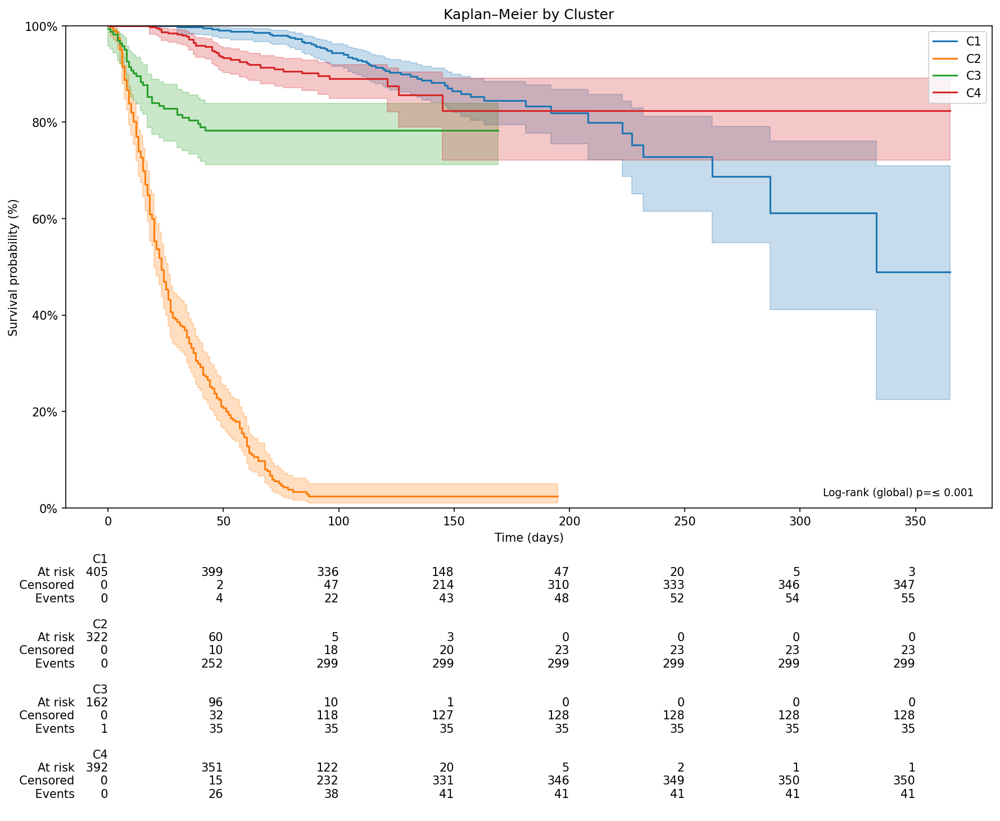

In [18]:
res = km_by_cluster_medcalc(
    df=df,
    time_col="stday",
    event_col="death_label",
    group_col="Cluster_Labels",
    show_ci=True,
    show_risk_table=True,
    save_path=Path(ipt_dir) / "km_cluster_C23-27.pdf"
)

print("Global log-rank p:", res["global_p"])
print("Pairwise p (Bonferroni):", res["pairwise_p"])
print("N per group:", res["n_per_group"])
res

In [39]:
analyse_dataframe(df[['Cluster_Labels']])

,NaN Counts,NaN Ratios (%),Unique Values Count
Cluster_Labels,0,0.0,27


In [40]:
df_ = df.copy()
df_["Cluster_Labels"] = pd.to_numeric(df_["Cluster_Labels"], errors="coerce").astype("Int64")

# Filtering
keep_clusters = [23, 24, 25, 26, 27]
df_ = df_.loc[df_["Cluster_Labels"].isin(keep_clusters)].copy()
df_["Cluster_Labels"] = pd.Categorical(
    df_["Cluster_Labels"].astype(int),
    categories=keep_clusters,
    ordered=True
)

for c in ["stday", "death_label"]:
    if c in df_.columns:
        df_[c] = pd.to_numeric(df_[c], errors="coerce")

print(df_["Cluster_Labels"].value_counts(dropna=False).sort_index())

Cluster_Labels
23     202
24    1156
25     760
26     426
27     234
Name: count, dtype: int64


In [ ]:
## Heatmap

In [56]:
data[['sga']]

,sga
idx_code,
3,0
7,0
8,0
15,0
38,0
...,...
20390,1
20391,1
20393,0


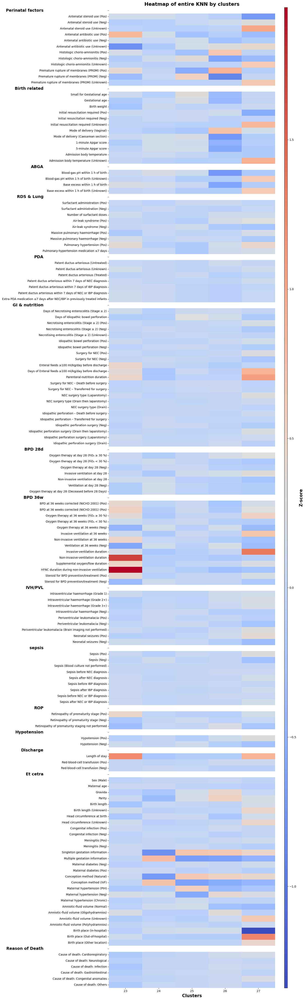

In [57]:
df_ana = data.copy()

ipt1_dir = f'{crt_path}/Results/M13'    # 고정
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features_EN).xlsx"))
df_dic = df_dic[['cat_name', 'col_name', 'feature_name']]

num_cols = df_ana.select_dtypes(include=[np.number]).columns.tolist()
columns_to_scale = [c for c in num_cols if c != 'Cluster_Labels']

# Sscaling
scaler = StandardScaler()
df_ana[columns_to_scale] = scaler.fit_transform(df_ana[columns_to_scale])

selected_cols = df_dic['col_name'].tolist()
selected_cols_present = [c for c in selected_cols if c in df_ana.columns]
df_selected = df_ana[selected_cols_present + ['Cluster_Labels']].copy()
df_heatmap = df_selected.groupby('Cluster_Labels').mean().T.reindex(selected_cols_present)


expanded_idx, expanded_data = [], []
previous_cat = None
cat_name_positions, cat_labels = [], []
current_pos = 0

for cat, col, fname in zip(df_dic['cat_name'], df_dic['col_name'], df_dic['feature_name']):
    if col not in df_heatmap.index:
        continue  # 존재하지 않는 feature는 건너뜀

    if cat != previous_cat:
        # 카테고리 경계(빈 줄 한 줄 삽입)
        expanded_idx.append('')
        expanded_data.append([np.nan] * df_heatmap.shape[1])
        cat_name_positions.append(current_pos + 0.5)
        cat_labels.append(cat)
        current_pos += 1
        previous_cat = cat

    label = fname if (pd.notna(fname) and str(fname).strip() != '') else col
    expanded_idx.append(label)
    expanded_data.append(df_heatmap.loc[col].values)
    current_pos += 1

df_heatmap_expanded = pd.DataFrame(expanded_data, index=expanded_idx, columns=df_heatmap.columns)

# ===== Plot =====
mask = df_heatmap_expanded.isna().copy()
mask[df_heatmap_expanded.index == ''] = True

fig = plt.figure(figsize=(15, max(6, len(df_heatmap_expanded) * 0.30)))
gs = GridSpec(1, 7, width_ratios=[1, 1, 1, 1, 1, 0.1, 0.1], figure=fig)

ax = fig.add_subplot(gs[0, :5])

sns.heatmap(
    df_heatmap_expanded,
    cmap='coolwarm',
    annot=False,
    cbar=False,
    linewidths=0,
    mask=mask,
    ax=ax
)

# ytick: 빈 문자열은 공백으로
yticks_labels = [' ' if idx == '' else idx for idx in df_heatmap_expanded.index.tolist()]
ax.set_yticks(np.arange(len(yticks_labels)) + 0.5)
ax.set_yticklabels(yticks_labels, fontsize=10, fontweight='normal')

ax.set_xlabel('Clusters', fontsize=15, fontweight='bold')
ax.set_title('Heatmap of entire KNN by clusters', fontsize=17, fontweight='bold')

# 좌측에 카테고리 라벨 전용 축
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(cat_name_positions)
ax2.spines['left'].set_position(('outward', 180))
ax2.tick_params(axis='y', pad=6)
plt.subplots_adjust(left=0.22)
ax2.set_yticklabels(cat_labels, fontsize=14, fontweight='bold', va='center', ha='right')

# 테두리/눈금 정리
ax2.tick_params(axis='y', length=0)
for side in ['top','right','bottom','left']:
    ax2.spines[side].set_visible(False)
ax2.set_xlim(ax.get_xlim())
ax2.set_ylabel('')
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_left()
ax2.yaxis.set_tick_params(pad=50)

# 컬러바
cbar_ax = fig.add_subplot(gs[0, 6])
hm = ax.collections[0]
cb = fig.colorbar(hm, cax=cbar_ax)
cb.set_label('Z-score', rotation=90, fontsize=15, labelpad=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(ipt_dir, "C23-27_Heatmap_EN plot.pdf"), format='pdf', bbox_inches='tight')
plt.show()

In [242]:
for column in data.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {data[column].dtype}")
    print(f"유니크한 값:")
    print(data[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.          9.
  1.          3.         10.          2.          6.92736054  0.        ]
----------------------------------------
칼럼 이름: bwei
데이터 타입: int64
유니크한 값:
[1350  790 1400 1340 1240  810 1300 1380  990 1180 1475 1450 1485  960
  910  730 1370 1205 1440 1390 1480 1290 1210 1455 1200 1360 1470 1015
  860  865 1130 1090  920 1260 1220 1320  980  660  600 1270  940 1080
 1190 1490 1040  930  670 1160  480 1330 1250 1460 1310  473  840  850
 1140  610  950 1070 1060  720  680  770 1170  710 1061 1002 1120 1020
  922 1037 1031  765  438 1243  880 1306 1472  708 1376  924  970 1150
 1245 1065 1100 14

In [4]:
ipt = r'C:/Dev_AIWM/jupyter/KNN/1212_M02/creatures'

df = pd.read_csv(f"{ipt}/knn_prep-fin_M08c.csv")
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M08-alive.csv")
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
print(len(df.columns))
## 기존 세팅
# datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
#                  , 'acldt', 'birthdt', 'bsfdt1', 'bsfdt3', 'admd'
#                  , 'prho', 'promd', 'promh', 'prdh', 'dth36dt'    # 01-24 추가됨 ('promh', 'prdh', 'dth36dt')
#                  , 'fsfdt1', 'fsfdt2', 'birtm', 'bird']
# drop_cols = ['apguk1', 'apguk5', 'fetc2', 'fetc', 'strduot', 'metc', 'ibifcmt', 'lbpdot'
#              , 'bhdcut', 'bhtcut', 'iperrdt', 'phudot', 'phudstdt', 'sftum', 'sftuh', 'sftfudt'
#              , 'sftthdt', 'birdm', 'birdh', 'sign'
#              , 'promn'    # 01-24 추가됨
#             ]



print(len(df.columns), '\n')

# drop_cols = []    # ~0530
drop_cols = [
#     PDA_7d_NTET
#     PDA_7d_IPERR
#     PDA_7d_IPERRorNTET
#     7d_PDA
#     NTET_day
#     ntet_1
#     ntet_0
#     ntet_Unknown
#     iperr_2
#     iperr_1
#     ntety_2
#     ntety_1
#     ntety_3
#     ntety_4
#     ntetoy_2
#     ntetoy_3
#     ntetoy_1
#     iperr_3
#     iperr_4
#     iperroy_1
#     iperroy_4
#     iperroy_3
#     iperroy_2
#     bdp
#     bdp_Moderate+
#     oxyt36_3
#     oxyt36_2
#     oxyt36_1
#     arre36_6
#     arre36_7
#     arre36_0
#     niarvhfnc
#     pvl_3
#     pvl_1
#     pvl_2
#     seps_3
#     SEPS_bef_NTET
#     SEPS_aft_NTET
#     SEPS_bef_IPERR
#     SEPS_aft_IPERR
#     SEPS_bef_IPERRorNTET
#     SEPS_aft_IPERRorNTET
#     stday
#     death_CR
#     death_NL
#     death_Inf
#     death_GI
#     death_CA
#     death_Otr
    'ga'    # 06/28 added
]
print('len(drop_cols): ', len(drop_cols), '\n')


datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
                ]
drop_cols += datetime_cols
print('len(drop_cols): ', len(drop_cols), '\n')


rsndth_cols = ['death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr']
drop_cols += rsndth_cols
print('len(drop_cols): ', len(drop_cols))
print("drop_cols:", drop_cols)
# df = df.drop(columns=list(drop_cols))

target_keys = ['ntet_', 'ntety_', 'ntetoy_'
               , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
               , 'NTET_day', 'PDA_7d_NTET'
               , 'invfpod'
               , 'iperr_', 'iperroy_'
               , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
               , 'IPERR_day', 'PDA_7d_IPERR', 'PDA_7d_IPERRorNTET'
               , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
               
               , '7d_PDA'
               , 'bdp', 'bdp_Moderate+', 'strdu_'
               , 'inhg_', 'pvl_', 'nese_'
               , 'seps_3'
               , 'pmirnsg_', 'pmirnsgnd'
               , 'stday'

               , 'oxyt36_', 'arre36_'    # 05/31 Added
               , 'bwei'    # 06/28 added
               , 'btem', 'bhei', 'bhead'    # 07/10 added
              ]
tgt_cols = [col for col in df.columns
            if col in target_keys or any(col.startswith(prefix) for prefix in target_keys)
           ]
print('len(tgt_cols): ', len(tgt_cols))
print("tgt_cols:", tgt_cols)




# tgt_cols = [col for col in df.columns if col in ['ntet', 'ntety', 'ntetoy'
#                                                     , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
#                                                     , 'NTET_day', 'PDA_7d_NTET'
#                                                     , 'invfpod'
#                                                     , 'iperr', 'iperroy'
#                                                     , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
#                                                     , 'IPERR_day', 'PDA_7d_IPERR'
#                                                     , 'PDA_7d_IPERRorNTET'
#                                                     , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
#                                                    ]
#             or any(col.startswith(prefix) for prefix in ['ntet', 'ntety', 'ntetoy'
#                                                          , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
#                                                          , 'NTET_day', 'PDA_7d_NTET'
#                                                          , 'invfpod'
#                                                          , 'iperr', 'iperroy'
#                                                          , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
#                                                          , 'IPERR_day', 'PDA_7d_IPERR'
#                                                          , 'PDA_7d_IPERRorNTET'
#                                                          , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
#                                                         ])
#            ]




data = df.drop(columns=['death_label', 'Cluster_Labels'] + list(tgt_cols) + list(drop_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )
print('len(data): ', len(data.columns), "--> drop(columns=['death_label'] + list(tgt_cols) + list(drop_cols)")

# # 데이터 표준화 (이진 값을 제외하고 표준화 수행)
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data)
# df_scd = pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

# df_scd['death_label'] = df['death_label']


binary_cols = []
for col in data.columns:
    unique_vals = set(data[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
continuous_cols = [col for col in data.columns if col not in binary_cols]

print("Binary cols:", len(binary_cols))
for col in binary_cols:
    print(f"- {col}")
print("\nContinuous cols:", len(continuous_cols))
for col in continuous_cols:
    print(f"- {col}")
print('len(data): ', len(data.columns))


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[continuous_cols])
df_scd = pd.concat([
    pd.DataFrame(scaled_data, index=data.index, columns=continuous_cols),
    data[binary_cols]
], axis=1)
df_scd = df_scd[data.columns]

df_scd['death_label'] = df['death_label']
df_scd['Cluster_Labels'] = df['Cluster_Labels']
df_scd

173
173 

len(drop_cols):  1 

len(drop_cols):  15 

len(drop_cols):  21
drop_cols: ['ga', 'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt', 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt', 'death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr']
len(tgt_cols):  62
tgt_cols: ['bwei', 'bhei', 'bheiuk', 'bhead', 'bheaduk', 'btem', 'btemuk', 'invfpod', 'pmirnsgnd', 'stday', 'PDA_7d_NTET', 'PDA_7d_IPERR', '7d_PDA', 'PDA_7d_IPERRorNTET', 'SEPS_bef_NTET', 'SEPS_aft_NTET', 'SEPS_bef_IPERR', 'SEPS_aft_IPERR', 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET', 'NTET_day', 'IPERR_day', 'strdu_1', 'strdu_0', 'nese_1', 'nese_0', 'ntet_1', 'ntet_0', 'ntet_Unknown', 'pmirnsg_0', 'pmirnsg_1+', 'inhg_0', 'inhg_1', 'inhg_2+', 'inhg_3+', 'bdp', 'bdp_Moderate+', 'oxyt36_1', 'oxyt36_2', 'oxyt36_3', 'arre36_0', 'arre36_6', 'arre36_7', 'pvl_1', 'pvl_3', 'pvl_2', 'seps_3', 'ntety_1', 'ntety_2', 'ntety_3', 'ntety_4', 'ntetoy_2', 'ntetoy_3', 'ntetoy_1', '

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15228\2904206690.py:3: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{ipt}/knn_prep-fin_M08c.csv")


,sex_sys_val,bir1,bir2,bir3,bir4,apgs1,apgs5,mage,gran,parn,...,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2,death_label,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,0,0,0,0,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,...,0,0,0,1,0,0,1,0,0,4
1,1,0,0,0,0,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,...,1,0,0,0,1,0,0,1,0,6
2,1,1,0,0,0,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,...,0,0,0,1,0,0,1,0,0,2
3,1,0,1,0,0,0.595950,0.037925,-1.710639,-0.760507,-0.636012,...,0,0,0,1,0,0,0,1,0,8
4,1,0,0,0,0,-0.361034,-1.032974,0.590611,1.748735,0.768667,...,0,0,0,0,0,1,1,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0,0,0,0,0.117458,0.573375,-2.401014,-0.760507,-0.636012,...,0,0,0,1,0,0,0,1,0,4
20409,1,0,0,0,0,-0.361034,0.037925,1.050861,0.912321,0.768667,...,1,0,0,0,1,0,0,1,0,6
20410,0,0,0,0,0,0.117458,0.037925,-0.790139,0.075907,-0.636012,...,0,1,0,1,0,0,1,0,0,4


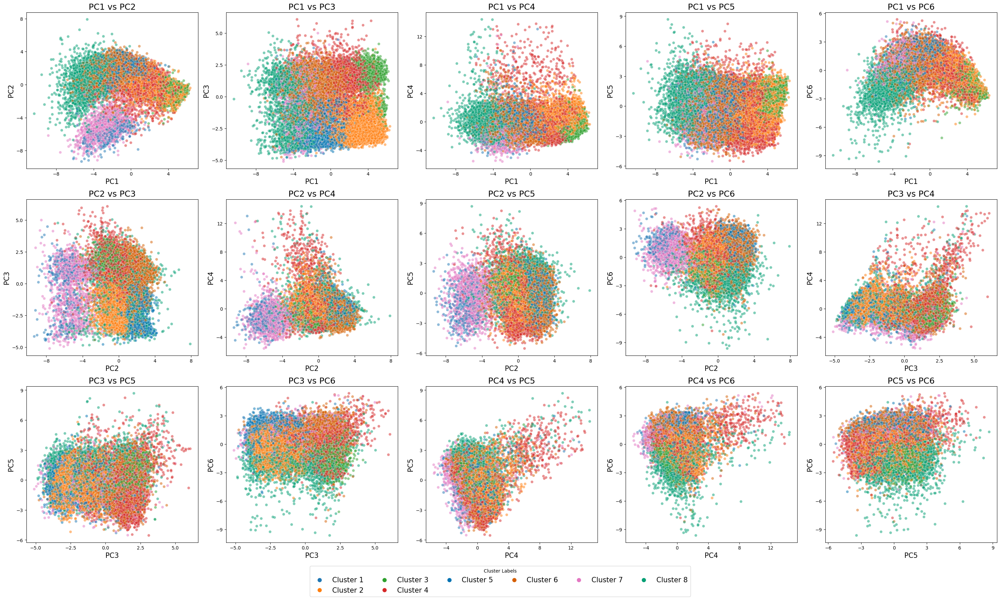

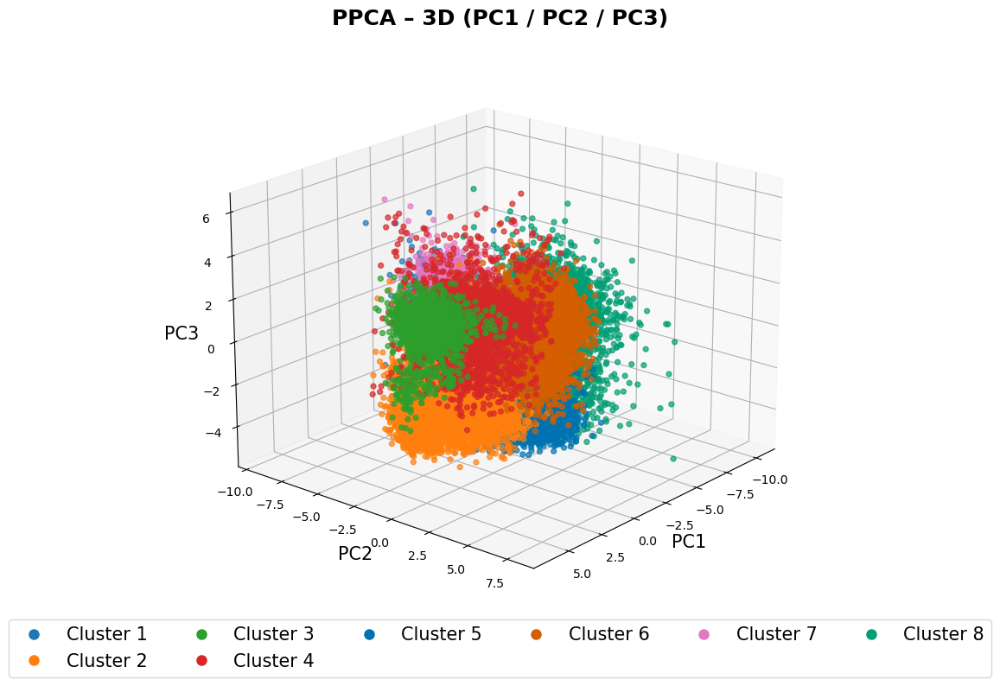

In [5]:
cluster_palette = {
    1: '#1f77b4',  # blue
    2: '#ff7f0e',  # orange
    3: '#2ca02c',  # green
    4: '#d62728',  # red
    5: "#0072B2",  # blue
#     5: '#9467bd',  # purple
    6: "#D55E00",  # vermillion
#     6: '#8c564b',  # brown
    7: '#e377c2',  # pink
#     8: '#7f7f7f',  # gray
    8: "#009E73",  # green
}

def build_palette(base_palette: dict, labels):
    """기존 팔레트 우선, 누락된 라벨은 기본 컬러사이클에서 채움(중복색 피함)."""
    labels = sorted(pd.unique(pd.Series(labels).dropna()))
    final = {}
    used = set(base_palette.get(k) for k in base_palette)  # 이미 지정된 색 이름/코드
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    cidx = 0
    for lab in labels:
        if lab in base_palette:
            final[lab] = base_palette[lab]
        else:
            # 아직 안 쓴 사이클 색 할당
            while cidx < len(cycle) and cycle[cidx] in used:
                cidx += 1
            col = cycle[cidx % len(cycle)]
            final[lab] = col
            used.add(col)
            cidx += 1
    return final


# 1) PPCA: d=6  (라벨/타깃 컬럼 제외하고 적합)
# df_scd에는 'death_label', 'Cluster_Labels'가 포함되어 있으니 제외하고 학습
feature_cols = [c for c in df_scd.columns if c not in ['death_label', 'Cluster_Labels']]
X_ppca = df_scd[feature_cols].values

ppca_model = PPCA()
ppca_model.fit(X_ppca, d=6)
pca_result = ppca_model.transform()

# 결과 DF (+ 라벨 부착)
df_pca = pd.DataFrame(pca_result,
                      columns=['PC1','PC2','PC3','PC4','PC5','PC6'],
                      index=df_scd.index)
df_pca['Cluster_Labels'] = df_scd['Cluster_Labels'].values

fontsize = 15
titlesize = 18

# 실존하는 라벨만 추출해 팔레트 확정
uniq_cls = sorted(pd.unique(df_pca['Cluster_Labels'].dropna()))
final_palette = build_palette(cluster_palette, uniq_cls)


# 2) 2D 페어 플롯 (모든 조합: C(6,2)=15 → 3×5)
pairs = [(f'PC{i}', f'PC{j}') for i in range(1,7) for j in range(i+1,7)]
nrows, ncols = 3, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(30, 18))
axes = axes.flatten()

for ax, (x_comp, y_comp) in zip(axes, pairs):
    sns.scatterplot(
        x=x_comp, y=y_comp, hue="Cluster_Labels",
        palette=final_palette, alpha=0.5, data=df_pca,
        legend=False, ax=ax
    )
    ax.set_title(f"{x_comp} vs {y_comp}", fontsize=titlesize)
    ax.set_xlabel(x_comp, fontsize=fontsize)
    ax.set_ylabel(y_comp, fontsize=fontsize)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    # 개별 축 범례 제거(명시)
    leg = ax.get_legend()
    if leg: leg.remove()
    ax.legend([], [], frameon=False)

# 공통 범례(하단 중앙) — "Cluster {label}"
proxy_handles = [
    Line2D([0],[0], marker='o', linestyle='', markersize=8,
           color=final_palette.get(cl, 'C0'))
    for cl in uniq_cls
]
proxy_labels = [f"Cluster {cl}" for cl in uniq_cls]

fig.legend(proxy_handles, proxy_labels, title="Cluster Labels",
           loc='lower center', ncol=min(6, len(proxy_labels)),
           fontsize=fontsize)

plt.tight_layout(rect=[0, 0.06, 1, 1])  # 하단 범례 공간
plt.show()


# 3) 3D 산점도 (PC1/PC2/PC3)
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection='3d')

for cl in uniq_cls:
    m = (df_pca['Cluster_Labels'] == cl).values
    ax3d.scatter(df_pca.loc[m, 'PC1'],
                 df_pca.loc[m, 'PC2'],
                 df_pca.loc[m, 'PC3'],
                 s=18, alpha=0.7, color=final_palette.get(cl, 'C0'))

ax3d.set_xlabel("PC1", fontsize=fontsize)
ax3d.set_ylabel("PC2", fontsize=fontsize)
ax3d.set_zlabel("PC3", fontsize=fontsize)
ax3d.set_title("PPCA – 3D (PC1 / PC2 / PC3)", fontsize=titlesize, fontweight='bold')
ax3d.view_init(elev=20, azim=40)

fig3d.legend(proxy_handles, proxy_labels, loc='lower center',
             ncol=min(6, len(proxy_labels)), fontsize=fontsize)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

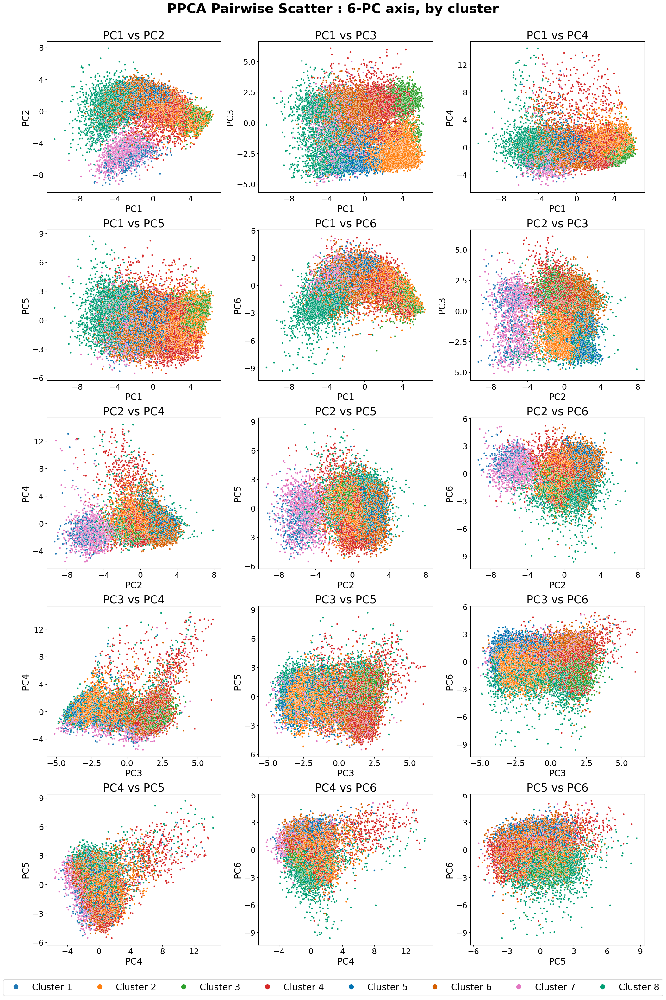

OSError: [Errno 22] Invalid argument: 'C:/Dev_AIWM/jupyter/KNN/1212_M02/creatures\\figs\\ppca_pairs_all_withSubTitles_CMYK.tif'

In [7]:
def build_palette(base_palette: dict, labels):
    labels = sorted(pd.unique(pd.Series(labels).dropna()))
    final, used = {}, set(base_palette.values())
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    i = 0
    for lab in labels:
        if lab in base_palette:
            final[lab] = base_palette[lab]
        else:
            while i < len(cycle) and cycle[i] in used:
                i += 1
            col = cycle[i % len(cycle)]
            final[lab] = col
            used.add(col); i += 1
    return final

# # --- 1) 사용 조합(3×3) ---
# selected_pairs = [
#     ('PC1','PC2'), ('PC2','PC3'), ('PC1','PC3'),
#     ('PC1','PC4'), ('PC2','PC4'), ('PC3','PC4'),
#     ('PC1','PC5'), ('PC2','PC5'), ('PC4','PC5'),
# ]

selected_pairs = [
    ('PC1','PC2'), ('PC1','PC3'), ('PC1','PC4'),
    ('PC1','PC5'), ('PC1','PC6'), ('PC2','PC3'), 
    ('PC2','PC4'), ('PC2','PC5'), ('PC2','PC6'),
    ('PC3','PC4'), ('PC3','PC5'), ('PC3','PC6'),
    ('PC4','PC5'), ('PC4','PC6'), ('PC5','PC6'),
]


# fontsize, titlesize = 18, 22
fontsize, titlesize = 20.5, 25
uniq_cls = sorted(pd.unique(df_pca['Cluster_Labels'].dropna()))
final_palette = build_palette(cluster_palette, uniq_cls)

# --- 2) 플롯 & 저장 ---
fig, axes = plt.subplots(5, 3, figsize=(20, 32))
axes = axes.ravel()

# 상단 공통 제목
fig.suptitle("PPCA Pairwise Scatter : 6-PC axis, by cluster"
             , fontsize=30, fontweight='bold', y=0.985
            )

for ax, (x_comp, y_comp) in zip(axes, selected_pairs):
    sns.scatterplot(
        x=x_comp, y=y_comp, hue="Cluster_Labels",
        data=df_pca, palette=final_palette,
        alpha=1, s=16,  # ← 더 진하고 크게
        legend=False, ax=ax
    )
#     ax.set_title(f"{x_comp} vs {y_comp}", fontsize=titlesize)
    ax.set_xlabel(x_comp, fontsize=fontsize)
    ax.set_ylabel(y_comp, fontsize=fontsize)
    ax.tick_params(axis="both", labelsize=18)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    # 개별 범례 제거(명시)
    leg = ax.get_legend()
    if leg: leg.remove()
    ax.legend([], [], frameon=False)

# 공통 범례(하단 중앙) — "Cluster {label}"
proxy_handles = [Line2D([0],[0], marker='o', linestyle='',
                        markersize=10,  # ← 범례 마커도 키움
                        color=final_palette.get(cl, 'C0'))
                 for cl in uniq_cls]
proxy_labels = [f"Cluster {cl}" for cl in uniq_cls]
fig.legend(proxy_handles, proxy_labels,# , title="Cluster Labels"
           loc='lower center', ncol=min(8, len(proxy_labels)),
           fontsize=fontsize, frameon=True)

# 하단 범례/상단 제목 공간 확보
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# ❶ Jupyter에서 바로 보기
plt.show()

# ❷ PDF 저장
out_dir = os.path.join(ipt, "figs")
# os.makedirs(out_dir, exist_ok=True)
pdf_path = os.path.join(out_dir, "ppca_pairs_all_fin.pdf")
# fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
# plt.close(fig)

tif_rgb_path = os.path.join(out_dir, "ppca_pairs_all_fin_RGB.tif")
fig.savefig(
    tif_rgb_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"}
)

# (C) TIFF를 CMYK로 변환 (저널 규칙 대응)
from PIL import Image
tif_cmyk_path = os.path.join(out_dir, "ppca_pairs_all_withSubTitles_CMYK.tif")
im = Image.open(tif_rgb_path)
im_cmyk = im.convert("CMYK")
im_cmyk.save(tif_cmyk_path, dpi=(300, 300), compression="tiff_lzw")

plt.close(fig)


print(f"[Saved] {pdf_path}")

In [ ]:
##################################################################################################

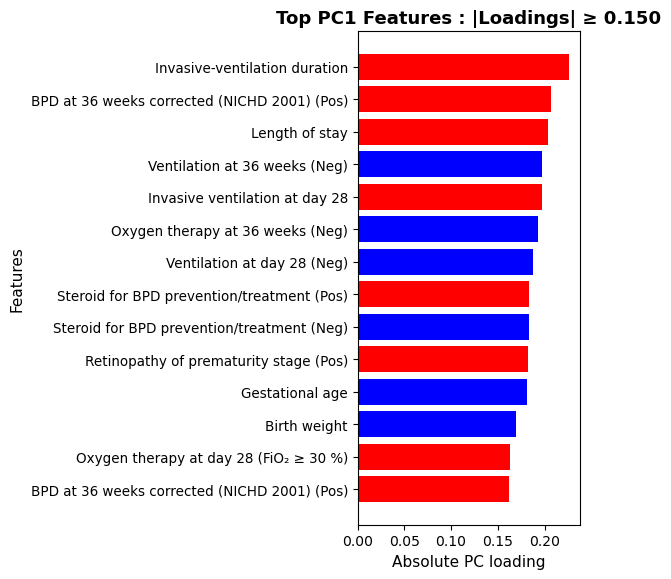

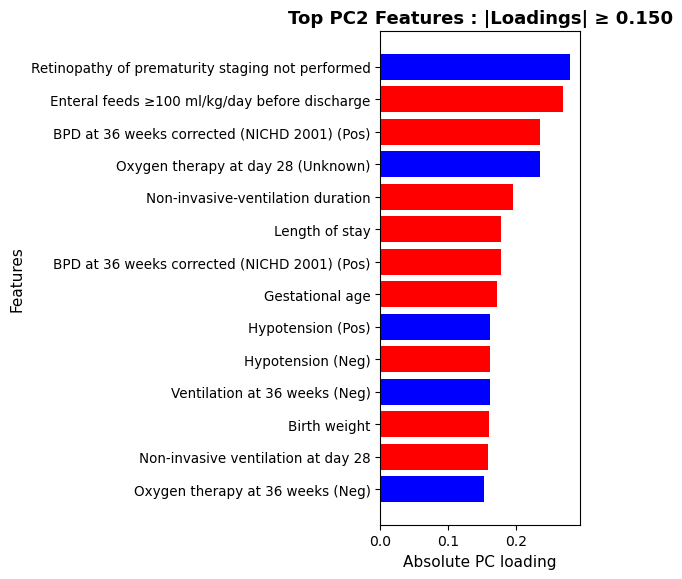

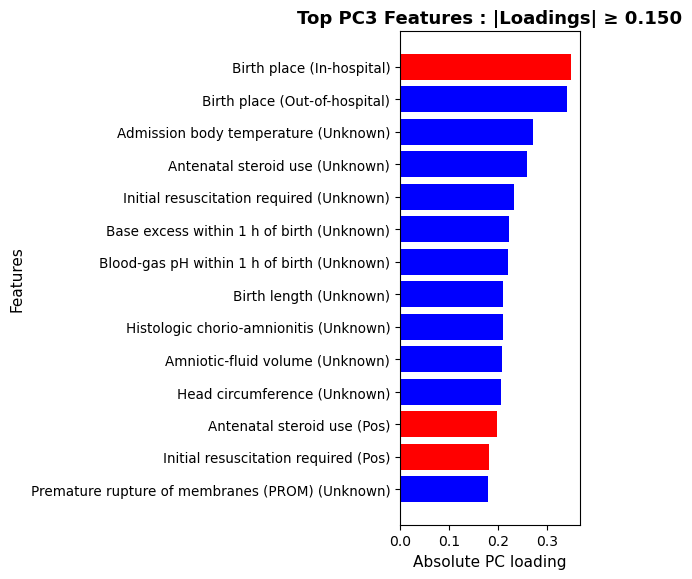

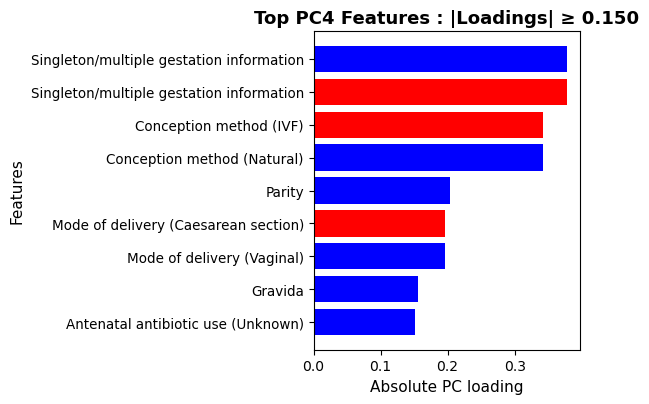

In [19]:
base_dir = r"E:\KNN\Paper works\1\Data, with Deceased_NEC Only\C4_with Deceased_NEC Only"
df = pd.read_csv(os.path.join(base_dir, "PC Loadings_PosNeg.csv"))

# threshold (절대값 기준)
TH = 0.150
pc_list = [1, 2, 3, 4]   # 필요하면 [1,2,3,4,5,...] 식으로 확장

for pc in pc_list:
    feat_col = f"PC{pc} : Feature_EN"
    load_col = f"PC{pc} : PC Loading"

    if feat_col not in df.columns or load_col not in df.columns:
        print(f"[WARN] {feat_col} / {load_col} 이(가) 없음 → PC{pc} 건너뜀")
        continue

    sub = df[[feat_col, load_col]].dropna()

    # |loading| ≥ TH 필터
    sub = sub[sub[load_col].abs() >= TH]

    if sub.empty:
        print(f"[INFO] PC{pc}: |loading| ≥ {TH} 인 feature 없음")
        continue

    # 절대값 기준 내림차순 정렬
    sub = sub.reindex(sub[load_col].abs().sort_values(ascending=False).index)

    features = sub[feat_col].values
    loadings = sub[load_col].values
    abs_loadings = np.abs(loadings)

    # 색: 양수 = 빨강, 음수 = 파랑
    colours = ["red" if v > 0 else "blue" for v in loadings]

    y_pos = np.arange(len(features))

    # feature 개수에 따라 세로 크기 조절
    plt.figure(figsize=(6, max(4, 0.35 * len(features) + 1)))

    # 가로 bar: 한 방향(왼→오)으로만, 값은 절대값
    plt.barh(y_pos, abs_loadings, color=colours)
    plt.xlabel("Absolute PC loading", fontsize=11)
    plt.ylabel("Features", fontsize=11)
    plt.title(f"Top PC{pc} Features : |Loadings| ≥ {TH:.3f}", fontsize=13, fontweight='bold')

    # y축에 feature 이름 붙이고, 큰 loading이 위로 오도록 뒤집기(선택)
    plt.yticks(y_pos, features, fontsize=9.7)
    plt.gca().invert_yaxis()  # 상단에 가장 큰 loading

    plt.tight_layout()

    # 저장하고 싶으면 주석 해제
    out_path = os.path.join(base_dir, f"PC{pc}_loadings_abs{TH:.2f}.pdf")
    plt.savefig(out_path, bbox_inches="tight")

    plt.show()
#     plt.close()

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\ppca\_ppca.py:23: RuntimeWarning: invalid value encountered in divide
  return (X - self.means) / self.stds


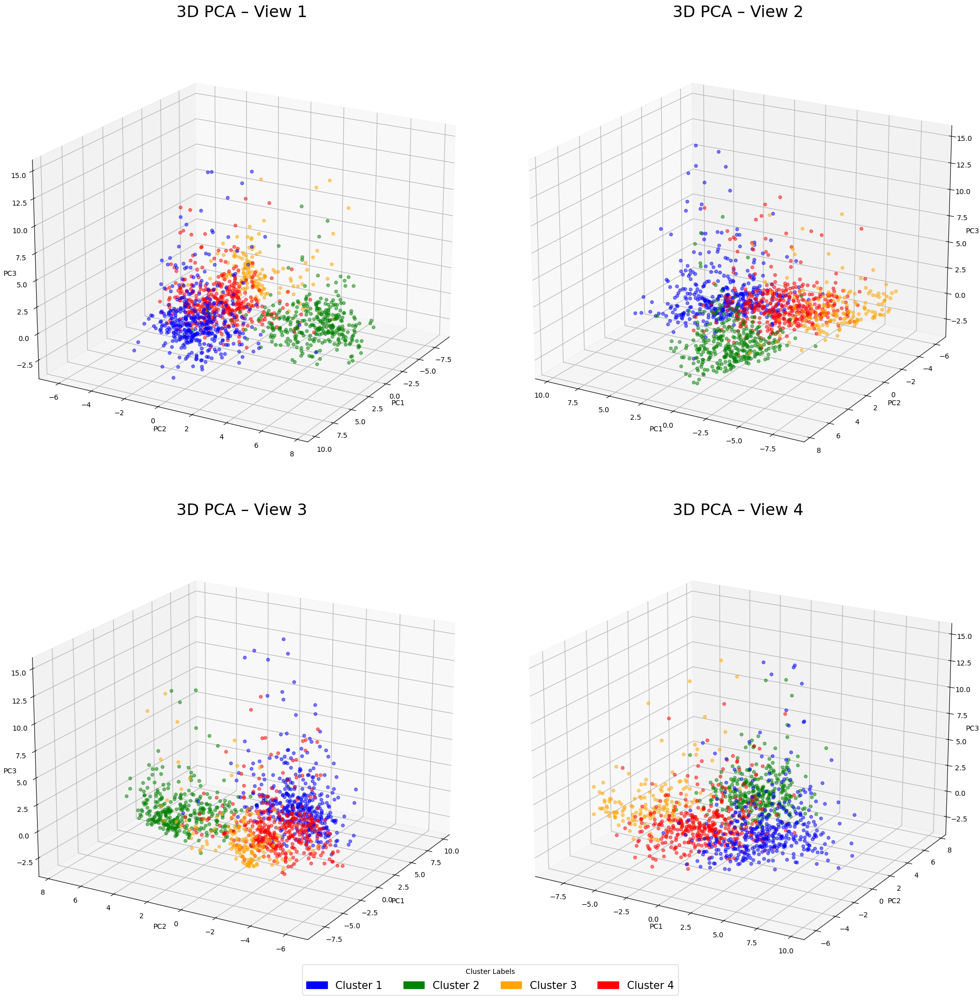

In [20]:
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from ppca import PPCA

# 0) 경로/데이터 로드
base_dir = r"E:\KNN\Paper works\1\Data, with Deceased_NEC Only\Clustering model\C4_with Deceased_NEC Only"
df = pd.read_csv(os.path.join(base_dir, "KNN_df_combined.csv"))

# 1) 사용할 피처 지정
feature_cols = [
    'iarvppd', 'bdp_Moderate+', 'stday', 'arre36_0', 'arre28_6', 'oxyt36_1', 'arre28_0',
    'strdu_1', 'strdu_0', 'pmirnsg_1+', 'ga', 'bwei', 'oxyt28_3', 'bdp', 'EFYN_day',
    'bhead', 'bhei', 'oxyt28_1', 'sft_0', 'sft_1', 'oxyt36_3', 'arre36_6', 'niarvrpd',
    'inhg_1', 'inhg_0', 'pmirnsg_0', 'arre36_7', 'eythtran_1', 'eythtran_0', 'oxyt36_2',
    'sftun', 'apgs1', 'inhg_2+', 'aoxyuppd', 'PDA_TRD', 'lbp_1', 'lbp_0', 'apgs5',
    'oxyt28_4', 'resu_0', 'pda_non-treatment', 'seps_1', 'seps_2', 'ph_1', 'inhg_3+',
    'pmirnsgnd', 'resu_1', 'nese_0', 'nese_1', 'niarvhfnc', 'pvl_2', 'htn_2', 'meni_0',
    'meni_1', 'pvl_1', 'htn_1', 'bbphuk', 'bbbeuk', 'als_1', 'als_0', 'bheaduk', 'prom_0',
    'chor_1', 'bheiuk', 'btem', 'chor_0', 'mph_1', 'mph_0', 'prom_1', 'amni_1', 'atbyn_1',
    'PPHN', 'efyn', 'bbbe', 'prep_1', 'prep_2', '7d_PDA', 'amni_4', 'arre28_7',
    'atbyn_Unknown', 'bbph', 'pda_unknown', 'bpia_1', 'pvl_3', 'bpia_2', 'prom_Unknown',
    'oxyt28_2', 'btemuk', 'amni_2', 'bpia_3', 'ster_Unknown', 'ster_1', 'mulg_multiple',
    'mulg_singleton', 'delm_2', 'delm_1', 'dm_1', 'dm_0', 'resu_Unknown', 'ster_0',
    'atbyn_0', 'htn_3', 'mage', 'parn', 'gran', 'amni_3', 'ibif_1', 'ibif_0', 'sex_sys_val',
    'chor_Unknown', 'seps_3'
]
use_cols = feature_cols

# 2) 클러스터 라벨 확보
assert 'Cluster_Labels' in df.columns, "Cluster_Labels column not found in df."
cluster_labels = df['Cluster_Labels'].copy()

# 3) X 구성 (필요한 컬럼만, 인덱스 유지)
X = df.loc[:, use_cols].copy()

# 4) 타입 분리: 이진 vs 연속 (이진은 고유값 ⊆ {0,1})
binary_cols = [c for c in X.columns if set(pd.unique(X[c].dropna())).issubset({0,1})]
continuous_cols = [c for c in X.columns if c not in binary_cols]

# 5) 결측치 처리
# - 연속형: 중앙값으로 채움
# - 이진형: 최빈값(동점시 첫 값)으로 채움
X_proc = X.copy()
for c in continuous_cols:
    med = X_proc[c].median(skipna=True)
    X_proc[c] = X_proc[c].fillna(med)
for c in binary_cols:
    mode_val = X_proc[c].mode(dropna=True)
    fillv = mode_val.iloc[0] if not mode_val.empty else 0
    X_proc[c] = X_proc[c].fillna(fillv)

# 6) 연속형만 표준화 → df_scd 구성(연속형 스케일 + 이진 통과)
scaler = StandardScaler()
X_scd = X_proc.copy()
if continuous_cols:
    X_scd[continuous_cols] = scaler.fit_transform(X_proc[continuous_cols])
df_scd = X_scd  # 최종 스케일된 DF

# 7) PPCA(4D) 학습 및 변환
ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=4)
pca_result = ppca_model.transform()   # (n_samples, 4)

# 8) 결과 DF 구성
df_pca = pd.DataFrame(pca_result, columns=['PC1','PC2','PC3','PC4'], index=df_scd.index)
df_pca['Cluster_Labels'] = cluster_labels.values

# 9) 3D 산점도 (PC1, PC2, PC3) - 4개의 뷰
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (필수 임포트)
cluster_palette = {1:'blue', 2:'green', 3:'orange', 4:'red'}
view_angles = [(20,30), (20,120), (20,210), (20,300)]
fontsize, titlesize = 15, 23

fig = plt.figure(figsize=(20,20))
for i, (elev, azim) in enumerate(view_angles, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    for cl, col in cluster_palette.items():
        sel = (df_pca['Cluster_Labels'] == cl)
        if sel.sum() == 0:
            continue
        ax.scatter(df_pca.loc[sel, 'PC1'],
                   df_pca.loc[sel, 'PC2'],
                   df_pca.loc[sel, 'PC3'],
                   c=col, alpha=0.5, s=20, label=f'Cluster {cl}')
    # 내부 legend 제거
    if ax.legend_:
        ax.legend_.remove()
    ax.set_title(f'3D PCA – View {i}', fontsize=titlesize)
    ax.set_xlabel('PC1', labelpad=0)
    ax.set_ylabel('PC2', labelpad=0)
    ax.set_zlabel('PC3', labelpad=0)
    ax.view_init(elev=elev, azim=azim)

# 통합 범례
handles = [mpatches.Patch(color=col, label=f'Cluster {cl}')
           for cl, col in cluster_palette.items()]
fig.legend(handles=handles, title='Cluster Labels', loc='lower center',
           ncol=4, fontsize=fontsize)

plt.tight_layout()
plt.show()

In [21]:
df

,idx_code,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
0,3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,...,0,1,0,0,0,1,0,0,0,4
1,4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,...,0,1,0,0,0,1,0,0,0,4
2,44,1,2013-07-22,2013-07-22,2013-07-22,1.0,5.0,990,32,1,...,0,1,0,0,0,1,0,0,0,4
3,46,1,2013-10-18,2013-10-18,2013-10-18,9.0,10.0,600,35,1,...,0,1,0,0,0,1,0,0,0,3
4,72,0,2013-07-09,2013-07-09,2013-07-09,1.0,5.0,473,35,1,...,0,1,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277,20262,0,2022-01-07,2022-01-07,2022-01-07,6.0,8.0,1090,32,1,...,0,0,0,0,1,1,0,0,0,4
1278,20297,1,2022-04-07,2022-04-07,2022-04-07,1.0,6.0,710,31,3,...,0,1,0,0,0,1,0,0,0,2
1279,20312,0,2022-09-24,2022-09-24,2022-09-24,5.0,8.0,1260,32,3,...,0,1,0,0,0,1,0,0,0,4
1280,20387,0,2022-01-08,2022-01-08,2022-01-08,2.0,6.0,740,36,1,...,0,1,0,0,0,1,0,0,0,1


Global range: 0.00 ~ 196.00


C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

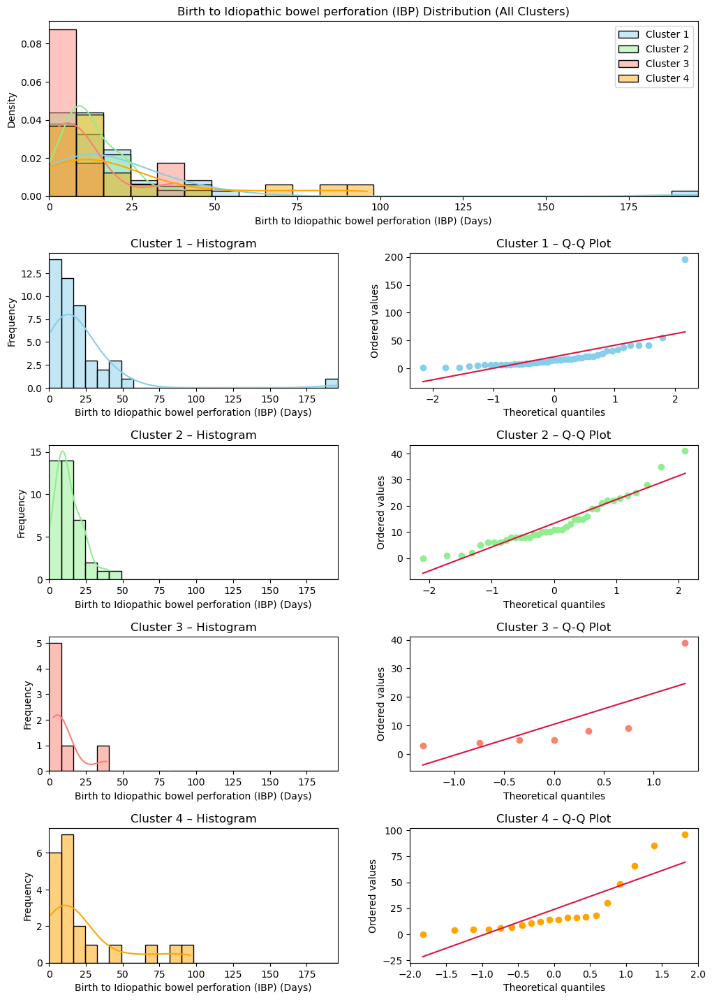

Plot saved → E:\KNN\Paper works\1\Data, with Deceased_NEC Only\Clustering model\C4_with Deceased_NEC Only\M01_Idiopathic bowel perforation (IBP)_Histo+KDE-QQ_plt.pdf


In [27]:
ga = df['IPERR_day']  # 분포에 사용할 변수
col = 'Idiopathic bowel perforation (IBP)'

clusters = cluster_labels
cl_ids   = sorted(clusters.dropna().unique())
colours  = ['skyblue', 'lightgreen', 'salmon', 'orange'][:len(cl_ids)]

# 출력 경로 (예시)
ipt_dir = base_dir

# 1) 전역 X축 범위 및 bin 설정
xmin, xmax = np.nanmin(ga), np.nanmax(ga)
bins = np.linspace(xmin, xmax, 25)   # 모든 히스토그램에서 동일 bin 사용

print(f"Global range: {xmin:.2f} ~ {xmax:.2f}")

# Plotting
n  = len(cl_ids)
fig = plt.figure(figsize=(12, 3.5*(n+1)))
gs  = gridspec.GridSpec(
        nrows=n+1, ncols=2,
        height_ratios=[1.3] + [1]*n,        
        hspace=0.4, wspace=0.25
      )

# ── (A) 전체 분포 ───────────────────────────────
ax_all = fig.add_subplot(gs[0, :])
for cl, colour in zip(cl_ids, colours):
    sns.histplot(
        ga[clusters == cl], stat='density', kde=True,
        bins=bins, color=colour, label=f'Cluster {cl}',
        alpha=0.45, edgecolor='black', ax=ax_all
    )
ax_all.set_xlim(xmin, xmax)
# ax_all.set_title(f'Birth to {col} Achieving (≥100 ml/kg/day) Distribution (All Clusters)')
# ax_all.set_xlabel(f'Birth to {col} Achieving (Days)')
ax_all.set_title(f'Birth to {col} Distribution (All Clusters)')
ax_all.set_xlabel(f'Birth to {col} (Days)')
ax_all.set_ylabel('Density')
ax_all.legend()

# ── (B) 각 클러스터별 히스토그램 + Q-Q ──────────
for i, (cl, colour) in enumerate(zip(cl_ids, colours), start=1):
    subset = ga[clusters == cl].dropna()

    # Histogram  →  왼쪽
    ax_hist = fig.add_subplot(gs[i, 0])
    sns.histplot(subset, bins=bins, kde=True,
                 color=colour, edgecolor='black', ax=ax_hist)
    ax_hist.set_xlim(xmin, xmax)               # 동일 x축
    ax_hist.set_ylim(0, None)                  # y축 자동
    ax_hist.set_title(f'Cluster {cl} – Histogram')
    ax_hist.set_xlabel(f'Birth to {col} (Days)')
    ax_hist.set_ylabel('Frequency')

    # Q-Q plot   →  오른쪽
    ax_qq = fig.add_subplot(gs[i, 1])
    stats.probplot(subset, dist="norm", plot=ax_qq)
    ax_qq.get_lines()[0].set_markerfacecolor(colour)
    ax_qq.get_lines()[0].set_markeredgecolor(colour)
    ax_qq.get_lines()[1].set_color('crimson')
    ax_qq.set_title(f'Cluster {cl} – Q-Q Plot')
    ax_qq.set_xlabel('Theoretical quantiles')
    ax_qq.set_ylabel('Ordered values')


plt.tight_layout()
plt.show()

save_path = os.path.join(ipt_dir, f'M01_{col}_Histo+KDE-QQ_plt.pdf')
fig.savefig(save_path, bbox_inches='tight')
plt.close(fig)

print(f"Plot saved → {save_path}")

In [62]:
# ipt_dir = f'{crt_path}/Results/M14_dM06/2_SurvOnly/1_ALL/C4'
ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'

df_ana = pd.read_csv(os.path.join(ipt_dir, "df_scd_clustered.csv"))
# df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
# df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})
# 'death36' 컬럼 제외
if 'death36' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death36'])
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])

# Cluster Labels 분리
cluster_labels = df_ana['Cluster_Labels']
df_scd = df_ana.drop(columns=['Cluster_Labels'])    # , 'idx_code' --> Index

df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,oxyt36_3,arre36_0,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,-0.361034,-1.032974,0.867691,-1.020264,-0.760507,-0.636012,0.685902,0.0,0.827566,...,0,1,0,0,1,0,0,1,0,0
1,1,-0.361034,-1.032974,-1.001814,0.360486,-0.760507,-0.636012,-0.622812,0.0,-1.218738,...,0,1,0,0,1,0,0,0,1,0
2,1,0.117458,-0.497525,1.034612,-1.710639,-0.760507,-0.636012,0.685902,0.0,1.032196,...,0,1,0,0,1,0,0,1,0,0
3,1,0.595950,0.037925,0.834307,-1.710639,-0.760507,-0.636012,-0.149447,0.0,0.827566,...,0,1,0,0,0,1,0,0,1,0
4,1,-0.361034,-1.032974,0.500467,0.590611,1.748735,0.768667,1.521251,0.0,0.213674,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.117458,0.573375,0.867691,-2.401014,-0.760507,-0.636012,0.268227,0.0,0.622935,...,0,1,0,0,1,0,0,0,1,0
20409,1,-0.361034,0.037925,-0.768126,1.050861,0.912321,0.768667,-0.845572,0.0,-1.014108,...,1,0,0,1,1,0,0,0,1,0
20410,0,0.117458,0.037925,2.737197,-0.790139,0.075907,-0.636012,1.660476,0.0,1.236826,...,0,1,0,0,1,0,0,1,0,0


In [165]:
ipt_dir1 = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/30%-6PCs'
ipt_dir = r'C:/Dev_AIWM/jupyter/KNN/1212_M02/creatures'

df_ana = pd.read_csv(os.path.join(ipt_dir, "knn_prep-fin_M08.csv"))
if 'Unnamed: 0' in df_ana.columns:
    df_ana = df_ana.rename(columns={'Unnamed: 0': 'idx_code'})
df_ana.set_index('idx_code', inplace=True)
# df_ana.set_index('idx_code', inplace=True)

df = df_ana.copy()

explicit_drop_cols = [
    'PDA_7d_NTET', 'PDA_7d_IPERR', 'PDA_7d_IPERRorNTET', '7d_PDA', 'NTET_day',
    'ntet_1', 'ntet_0', 'ntet_Unknown', 'iperr_2', 'iperr_1', 'ntety_2',
    'ntety_1', 'ntety_3', 'ntety_4', 'ntetoy_2', 'ntetoy_3', 'ntetoy_1',
    'iperr_3', 'iperr_4', 'iperroy_1', 'iperroy_4', 'iperroy_3', 'iperroy_2',
    'bdp', 'bdp_Moderate+', 'oxyt36_3', 'oxyt36_2', 'oxyt36_1', 'arre36_6',
    'arre36_7', 'arre36_0', 'niarvhfnc', 'pvl_3', 'pvl_1', 'pvl_2', 'seps_3',
    'SEPS_bef_NTET', 'SEPS_aft_NTET', 'SEPS_bef_IPERR', 'SEPS_aft_IPERR',
    'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET', 'stday',
    'death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr',
    'ga'
]
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt', 'death36'
]
drop_cols = explicit_drop_cols + datetime_cols

target_keys = [
    'ntet_', 'ntety_', 'ntetoy_', 'SEPS_bef_NTET', 'SEPS_aft_NTET', 'NTET_day',
    'PDA_7d_NTET', 'invfpod', 'iperr_', 'iperroy_', 'SEPS_bef_IPERR',
    'SEPS_aft_IPERR', 'IPERR_day', 'PDA_7d_IPERR', 'PDA_7d_IPERRorNTET',
    'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET', '7d_PDA', 'bdp',
    'bdp_Moderate+', 'strdu_', 'inhg_', 'pvl_', 'nese_', 'seps_3',
    'pmirnsg_', 'pmirnsgnd', 'stday', 'oxyt36_', 'arre36_', 'bwei', 'btem',
    'bhei', 'bhead'
]

tgt_cols = [col for col in df.columns
            if col in target_keys or any(col.startswith(prefix) for prefix in target_keys)]
cols_to_drop_set = set(drop_cols) | set(tgt_cols) | {'death_label'}
final_cols_to_drop = list(cols_to_drop_set & set(df.columns))
df_scd = df.drop(columns=final_cols_to_drop)
print(f"Total cols: {df.shape[1]} → Post del: {df_scd.shape[1]} (DELETED: {len(final_cols_to_drop)})")


# Define type(cols)
binary_cols = []
continuous_cols = []
for col in df_scd.columns:
    unique_vals = set(df_scd[col].dropna().unique())
    # 값이 {0, 1}로만 구성된 경우 이진 변수로 간주
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
    else:
        continuous_cols.append(col)
print(f"Binary cols --> {len(binary_cols)}, Continuous cols --> {len(continuous_cols)}")

# Apply SCALER
scaler = StandardScaler()
scaled_cont = pd.DataFrame(scaler.fit_transform(df_scd[continuous_cols])
                           , index=df_scd.index
                           , columns=continuous_cols
                          )
bin_part = df_scd[binary_cols]
df_scd_ = pd.concat([scaled_cont, bin_part], axis=1)

original_order = [col for col in df.columns if col in df_scd_.columns]
df_scd = df_scd_[original_order]
df_scd

Total cols: 172 → Post del: 86 (DELETED: 86)
Binary cols --> 74, Continuous cols --> 12


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25932\3666098721.py:4: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana = pd.read_csv(os.path.join(ipt_dir, "knn_prep-fin_M08.csv"))


,sex_sys_val,bir1,bir2,bir3,bir4,apgs1,apgs5,mage,gran,parn,...,bpia_3,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,0.0,0.0,0.0,0.0,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,1,0
1,1,0.0,0.0,0.0,0.0,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,...,0,0,1,0,0,0,1,0,0,1
2,1,1.0,0.0,0.0,0.0,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,1,0
3,1,0.0,1.0,0.0,0.0,0.595950,0.037925,-1.710639,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,0,1
4,1,0.0,0.0,0.0,0.0,-0.361034,-1.032974,0.590611,1.748735,0.768667,...,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.0,0.0,0.0,0.0,0.117458,0.573375,-2.401014,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,0,1
20409,1,0.0,0.0,0.0,0.0,-0.361034,0.037925,1.050861,0.912321,0.768667,...,0,0,1,0,0,0,1,0,0,1
20410,0,0.0,0.0,0.0,0.0,0.117458,0.037925,-0.790139,0.075907,-0.636012,...,0,0,0,1,0,1,0,0,1,0


In [166]:
analyse_dataframe(df_scd[['death36']])

KeyError: "None of [Index(['death36'], dtype='object')] are in the [columns]"

In [145]:
# -------- 1) 제외 컬럼 정의 --------
datetime_cols = [
    'ntetdt','ntetdty','date362','date36','menidt','pdaddth','pdaddt',
    'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt', 'death36'
]
drop_cols = [
    'ga',  # 06/28 added
    # datetime
    'ntetdt','ntetdty','date362','date36','menidt','pdaddth','pdaddt',
    'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt',
    # 사망 원인
    'death_CR','death_NL','death_Inf','death_GI','death_CA','death_Otr',
    # 기타
    'apguk1','apguk5','fetc2','fetc','strduot','metc','ibifcmt','lbpdot',
    'bhdcut','bhtcut','phudot','phudstdt','sftum','sftuh','sftfudt',
    'sftthdt','birdm','birdh','sign','promn', 'death_label'
]

target_keys = [
    'ntet_', 'ntety_', 'ntetoy_', 
    'SEPS_bef_NTET','SEPS_aft_NTET',
    'NTET_day','PDA_7d_NTET',
    'invfpod',
    'iperr_','iperroy_',
    'SEPS_bef_IPERR','SEPS_aft_IPERR',
    'IPERR_day','PDA_7d_IPERR','PDA_7d_IPERRorNTET',
    'SEPS_bef_IPERRorNTET','SEPS_aft_IPERRorNTET',
    '7d_PDA',
    'bdp','bdp_Moderate+','strdu_',
    'inhg_','pvl_','nese_',
    'seps_3',
    'pmirnsg_','pmirnsgnd',
    'stday',
    'oxyt36_','arre36_',
    'bwei','btem','bhei','bhead'
    , 'death_label'
]

# 실제 존재하는 열만
exists = set(df.columns)
tgt_cols = [c for c in df.columns if (c in target_keys) or any(c.startswith(p) for p in target_keys)]
cols_to_drop = list((set(drop_cols) | set(tgt_cols)) & exists)

if 'Cluster_Labels' in df.columns:
    cols_to_drop.append('Cluster_Labels')

# -------- 2) 드롭 후 최종 데이터 --------
df_scd = df.drop(columns=cols_to_drop)

print(f"총 컬럼: {df.shape[1]} → 제거 후: {df_scd.shape[1]} (제거 {len(cols_to_drop)}개)")
df_scd

총 컬럼: 172 → 제거 후: 88 (제거 84개)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25932\3027509824.py:4: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana = pd.read_csv(os.path.join(ipt_dir, "knn_prep-fin_M08.csv"))


,sex_sys_val,bir1,bir2,bir3,bir4,apgs1,apgs5,mage,gran,parn,...,bpia_3,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,0.0,0.0,0.0,0.0,4.0,5.0,29,1,0,...,0,1,0,0,0,1,0,0,1,0
1,1,0.0,0.0,0.0,0.0,4.0,5.0,35,1,0,...,0,0,1,0,0,0,1,0,0,1
2,1,1.0,0.0,0.0,0.0,5.0,6.0,26,1,0,...,0,1,0,0,0,1,0,0,1,0
3,1,0.0,1.0,0.0,0.0,6.0,7.0,26,1,0,...,0,1,0,0,0,1,0,0,0,1
4,1,0.0,0.0,0.0,0.0,4.0,5.0,36,4,1,...,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.0,0.0,0.0,0.0,5.0,8.0,23,1,0,...,0,1,0,0,0,1,0,0,0,1
20409,1,0.0,0.0,0.0,0.0,4.0,7.0,38,3,1,...,0,0,1,0,0,0,1,0,0,1
20410,0,0.0,0.0,0.0,0.0,5.0,7.0,30,2,0,...,0,0,0,1,0,1,0,0,1,0


In [146]:
df_scd = df.drop(columns=cols_to_drop)

print(f"총 컬럼: {df.shape[1]} → 제거 후: {df_scd.shape[1]} (제거 {len(cols_to_drop)}개)")

# -------- 3) 연속형 vs 이진 변수 구분 --------
binary_cols = []
continuous_cols = []

for col in df_scd.columns:
    unique_vals = set(df_scd[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"이진 변수 {len(binary_cols)}개, 연속형 변수 {len(continuous_cols)}개")

# -------- 4) 스케일링 --------
scaler = StandardScaler()
scaled_cont = pd.DataFrame(
    scaler.fit_transform(df_scd[continuous_cols]),
    index=df_scd.index,
    columns=continuous_cols
)

# -------- 5) 최종 데이터 결합 --------
bin_part = df_scd[binary_cols]
df_scd = pd.concat([scaled_cont, bin_part], axis=1)

# 원래 칼럼 순서 복원
df_scd = df_scd[df.drop(columns=cols_to_drop).columns]

df_scd

총 컬럼: 172 → 제거 후: 88 (제거 84개)
이진 변수 75개, 연속형 변수 13개


,sex_sys_val,bir1,bir2,bir3,bir4,apgs1,apgs5,mage,gran,parn,...,bpia_3,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,0.0,0.0,0.0,0.0,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,1,0
1,1,0.0,0.0,0.0,0.0,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,...,0,0,1,0,0,0,1,0,0,1
2,1,1.0,0.0,0.0,0.0,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,1,0
3,1,0.0,1.0,0.0,0.0,0.595950,0.037925,-1.710639,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,0,1
4,1,0.0,0.0,0.0,0.0,-0.361034,-1.032974,0.590611,1.748735,0.768667,...,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.0,0.0,0.0,0.0,0.117458,0.573375,-2.401014,-0.760507,-0.636012,...,0,1,0,0,0,1,0,0,0,1
20409,1,0.0,0.0,0.0,0.0,-0.361034,0.037925,1.050861,0.912321,0.768667,...,0,0,1,0,0,0,1,0,0,1
20410,0,0.0,0.0,0.0,0.0,0.117458,0.037925,-0.790139,0.075907,-0.636012,...,0,0,0,1,0,1,0,0,1,0


In [167]:
X = df_scd.to_numpy()
n, d = X.shape

# 과적합/퇴화 방지: 성분 수는 랭크보다 1 작게
k = max(1, min(n, d) - 1)

# PPCA 적합
model = PPCA()
model.fit(X, d=k)

# 1) 고유값이 있으면 그걸로 '설명분산비율' 재계산
if hasattr(model, "eig_vals") and model.eig_vals is not None:
    eig = np.asarray(model.eig_vals, dtype=float)
    eig = eig[np.isfinite(eig)]
    s = eig.sum()
    ratio = eig / s if s > 0 else eig * 0.0
else:
    # 2) 예비 플랜: var_exp 사용하되, %/비정규화 대비 보정
    ve = np.asarray(model.var_exp, dtype=float)
    if np.nanmax(ve) > 1.0 + 1e-9:      # 아마 % 단위
        ratio = ve / 100.0
    else:
        s = np.nansum(ve)
        ratio = ve / s if s > 0 else ve * 0.0

# 누적 설명분산 (0~1)
cum = np.cumsum(ratio)

def k_for(th):
    i = int(np.argmax(cum >= th))
    return i+1, float(cum[i])

k30, c30 = k_for(0.30)
k50, c50 = k_for(0.50)
k70, c70 = k_for(0.70)
k90, c90 = k_for(0.90)

print(f"30%: PC1~PC{k30} (cum {c30*100:.2f}%)")
print(f"50%: PC1~PC{k50} (cum {c50*100:.2f}%)")
print(f"70%: PC1~PC{k70} (cum {c70*100:.2f}%)")
print(f"90%: PC1~PC{k90} (cum {c90*100:.2f}%)")

30%: PC1~PC6 (cum 30.67%)
50%: PC1~PC15 (cum 50.93%)
70%: PC1~PC27 (cum 71.00%)
90%: PC1~PC44 (cum 90.98%)


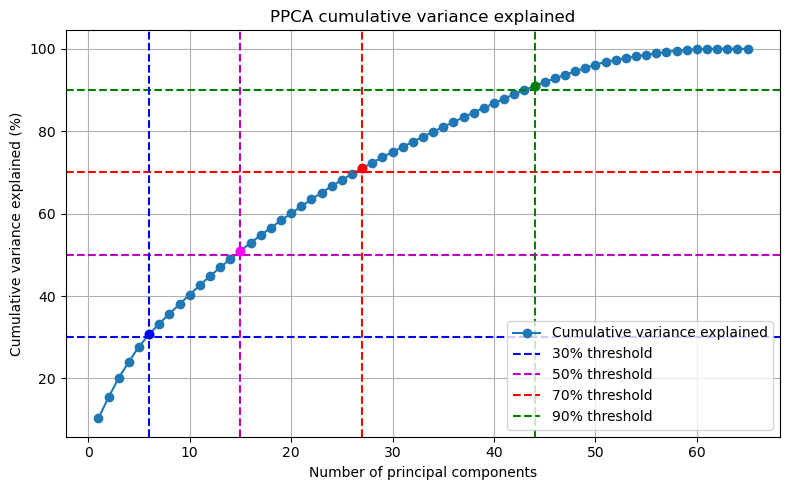

In [168]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum)+1), cum*100, marker='o', label="Cumulative variance explained")

# 기준선
plt.axhline(30, color='b', linestyle='--', label="30% threshold")
plt.axhline(50, color='m', linestyle='--', label="50% threshold")
plt.axhline(70, color='r', linestyle='--', label="70% threshold")
plt.axhline(90, color='g', linestyle='--', label="90% threshold")

# 지점 표시
plt.axvline(k30, color='b', linestyle='--')
plt.axvline(k50, color='m', linestyle='--')
plt.axvline(k70, color='r', linestyle='--')
plt.axvline(k90, color='g', linestyle='--')

plt.scatter([k30], [c30*100], color='blue', zorder=5)
plt.scatter([k50], [c50*100], color='magenta', zorder=5)
plt.scatter([k70], [c70*100], color='red', zorder=5)
plt.scatter([k90], [c90*100], color='green', zorder=5)

plt.title("PPCA cumulative variance explained")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative variance explained (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [169]:
def attach_feature_names(res_df: pd.DataFrame, df_dic: pd.DataFrame,
                         var_col: str = "Variables",
                         key_col: str = "col_name",
                         feat_col: str = "feature_name"):
    """
    res_df[var_col] ↔ df_dic[key_col] 매칭으로 feature_name만 추가.
    - 매칭 없으면 feature_name은 NaN.
    """
    res = res_df.copy()

    # 정규화
    res[var_col] = res[var_col].astype(str).str.strip()
    dic = df_dic[[key_col, feat_col]].dropna(subset=[key_col]).copy()
    dic[key_col] = dic[key_col].astype(str).str.strip()

    # 매핑
    mapper = dic.set_index(key_col)[feat_col]
    res["feature_name"] = res[var_col].map(mapper)

    # 혹시 기존에 Var가 있으면 제거
    res = res.drop(columns=["Var"], errors="ignore")
    return res

ipt1_dir = f'{crt_path}/Results/M13'
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features_EN).xlsx"))
df_dic = df_dic[['col_name', 'feature_name']].copy()
print(df_dic)

loadings = pd.DataFrame(model.C, 
                        index=df_scd.columns,
                        columns=[f"PC{i+1}" for i in range(model.C.shape[1])])

# --- 5) 각 PC별로 정렬된 DF 만들기 ---
def make_loading_df(loadings: pd.DataFrame, n_pc: int) -> pd.DataFrame:
    rows = []
    for pc in loadings.columns[:n_pc]:
        pc_vals = loadings[pc]
        tmp = pd.DataFrame({
            "PC": pc,
            "Variables": pc_vals.index,
            "loading": pc_vals.values
        })
        tmp = tmp.reindex(tmp["loading"].abs().sort_values(ascending=False).index)
        rows.append(tmp)
    res = pd.concat(rows, ignore_index=True)
    return res

res30 = make_loading_df(loadings, k30)
# res50 = make_loading_df(loadings, k50)
# res70 = make_loading_df(loadings, k70)
# res90 = make_loading_df(loadings, k90)

# --- 6) feature_name 붙이기 ---
res30_named = attach_feature_names(res30, df_dic,
                                   var_col="Variables",
                                   key_col="col_name",
                                   feat_col="feature_name")
# res70_named = attach_feature_names(res70, df_dic,
#                                    var_col="Variables",
#                                    key_col="col_name",
#                                    feat_col="feature_name")
# res90_named = attach_feature_names(res90, df_dic,
#                                    var_col="Variables",
#                                    key_col="col_name",
#                                    feat_col="feature_name")

# 결과 미리보기
print("=== 30% PCs ===")
print(res30_named)

# print("=== 70% PCs ===")
# print(res70_named)
# print("\n=== 90% PCs ===")
# print(res90_named)

         col_name                          feature_name
0          ster_1           Antenatal steroid use (Pos)
1          ster_0           Antenatal steroid use (Neg)
2    ster_Unknown       Antenatal steroid use (Unknown)
3         atbyn_1        Antenatal antibiotic use (Pos)
4         atbyn_0        Antenatal antibiotic use (Neg)
..            ...                                   ...
151      death_NL          Cause of death: Neurological
152     death_Inf             Cause of death: Infection
153      death_GI      Cause of death: Gastrointestinal
154      death_CA  Cause of death: Congenital anomalies
155     death_Otr                Cause of death: Others

[156 rows x 2 columns]
=== 30% PCs ===
      PC    Variables   loading                                 feature_name
0    PC1     oxyt28_1 -0.239192               Oxygen therapy at day 28 (Neg)
1    PC1   eythtran_1  0.231903             Red-blood-cell transfusion (Pos)
2    PC1   eythtran_0 -0.231903             Red-blood-cel

In [170]:
res30_named

,PC,Variables,loading,feature_name
0,PC1,oxyt28_1,-0.239192,Oxygen therapy at day 28 (Neg)
1,PC1,eythtran_1,0.231903,Red-blood-cell transfusion (Pos)
2,PC1,eythtran_0,-0.231903,Red-blood-cell transfusion (Neg)
3,PC1,sft_1,0.220580,Surfactant administration (Pos)
4,PC1,sft_0,-0.220580,Surfactant administration (Neg)
...,...,...,...,...
511,PC6,bir4,0.004976,Birth order: 4+
512,PC6,eythtran_0,0.001175,Red-blood-cell transfusion (Neg)
513,PC6,eythtran_1,-0.001175,Red-blood-cell transfusion (Pos)
514,PC6,prom_0,0.000564,Premature rupture of membranes (PROM) (Neg)


In [171]:
with pd.ExcelWriter(os.path.join(ipt_dir1, "PPCA_loadings_summary.xlsx")
                    , engine="openpyxl") as writer:
    res30_named.to_excel(writer, sheet_name="PCs_30%", index=False)
#     res50_named.to_excel(writer, sheet_name="PCs_50%", index=False)
#     res70_named.to_excel(writer, sheet_name="PCs_70%", index=False)
#     res90_named.to_excel(writer, sheet_name="PCs_90%", index=False)